# Import Libraries

In [ ]:
import numpy as np
import gc
from numba import njit, prange
import matplotlib.pyplot as plt
import os
!pip install adjustText
import pandas as pd
import adjustText as at
import polars as pl
import seaborn as sns
import multiprocessing as mp
from joblib import Parallel, delayed
import pickle
import time
from itertools import product
from sklearn.decomposition import PCA
import re

# Import MovieLens 32M dataset

In [ ]:
! wget https://files.grouplens.org/datasets/movielens/ml-32m.zip
! wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
! unzip ml-32m.zip
! unzip ml-latest-small.zip

--2025-11-20 18:24:26--  https://files.grouplens.org/datasets/movielens/ml-32m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 238950008 (228M) [application/zip]
Saving to: ‘ml-32m.zip’

ml-32m.zip          100%[===================>] 227.88M  24.7MB/s    in 9.8s    

2025-11-20 18:24:36 (23.2 MB/s) - ‘ml-32m.zip’ saved [238950008/238950008]

--2025-11-20 18:24:36--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  1.61MB/s    in 0.6s    

2025-11-20 18:24:37 (1.61 MB/s)

In [ ]:
data_dir = 'ml-32m'

ratings_df = pl.read_csv(os.path.join(data_dir, 'ratings.csv'))
movies_df = pl.read_csv(os.path.join(data_dir, 'movies.csv'))
tags_df = pl.read_csv(os.path.join(data_dir, 'tags.csv'))

In [ ]:
# data_dir = 'ml-latest-small'

# ratings_df = pl.read_csv(os.path.join(data_dir, 'ratings.csv'))
# movies_df = pl.read_csv(os.path.join(data_dir, 'movies.csv'))
# tags_df = pl.read_csv(os.path.join(data_dir, 'tags.csv'))

In [ ]:
movies_df.head()

movieId,title,genres
i64,str,str
1,"""Toy Story (1995)""","""Adventure|Animation|Children|C…"
2,"""Jumanji (1995)""","""Adventure|Children|Fantasy"""
3,"""Grumpier Old Men (1995)""","""Comedy|Romance"""
4,"""Waiting to Exhale (1995)""","""Comedy|Drama|Romance"""
5,"""Father of the Bride Part II (1…","""Comedy"""


In [ ]:
ratings_np = ratings_df.to_numpy()
movies_np = movies_df.to_numpy()
tags_np = tags_df.to_numpy()

In [ ]:
ratings_np.shape

(32000204, 4)

In [ ]:
save_dir = "/content/drive/MyDrive/recommender"

# Define indexing class

In [ ]:
class MovieIndex:
    def __init__(self, data):
        self.data = np.asarray(data, dtype=np.float32)

        user_ids = self.data[:, 0].astype(np.int32)
        movie_ids = self.data[:, 1].astype(np.int32)
        ratings = self.data[:, 2].astype(np.float32)

        del self.data
        gc.collect()

        unique_users = np.unique(user_ids)
        unique_movies = np.unique(movie_ids)

        self.user_to_idx = {uid: i for i, uid in enumerate(unique_users)}
        self.movie_to_idx = {mid: i for i, mid in enumerate(unique_movies)}
        self.idx_to_user = {i: uid for uid, i in self.user_to_idx.items()}
        self.idx_to_movie = {i: mid for mid, i in self.movie_to_idx.items()}

        self.n_users = len(unique_users)
        self.n_movies = len(unique_movies)

        self.data_by_user = np.empty(self.n_users, dtype=object)
        self.data_by_movie = np.empty(self.n_movies, dtype=object)

        for i in range(self.n_users):
            self.data_by_user[i] = []
        for j in range(self.n_movies):
            self.data_by_movie[j] = []

        chunk_size = 100000
        for i in range(0, len(user_ids), chunk_size):
            end_idx = min(i + chunk_size, len(user_ids))

            chunk_users = user_ids[i:end_idx]
            chunk_movies = movie_ids[i:end_idx]
            chunk_ratings = ratings[i:end_idx]

            for user_id, movie_id, rating in zip(chunk_users, chunk_movies, chunk_ratings):
                u_idx = self.user_to_idx[user_id]
                m_idx = self.movie_to_idx[movie_id]
                self.data_by_user[u_idx].append((m_idx, rating))
                self.data_by_movie[m_idx].append((u_idx, rating))

            if i % (chunk_size * 10) == 0:
                gc.collect()

        for i in range(self.n_users):
            if self.data_by_user[i]:
                arr = np.array(self.data_by_user[i], dtype=np.float32)
                self.data_by_user[i] = arr
            else:
                self.data_by_user[i] = np.array([], dtype=np.float32)

        for j in range(self.n_movies):
            if self.data_by_movie[j]:
                arr = np.array(self.data_by_movie[j], dtype=np.float32)
                self.data_by_movie[j] = arr
            else:
                self.data_by_movie[j] = np.array([], dtype=np.float32)

        del user_ids, movie_ids, ratings, unique_users, unique_movies
        gc.collect()

    def get_by_user(self, user_id):
        """Return all (movie_idx, rating) pairs for a user."""
        result = self.data_by_user[self.user_to_idx[user_id]]
        return [(int(row[0]), float(row[1])) for row in result] if len(result) > 0 else []

    def get_by_movie(self, movie_id):
        """Return all (user_idx, rating) pairs for a movie."""
        result = self.data_by_movie[self.movie_to_idx[movie_id]]
        return [(int(row[0]), float(row[1])) for row in result] if len(result) > 0 else []

    def train_test_split(self, test_size=0.2):
        """Split data into train/test by user while preserving structure."""
        rng = np.random.default_rng()

        train_user_data = np.empty(self.n_users, dtype=object)
        test_user_data = np.empty(self.n_users, dtype=object)

        for i in range(self.n_users):
            ratings = self.data_by_user[i]
            n = len(ratings)
            if n == 0:
                train_user_data[i] = np.array([], dtype=np.float32)
                test_user_data[i] = np.array([], dtype=np.float32)
                continue

            idxs = np.arange(n)
            rng.shuffle(idxs)
            split_idx = int(n * (1 - test_size))
            if split_idx == 0 and n > 0:
                split_idx = 1

            train_user_data[i] = ratings[idxs[:split_idx]]
            test_user_data[i] = ratings[idxs[split_idx:]]

        train_movie_data = np.empty(self.n_movies, dtype=object)
        test_movie_data = np.empty(self.n_movies, dtype=object)

        for j in range(self.n_movies):
            train_movie_data[j] = []
            test_movie_data[j] = []

        # Process train data
        for user_idx in range(self.n_users):
            for row in train_user_data[user_idx]:
                movie_idx = int(row[0])
                rating = row[1]
                train_movie_data[movie_idx].append((user_idx, rating))

        # Process test data
        for user_idx in range(self.n_users):
            for row in test_user_data[user_idx]:
                movie_idx = int(row[0])
                rating = row[1]
                test_movie_data[movie_idx].append((user_idx, rating))

        for j in range(self.n_movies):
            if train_movie_data[j]:
                train_movie_data[j] = np.array(train_movie_data[j], dtype=np.float32)
            else:
                train_movie_data[j] = np.array([], dtype=np.float32)

            if test_movie_data[j]:
                test_movie_data[j] = np.array(test_movie_data[j], dtype=np.float32)
            else:
                test_movie_data[j] = np.array([], dtype=np.float32)

        gc.collect()

        return (train_user_data, test_user_data,
                train_movie_data, test_movie_data)

## Faster Implementation using Numba

In [ ]:
@njit
def _build_grouped_data(primary_ids, secondary_ids, ratings, n_groups):
    """
    Constructs a CSR-like structure (grouped data) from flat arrays.
    Returns:
        offsets: Starting index for each group in the sorted arrays.
        sorted_secondary: secondary_ids sorted by primary_ids.
        sorted_ratings: ratings sorted by primary_ids.
    """
    # Count items per group
    counts = np.zeros(n_groups, dtype=np.int32)
    n_items = len(primary_ids)

    for i in range(n_items):
        counts[primary_ids[i]] += 1

    # Calculate offsets (Cumulative Sum)
    offsets = np.zeros(n_groups + 1, dtype=np.int32)
    current_idx = 0
    for i in range(n_groups):
        offsets[i] = current_idx
        current_idx += counts[i]
    offsets[n_groups] = current_idx

    # Fill the output arrays
    insert_pos = offsets.copy()

    sorted_secondary = np.empty(n_items, dtype=np.int32)
    sorted_ratings = np.empty(n_items, dtype=np.float32)

    for i in range(n_items):
        p_id = primary_ids[i]
        pos = insert_pos[p_id]

        sorted_secondary[pos] = secondary_ids[i]
        sorted_ratings[pos] = ratings[i]

        insert_pos[p_id] += 1

    return offsets, sorted_secondary, sorted_ratings

@njit
def _split_user_data(user_offsets, movie_ids, ratings, n_users, test_size):
    """
    Splits the user-grouped data into flat train and test arrays.
    Replicates logic: shuffle per user, ensure at least 1 train item if items > 0.
    """
    # First pass: Calculate exact sizes for train and test to pre-allocate
    total_train = 0
    total_test = 0

    for u in range(n_users):
        start = user_offsets[u]
        end = user_offsets[u+1]
        n = end - start

        if n == 0:
            continue

        split_idx = int(n * (1 - test_size))
        if split_idx == 0 and n > 0:
            split_idx = 1

        total_train += split_idx
        total_test += (n - split_idx)

    # Train output
    train_u = np.empty(total_train, dtype=np.int32)
    train_m = np.empty(total_train, dtype=np.int32)
    train_r = np.empty(total_train, dtype=np.float32)

    # Test output
    test_u = np.empty(total_test, dtype=np.int32)
    test_m = np.empty(total_test, dtype=np.int32)
    test_r = np.empty(total_test, dtype=np.float32)

    train_ptr = 0
    test_ptr = 0

    # Second pass: Shuffle and Fill
    for u in range(n_users):
        start = user_offsets[u]
        end = user_offsets[u+1]
        n = end - start

        if n == 0:
            continue

        # Get indices for this user's block
        indices = np.arange(n)
        np.random.shuffle(indices)

        split_idx = int(n * (1 - test_size))
        if split_idx == 0 and n > 0:
            split_idx = 1

        # Fill Train
        for k in range(split_idx):
            real_idx = start + indices[k]
            train_u[train_ptr] = u
            train_m[train_ptr] = movie_ids[real_idx]
            train_r[train_ptr] = ratings[real_idx]
            train_ptr += 1

        # Fill Test
        for k in range(split_idx, n):
            real_idx = start + indices[k]
            test_u[test_ptr] = u
            test_m[test_ptr] = movie_ids[real_idx]
            test_r[test_ptr] = ratings[real_idx]
            test_ptr += 1

    return (train_u, train_m, train_r), (test_u, test_m, test_r)

In [ ]:
class MovieIndex:
    def __init__(self, data):

        data = np.asarray(data, dtype=np.float32)

        unique_users, user_indices = np.unique(data[:, 0].astype(np.int32), return_inverse=True)
        unique_movies, movie_indices = np.unique(data[:, 1].astype(np.int32), return_inverse=True)
        ratings = data[:, 2].astype(np.float32)

        del data
        gc.collect()

        self.n_users = len(unique_users)
        self.n_movies = len(unique_movies)

        # Build Lookup Dicts
        self.user_to_idx = {uid: i for i, uid in enumerate(unique_users)}
        self.movie_to_idx = {mid: i for i, mid in enumerate(unique_movies)}
        # Reverse lookups
        self.idx_to_user = {i: uid for i, uid in enumerate(unique_users)}
        self.idx_to_movie = {i: mid for i, mid in enumerate(unique_movies)}

        del unique_users, unique_movies

        # --- Build Data Structures using Numba ---

        # 1. Build User-Centric Data
        # This returns flat sorted arrays and offsets (CSR format)
        self._u_offsets, self._u_movies, self._u_ratings = _build_grouped_data(
            user_indices, movie_indices, ratings, self.n_users
        )

        # 2. Build Movie-Centric Data
        self._m_offsets, self._m_users, self._m_ratings = _build_grouped_data(
            movie_indices, user_indices, ratings, self.n_movies
        )

        # 3. Convert to Object Arrays (Ragged Arrays)
        # The original class exposes np.array(dtype=object) containing (N, 2) arrays.
        # We construct these by slicing the big flat arrays.

        self.data_by_user = np.empty(self.n_users, dtype=object)
        for i in range(self.n_users):
            start, end = self._u_offsets[i], self._u_offsets[i+1]
            if end > start:
                # Stack movie_ids and ratings into (N, 2)
                # Note: We cast to float32 to match original structure where everything was float32 in the internal arrays
                m_col = self._u_movies[start:end].astype(np.float32)
                r_col = self._u_ratings[start:end]
                self.data_by_user[i] = np.column_stack((m_col, r_col))
            else:
                self.data_by_user[i] = np.array([], dtype=np.float32)

        self.data_by_movie = np.empty(self.n_movies, dtype=object)
        for i in range(self.n_movies):
            start, end = self._m_offsets[i], self._m_offsets[i+1]
            if end > start:
                u_col = self._m_users[start:end].astype(np.float32)
                r_col = self._m_ratings[start:end]
                self.data_by_movie[i] = np.column_stack((u_col, r_col))
            else:
                self.data_by_movie[i] = np.array([], dtype=np.float32)

        gc.collect()

    def get_by_user(self, user_id):
        """Return all (movie_idx, rating) pairs for a user."""
        if user_id not in self.user_to_idx:
            return []
        idx = self.user_to_idx[user_id]
        result = self.data_by_user[idx]
        return [(int(row[0]), float(row[1])) for row in result] if len(result) > 0 else []

    def get_by_movie(self, movie_id):
        """Return all (user_idx, rating) pairs for a movie."""
        if movie_id not in self.movie_to_idx:
            return []
        idx = self.movie_to_idx[movie_id]
        result = self.data_by_movie[idx]
        return [(int(row[0]), float(row[1])) for row in result] if len(result) > 0 else []

    def train_test_split(self, test_size=0.2):
        """Split data into train/test by user while preserving structure."""

        # 1. Perform Split using Numba
        # We use the flat arrays stored during init for maximum speed
        # (user_idxs, movie_idxs, ratings)

        # Note: We pass the internal flat arrays we computed in __init__
        # If you deleted them to save RAM, you'd have to flatten self.data_by_user here, which is slow.
        (tr_u, tr_m, tr_r), (te_u, te_m, te_r) = _split_user_data(
            self._u_offsets, self._u_movies, self._u_ratings, self.n_users, test_size
        )

        # 2. Build Object Arrays for Users (Train/Test)
        # Since we have flat arrays [u, m, r], we need to group them by user again
        # effectively running the CSR build again on the subsets.

        _, tr_u_sorted_m, tr_u_sorted_r = _build_grouped_data(tr_u, tr_m, tr_r, self.n_users)
        tr_u_offsets, _, _ = _build_grouped_data(tr_u, tr_m, tr_r, self.n_users) # Re-run to get offsets, or modify func to return both.
        # Optimization: _build_grouped_data returns offsets, secondary, ratings.

        tr_u_offsets, tr_u_m_vals, tr_u_r_vals = _build_grouped_data(tr_u, tr_m, tr_r, self.n_users)
        te_u_offsets, te_u_m_vals, te_u_r_vals = _build_grouped_data(te_u, te_m, te_r, self.n_users)

        train_user_data = self._flat_to_object_array(tr_u_offsets, tr_u_m_vals, tr_u_r_vals, self.n_users)
        test_user_data = self._flat_to_object_array(te_u_offsets, te_u_m_vals, te_u_r_vals, self.n_users)

        # 3. Build Object Arrays for Movies (Train/Test)
        # We need to invert the data (Group by Movie)
        tr_m_offsets, tr_m_u_vals, tr_m_r_vals = _build_grouped_data(tr_m, tr_u, tr_r, self.n_movies)
        te_m_offsets, te_m_u_vals, te_m_r_vals = _build_grouped_data(te_m, te_u, te_r, self.n_movies)

        train_movie_data = self._flat_to_object_array(tr_m_offsets, tr_m_u_vals, tr_m_r_vals, self.n_movies)
        test_movie_data = self._flat_to_object_array(te_m_offsets, te_m_u_vals, te_m_r_vals, self.n_movies)

        gc.collect()
        return (train_user_data, test_user_data, train_movie_data, test_movie_data)

    def _flat_to_object_array(self, offsets, col_ids, ratings, n_groups):
        """Helper to convert flat CSR arrays back to the legacy object-array format."""
        out = np.empty(n_groups, dtype=object)
        for i in range(n_groups):
            start, end = offsets[i], offsets[i+1]
            if end > start:
                # Stack and cast
                c_dat = col_ids[start:end].astype(np.float32)
                r_dat = ratings[start:end]
                out[i] = np.column_stack((c_dat, r_dat))
            else:
                out[i] = np.array([], dtype=np.float32)
        return out

In [ ]:
movie_index = MovieIndex(ratings_np)

In [ ]:
train_user, test_user, train_movie, test_movie = movie_index.train_test_split()

In [ ]:
len(train_user), len(test_user), len(train_movie), len(test_movie)

(200948, 200948, 84432, 84432)

# Visualization

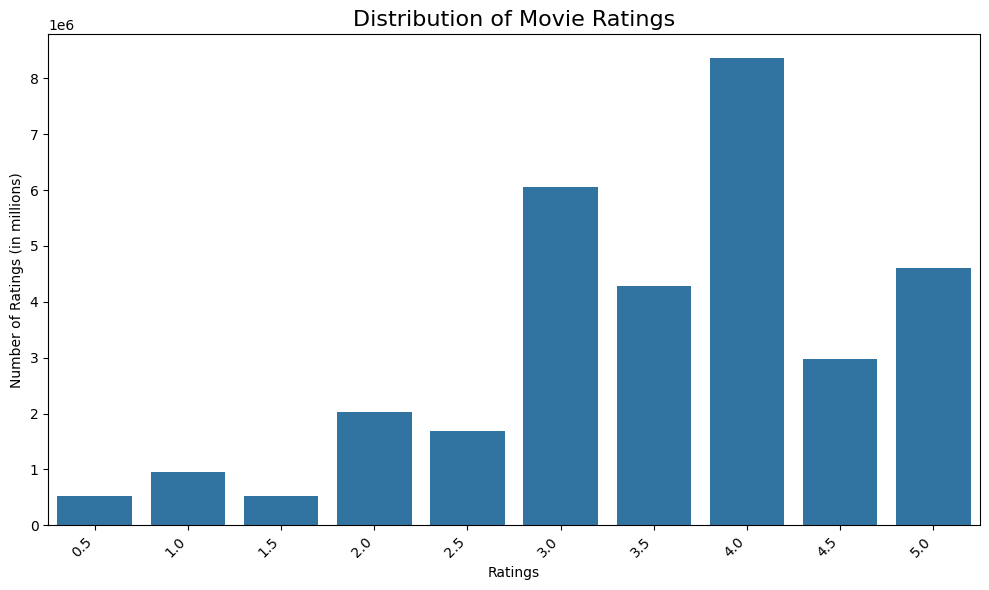

In [ ]:
def plot_rating_distribution(ratings_df):
    """Plots the distribution of rating scores."""
    ratings_dist = (
        ratings_df
        .group_by('rating')
        .agg(pl.len().alias('count'))
        .sort('rating')
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(x='rating', y='count',
                data=ratings_dist.to_pandas())
    plt.title('Distribution of Movie Ratings', fontsize=16)
    plt.xlabel('Ratings')
    plt.ylabel('Number of Ratings (in millions)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/rating_distribution.pdf")
    plt.show()

plot_rating_distribution(ratings_df)

In [ ]:
def analyze_movie_trends(movies_df: pl.DataFrame, ratings_df: pl.DataFrame) -> None:

    movies_df = movies_df.with_columns(
        pl.col('title').str.extract(r'\((\d{4})\)').cast(pl.Int64).alias('year')
    )

    merged_df = movies_df.join(ratings_df, on='movieId')

    average_rating_per_year = (
        merged_df.group_by('year')
        .agg(pl.mean('rating').alias('average_rating'))
        .sort('year')
    )

    movies_per_year = (
        movies_df.group_by('year')
        .agg(pl.count('movieId').alias('movie_count'))
        .sort('year')
    )

    # Convert to pandas for plotting
    avg_rating_pd = average_rating_per_year.to_pandas()
    movies_count_pd = movies_per_year.to_pandas()

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=avg_rating_pd, x='year', y='average_rating')
    plt.title('Average Movie Rating Over Time')
    plt.xlabel('Year')
    plt.ylabel('Average Rating')
    plt.tight_layout()
    plt.ylim(0, 5)
    plt.xlim(1874, 2025)
    plt.savefig(f"{save_dir}/average_rating_over_time.pdf")
    plt.show()

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=movies_count_pd, x='year', y='movie_count', color='orange')
    plt.title('Number of Movies Released Per Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Movies')
    plt.tight_layout()
    plt.xlim(1874, 2025)
    plt.savefig(f"{save_dir}/movies_per_year.pdf")
    plt.show()


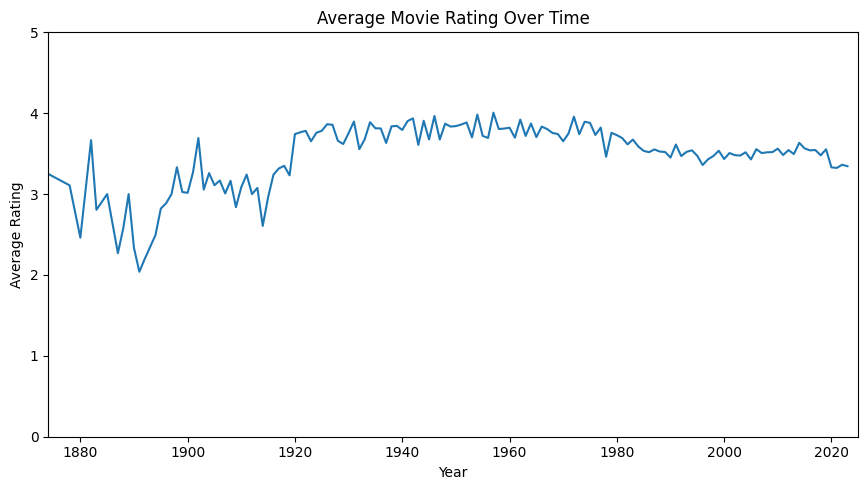

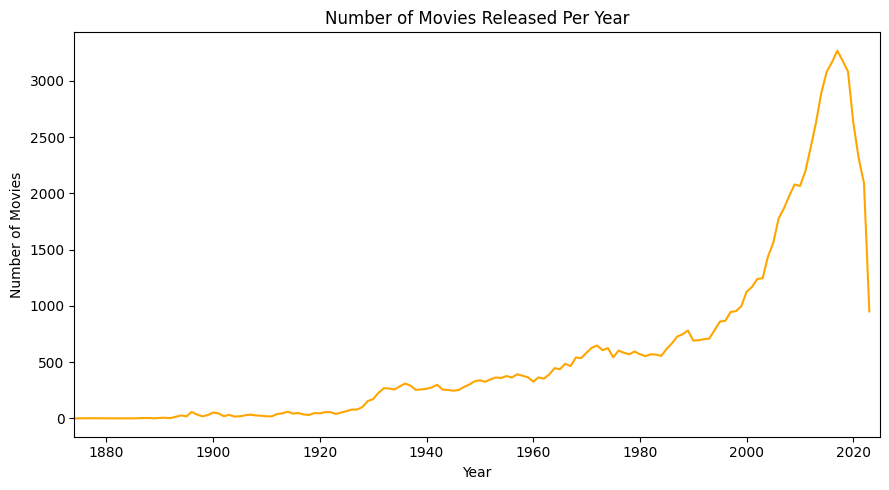

In [ ]:
analyze_movie_trends(movies_df, ratings_df)

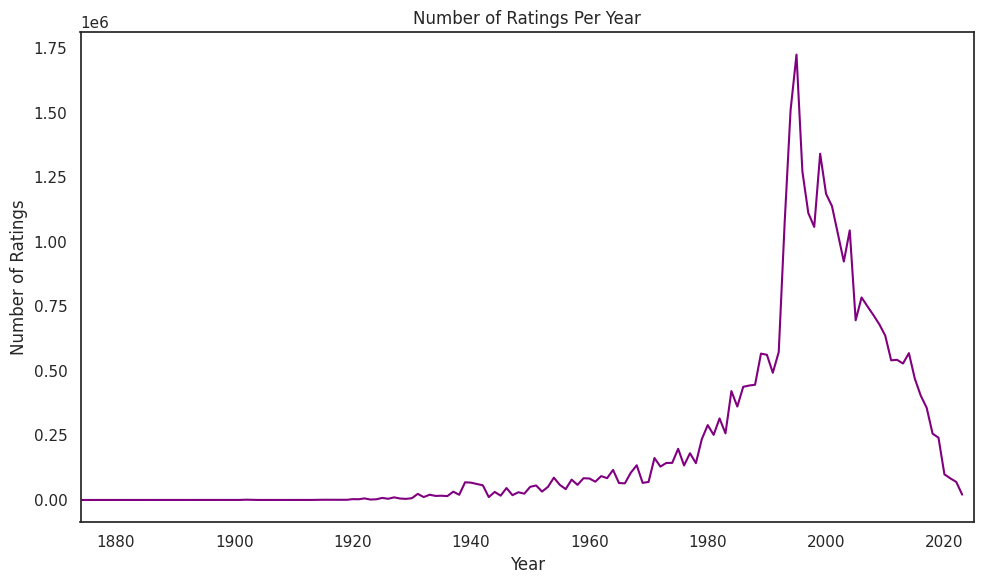

In [ ]:
def plot_ratings_per_year(movies_df: pl.DataFrame, ratings_df: pl.DataFrame) -> None:
    movies_with_year = movies_df.with_columns(
        pl.col('title').str.extract(r'\((\d{4})\)').cast(pl.Int64).alias('year')
    )

    merged_df = movies_with_year.join(ratings_df, on='movieId', how='inner')

    ratings_count_per_year = (
        merged_df.group_by('year')
        .agg(pl.len().alias('rating_count'))
        .sort('year')
        .filter(pl.col('year').is_not_null())
    )

    ratings_count_pd = ratings_count_per_year.to_pandas()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=ratings_count_pd, x='year', y='rating_count', color='purple')
    plt.title('Number of Ratings Per Year', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Ratings', fontsize=12)
    plt.tight_layout()
    plt.xlim(1874, 2025)
    plt.savefig(f"{save_dir}/ratings_per_year.pdf")
    plt.show()

plot_ratings_per_year(movies_df, ratings_df)

In [ ]:
def plot_degree_distribution(df):
    """
    Calculates and plots the degree distributions for both movies and users
    on a single log-log scale plot with different colors and a legend.

    Args:
        df (pd.DataFrame): The dataframe containing the ratings data.
    """
    # Convert Polars DataFrame to Pandas DataFrame if necessary
    if isinstance(df, pl.DataFrame):
        df = df.to_pandas()

    movie_degrees = df['movieId'].value_counts()
    movie_degree_counts = movie_degrees.value_counts().sort_index()
    k_movies = movie_degree_counts.index
    freq_movies = movie_degree_counts.values

    user_degrees = df['userId'].value_counts()
    user_degree_counts = user_degrees.value_counts().sort_index()
    k_users = user_degree_counts.index
    freq_users = user_degree_counts.values

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.scatter(k_movies, freq_movies, marker='.',
               alpha=0.8, color='blue',label='Movie')
    ax.scatter(k_users, freq_users, marker='.',
               alpha=0.8, color='green', label='User')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title('Movie Popularity vs. User Activity', fontsize=18)
    ax.set_xlabel('Degree', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    ax.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/degree_distribution.pdf")
    plt.show()

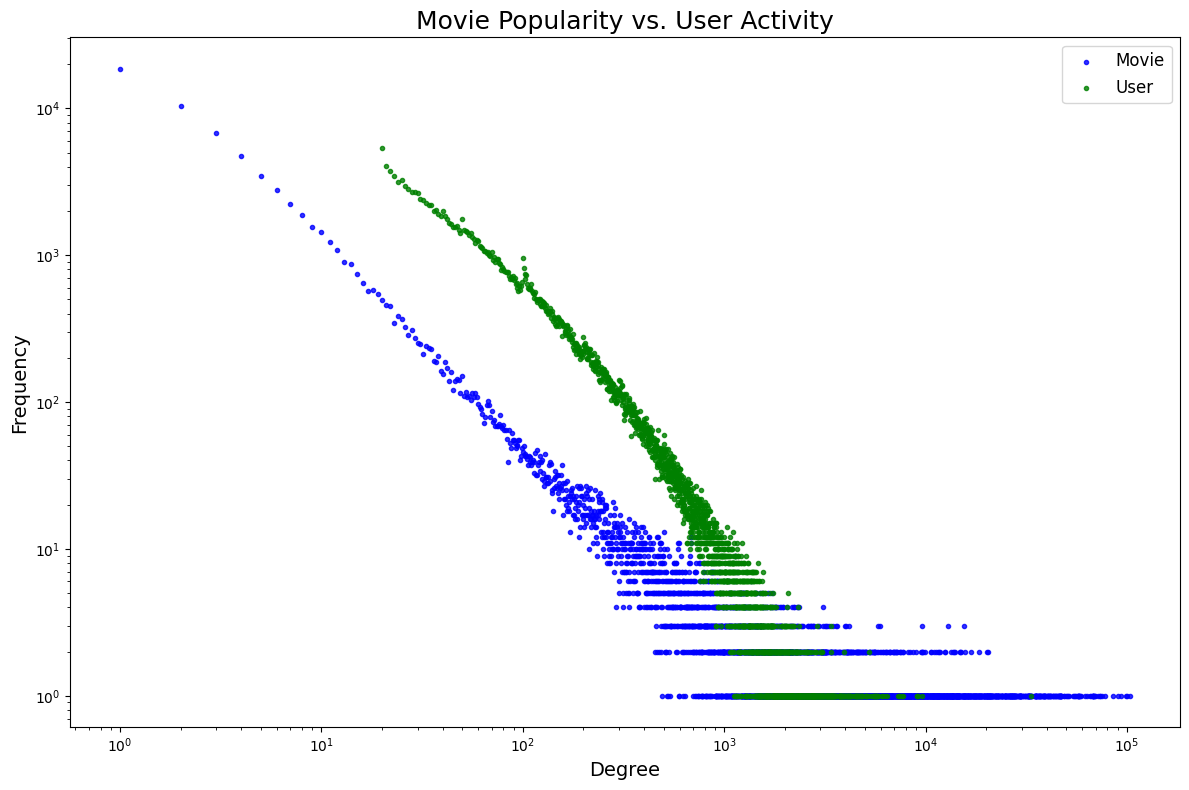

In [ ]:
plot_degree_distribution(df=ratings_df)

In [ ]:
def plot_top_genres(movies_lazy):
    """Finds and plots the most common movie genres."""

    genre_counts = (
        movies_lazy
        .filter(pl.col('genres') != '(no genres listed)')
        .select(pl.col('genres').str.split('|'))
        .explode('genres')
        .group_by('genres')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
    )

    plt.figure(figsize=(8, 5))
    sns.barplot(x='count', y='genres',
                data=genre_counts.limit(15).collect().to_pandas())
    plt.title('Top Movie Genres', fontsize=16)
    plt.xlabel('Number of Movies')
    plt.ylabel('Genre')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/top_genres.pdf")
    plt.show()

    return genre_counts

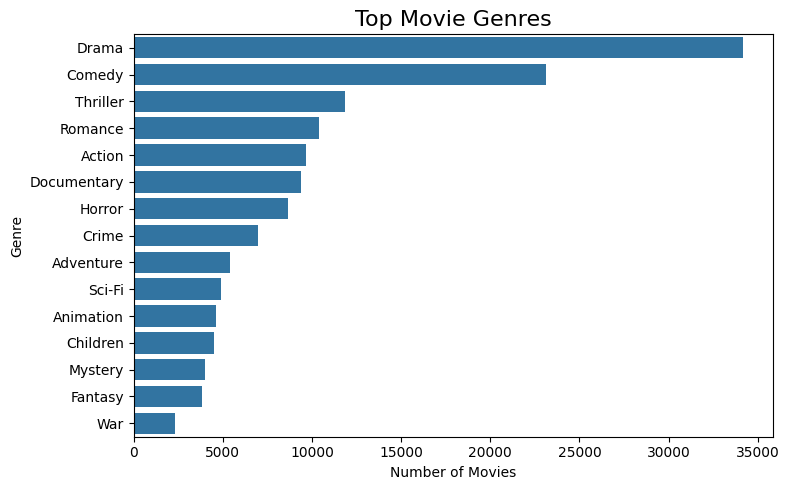

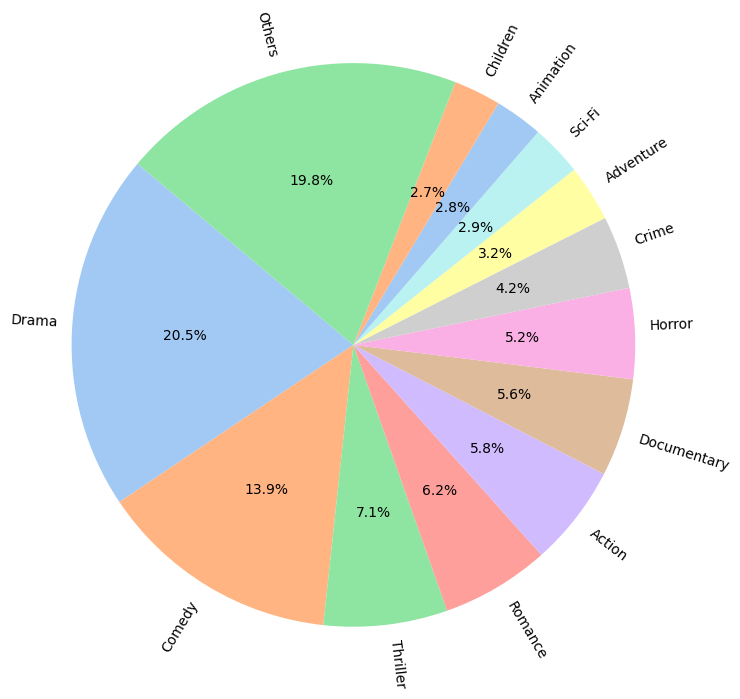

In [ ]:
genre_counts = plot_top_genres(movies_df.lazy())
top_8_genres = genre_counts.head(8).select(pl.sum('count')).collect().item()
total_genres_count = genre_counts.select(pl.sum('count')).collect().item()
others_count = total_genres_count - top_8_genres

pie_data = genre_counts.head(12).collect().to_pandas()

others_row = pd.DataFrame({'genres': ['Others'], 'count': [others_count]})
pie_data = pd.concat([pie_data, others_row], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(pie_data['count'], labels=pie_data['genres'], rotatelabels=True,
        normalize=True, autopct='%1.1f%%', labeldistance=1.05,
        startangle=140, colors=sns.color_palette('pastel', len(pie_data)))
plt.axis('equal')
plt.savefig(f"{save_dir}/genre_distribution.pdf")
plt.show()

In [ ]:
ratings_df_lazy = pl.scan_csv(os.path.join(data_dir, 'ratings.csv'))
movies_df_lazy = pl.scan_csv(os.path.join(data_dir, 'movies.csv'))
tags_df_lazy = pl.scan_csv(os.path.join(data_dir, 'tags.csv'))

/tmp/ipython-input-2443724577.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_pd = genre_ratings_pd.groupby('genres', group_keys=False).apply(
/tmp/ipython-input-2443724577.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='genres', y='rating', data=sampled_pd,


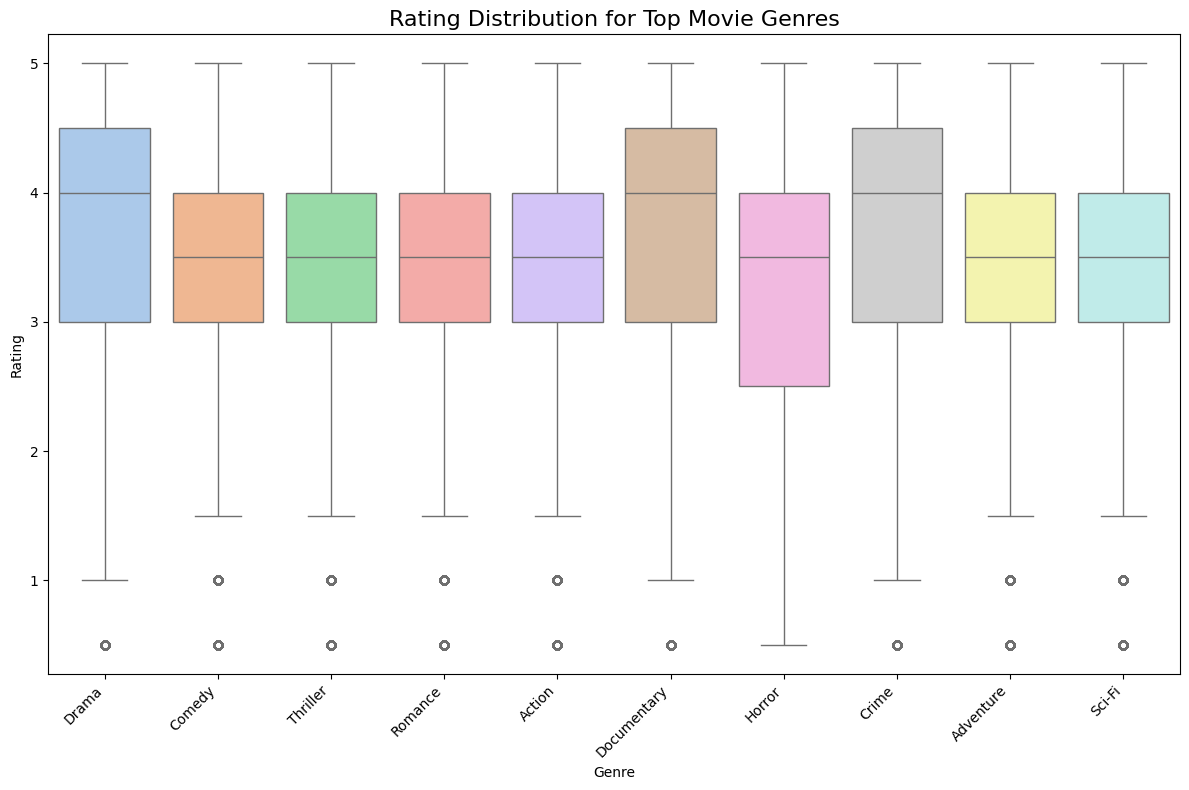

In [ ]:
def plot_genre_rating_distributions(movies_pl, ratings_pl):
    """
    Plots the distribution of ratings for the top 12 movie genres.
    Args:
        movies_pl (pl.LazyFrame): LazyFrame containing movie information.
        ratings_pl (pl.LazyFrame): LazyFrame containing rating information.
    """
    # Get top 12 genres
    genre_counts = (
        movies_pl
        .filter(pl.col('genres') != '(no genres listed)')
        .select(pl.col('genres').str.split(by='|'))
        .explode('genres')
        .group_by('genres')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
        .head(10)
        .collect()
    )
    top_genres = genre_counts.select('genres').to_series().to_list()

    genre_ratings = (
        movies_pl
        .join(ratings_pl, on='movieId')
        .filter(pl.col('genres') != '(no genres listed)')
        .select(['genres', pl.col('rating').cast(pl.Float64).alias('rating')])
        .with_columns(pl.col('genres').str.split(by='|'))
        .explode('genres')
        .filter(pl.col('genres').is_in(top_genres))
        .collect()
    )

    genre_ratings_pd = genre_ratings.to_pandas()

    sampled_pd = genre_ratings_pd.groupby('genres', group_keys=False).apply(
        lambda x: x.sample(min(len(x), 10000), random_state=42)
    ).reset_index(drop=True)

    plt.figure(figsize=(12, 8))
    sns.boxplot(x='genres', y='rating', data=sampled_pd,
                   palette='pastel', order=top_genres)
    plt.title('Rating Distribution for Top Movie Genres', fontsize=16)
    plt.xlabel('Genre')
    plt.ylabel('Rating')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{save_dir}/genre_rating_distribution.pdf")
    plt.show()


plot_genre_rating_distributions(movies_df_lazy, ratings_df_lazy)

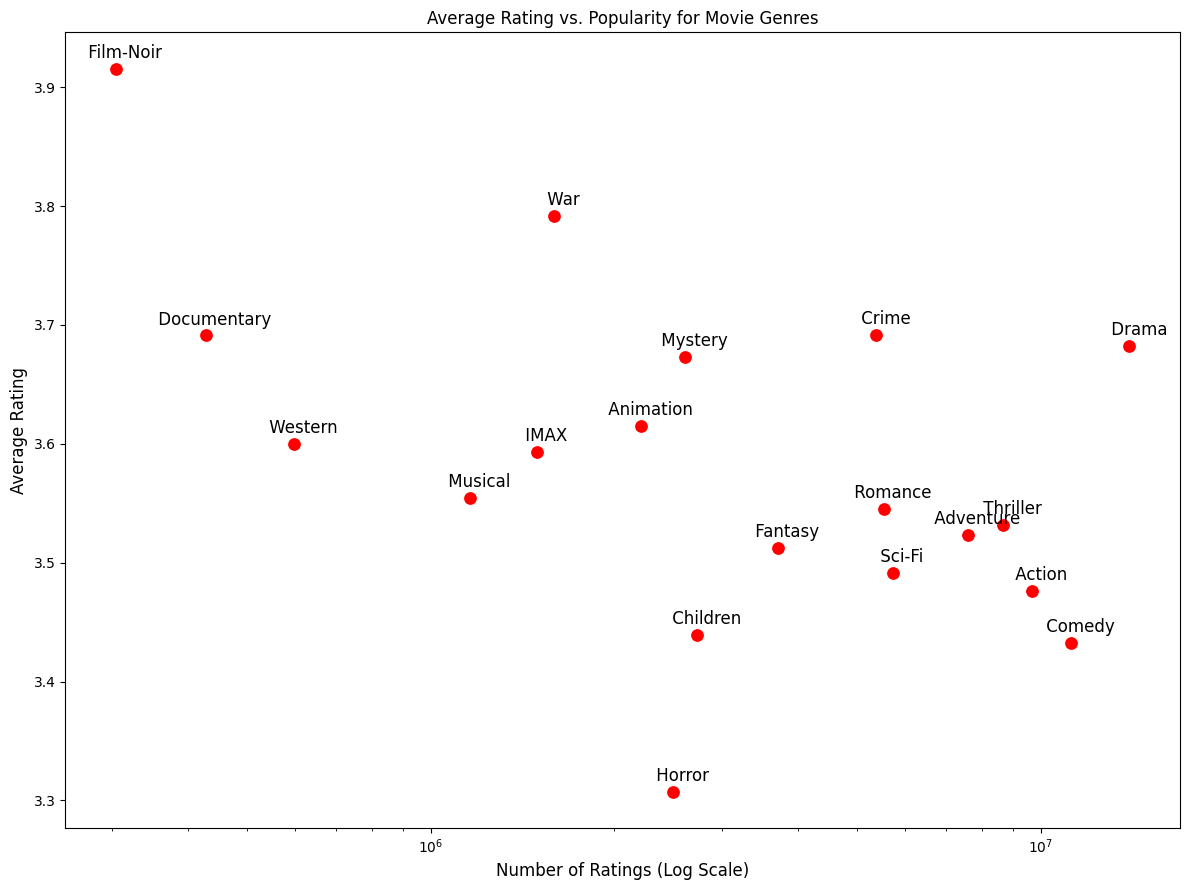

In [ ]:
def plot_genre_ratings(movies_df, ratings_df):
    """Analyzes the average rating and popularity of each genre."""

    genre_ratings = (
        movies_df
        .join(ratings_df, on='movieId')
        .filter(pl.col('genres') != '(no genres listed)')
        .select(['genres', 'rating'])
        .with_columns(pl.col('genres').str.split('|'))
        .explode('genres')
        .group_by('genres')
        .agg(
            pl.mean('rating').alias('average_rating'),
            pl.count('rating').alias('number_of_ratings')
        )
        .sort('average_rating', descending=True)
    )

    genre_ratings_filtered = genre_ratings.filter(pl.col('number_of_ratings') > 50000)

    fig, ax = plt.subplots(figsize=(12, 9))
    sns.scatterplot(
        data=genre_ratings_filtered.to_pandas(),
        x="number_of_ratings",
        y="average_rating",
        legend=False,
        color="red",
        s=100,
        ax=ax
    )

    texts = []
    for i, row in genre_ratings_filtered.to_pandas().iterrows():
        texts.append(ax.annotate(
            f" {row['genres']}",
            (row['number_of_ratings'], row['average_rating']), fontsize=12,
            xytext=(5, 5), textcoords='offset points', va='bottom', ha='center'
        ))

    ax.set_xscale('log')
    plt.title('Average Rating vs. Popularity for Movie Genres', fontsize=12)
    plt.xlabel('Number of Ratings (Log Scale)', fontsize=12)
    plt.ylabel('Average Rating', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{save_dir}/genre_rating_popularity.pdf")
    plt.show()

plot_genre_ratings(movies_df, ratings_df)

In [ ]:
def plot_top_tags(tags_lazy):
    """Finds and plots the most common user-generated tags."""
    tag_counts = (
        tags_lazy
        .select(pl.col('tag').str.to_lowercase().alias('tag'))
        .group_by('tag')
        .agg(pl.len().alias('count'))
        .sort('count', descending=True)
        .limit(60)
    )

    return tag_counts

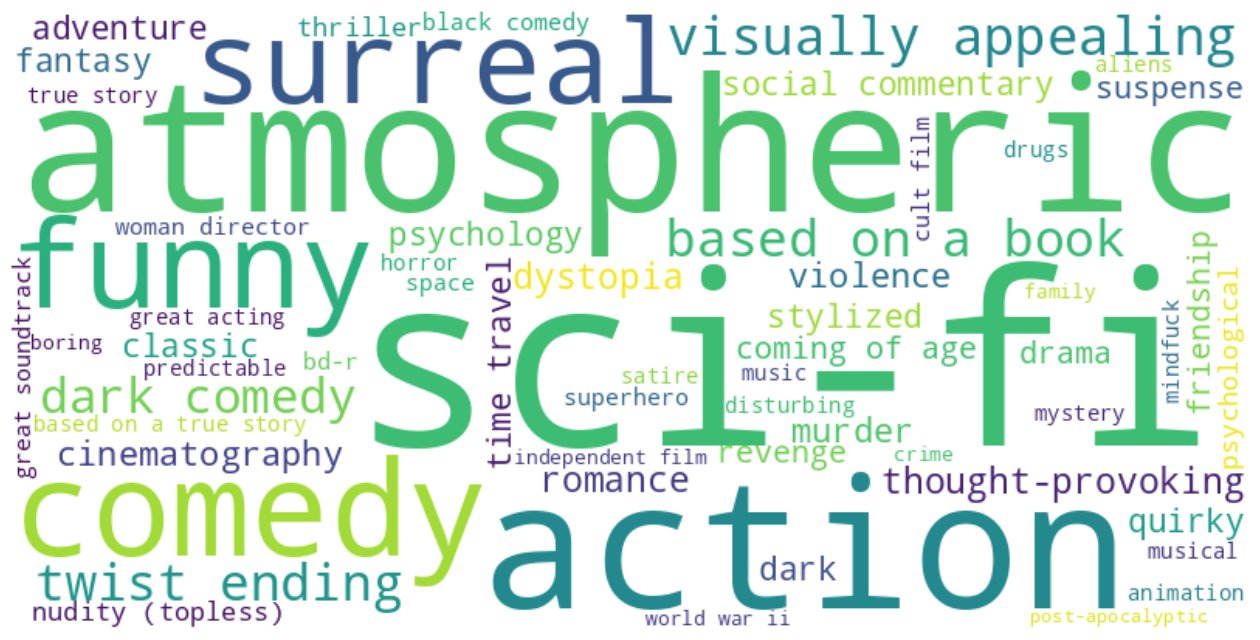

In [ ]:
from wordcloud import WordCloud

tag_counts = plot_top_tags(tags_df.lazy())
tag_frequencies = tag_counts.collect().to_pandas().set_index('tag')['count'].to_dict()

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tag_frequencies)

plt.figure(figsize=(16, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.savefig(f"{save_dir}/tag_wordcloud.pdf")
plt.show()

# Modelling


In [ ]:
def plot_training_history(model):
    sns.set_style("white")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    epochs = range(1, len(model.train_loss_history) + 1)

    ax1.plot(epochs, model.train_loss_history, 'b', label='Training Loss')
    ax1.set_title('Negative Log-Likelihood loss', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.set_xticks(epochs)

    ax2.plot(epochs, model.train_rmse_history, 'g', label='Train')
    ax2.plot(epochs, model.test_rmse_history, 'r', label='Test')
    ax2.set_title('Train vs. Test RMSE', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('RMSE')
    ax2.legend()
    ax2.set_xticks(epochs)

    plt.tight_layout()

    model_name = model.__class__.__name__
    lambda_str = f"lambda={model.lambda_reg}"
    tau_str = f"tau={model.tau}"
    mu_str = f"mu={model.mu:.4f}"

    k_str = ""
    if hasattr(model, 'k'):
        k_str = f"k={model.k}_"

    filename = f"training_history_{model_name}_{k_str}{lambda_str}_{tau_str}_{mu_str}.pdf"
    filepath = os.path.join(save_dir, filename)
    plt.savefig(filepath)
    plt.show()

## Bias-only Model

The bias model only aims at reducing the regularized log likelihood:

$$ L = \lambda \sum (r_{ui} - (\mu + b_u + b_i))^2 + \tau \left(\sum b_u^2 + \sum b_i^2\right) $$

The user and item biases are updated using:

$$ b_u = \frac{\lambda \sum_{i \in R(u)} (r_{ui} - \mu - b_i - \mathbf{u}_u^T \mathbf{v}_i)}{\tau + \lambda |R(u)|} $$

$$ b_i = \frac{\lambda \sum_{u \in R(i)} (r_{ui} - \mu - b_u - \mathbf{u}_u^T \mathbf{v}_i)}{\tau + \lambda|R(i)|} $$

where $\mu$, $|R(u)|$, $|R(i)|$, is the average rating, number of items rated by user $u$, and the number of users who rated item $i$ respectively.



In [ ]:
class ALSBiases:
    def __init__(self, train_user, test_user, train_movie,
                 test_movie, n_users, n_movies, lambda_reg=25, tau=5.0):

        self.train_user = train_user
        self.test_user = test_user
        self.train_movie = train_movie
        self.test_movie = test_movie
        self.n_users = n_users
        self.n_movies = n_movies
        self.tau = tau

        self.lambda_reg = lambda_reg
        self.user_biases = np.zeros(self.n_users)
        self.item_biases = np.zeros(self.n_movies)

        self.train_rmse_history = []
        self.test_rmse_history = []
        self.train_loss_history = []

        total_rating = sum(r for u_ratings in self.train_user for _, r in u_ratings)
        num_ratings = sum(len(u_ratings) for u_ratings in self.train_user)
        self.mu = total_rating / num_ratings if num_ratings > 0 else 0

    def predict(self, user_idx, item_idx):
        return self.mu + self.user_biases[user_idx] + self.item_biases[item_idx]

    def _calculate_rmse(self, data_by_user):
        sse = 0
        count = 0
        for user_idx, ratings in enumerate(data_by_user):
            for item_idx, true_rating in ratings:
                prediction = self.predict(user_idx, item_idx)
                sse += (true_rating - prediction) ** 2
                count += 1
        return np.sqrt(sse / count)

    def _calculate_loss(self):
        sse = 0
        for user_idx, ratings in enumerate(self.train_user):
            for item_idx, true_rating in ratings:
                prediction = self.predict(user_idx, item_idx)
                sse += (true_rating - prediction) ** 2

        reg_term = self.tau * (np.sum(self.user_biases**2) + np.sum(self.item_biases**2))
        return self.lambda_reg * sse + reg_term

    def train(self, n_epochs=10):
        print(f"\nStarting training for {n_epochs} epochs...")
        print(f"Hyperparameters: lambda={self.lambda_reg}, tau={self.tau}")

        for epoch in range(n_epochs):
            for m in range(self.n_users):
                residuals_sum = sum(r - self.mu - self.item_biases[i] for i, r in self.train_user[m])
                count = len(self.train_user[m])
                self.user_biases[m] = (self.lambda_reg * residuals_sum) / (self.tau + self.lambda_reg * count)

            for n in range(self.n_movies):
                residuals_sum = sum(r - self.mu - self.user_biases[u] for u, r in self.train_movie[n])
                count = len(self.train_movie[n])
                self.item_biases[n] = (self.lambda_reg * residuals_sum) / (self.tau + self.lambda_reg * count)

            train_loss = self._calculate_loss()
            train_rmse = self._calculate_rmse(self.train_user)
            test_rmse = self._calculate_rmse(self.test_user)

            self.train_loss_history.append(train_loss)
            self.train_rmse_history.append(train_rmse)
            self.test_rmse_history.append(test_rmse)

            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"Loss: {train_loss:.2f} | "
                  f"Train RMSE: {train_rmse:.4f} | "
                  f"Test RMSE: {test_rmse:.4f}")

In [ ]:
als_model = ALSBiases(
    train_user, test_user, train_movie, test_movie,
    n_users=movie_index.n_users,
    n_movies=movie_index.n_movies,
    lambda_reg=0.1,
    tau=0.1
)

als_model.train(n_epochs=20)


Starting training for 20 epochs...
Hyperparameters: lambda=0.1, tau=0.1
Epoch 1/20 | Loss: 5445.68 | Train RMSE: 0.8058 | Test RMSE: 0.8790
Epoch 2/20 | Loss: 5280.36 | Train RMSE: 0.7911 | Test RMSE: 0.8665
Epoch 3/20 | Loss: 5269.78 | Train RMSE: 0.7899 | Test RMSE: 0.8656
Epoch 4/20 | Loss: 5267.28 | Train RMSE: 0.7897 | Test RMSE: 0.8653
Epoch 5/20 | Loss: 5265.61 | Train RMSE: 0.7896 | Test RMSE: 0.8652
Epoch 6/20 | Loss: 5264.25 | Train RMSE: 0.7896 | Test RMSE: 0.8651
Epoch 7/20 | Loss: 5263.11 | Train RMSE: 0.7895 | Test RMSE: 0.8650
Epoch 8/20 | Loss: 5262.16 | Train RMSE: 0.7895 | Test RMSE: 0.8650
Epoch 9/20 | Loss: 5261.36 | Train RMSE: 0.7895 | Test RMSE: 0.8649
Epoch 10/20 | Loss: 5260.68 | Train RMSE: 0.7895 | Test RMSE: 0.8648
Epoch 11/20 | Loss: 5260.12 | Train RMSE: 0.7895 | Test RMSE: 0.8648
Epoch 12/20 | Loss: 5259.64 | Train RMSE: 0.7894 | Test RMSE: 0.8648
Epoch 13/20 | Loss: 5259.24 | Train RMSE: 0.7894 | Test RMSE: 0.8647
Epoch 14/20 | Loss: 5258.90 | Train RMS

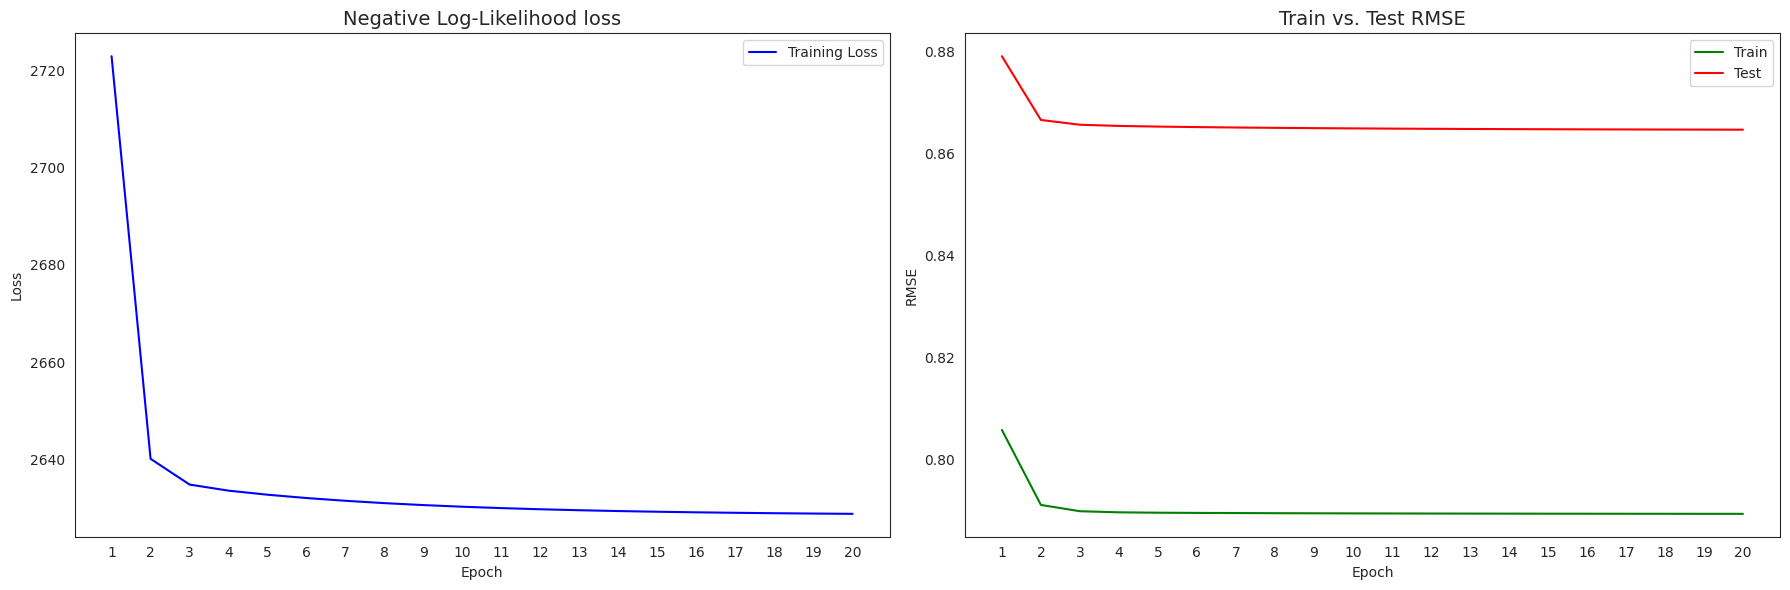

In [ ]:
plot_training_history(als_model)

## Full Matrix Factorization Model

The model aims at minimizing the complete regularized log likelihood:

$$ L = \lambda \sum_{u,i} (r_{ui} - (\mu + b_u + b_i + \mathbf{u}_u^T \mathbf{v}_i))^2 + \tau \left(\sum_u b_u^2 + \sum_i b_i^2 + \sum_u ||\mathbf{u}_u||^2 + \sum_i ||\mathbf{v}_i||^2\right) $$

where:
- $ b_u $ and $ b_i $ are the user and item biases.
- $ \mathbf{u}_u $ is the latent factor vector for user $u$ (size k x 1).
- $ \mathbf{v}_i $ is the latent factor vector for item $i$ (size k x 1).
- $ ||\mathbf{u}_u||^2 $ is the squared L2 norm of the vector ($ \mathbf{u}_u^T \mathbf{u}_u $).
- $ \lambda $ and $ \tau $ are the regularization hyperparameter.

To update the user latent factor vector $ \mathbf{u}_u $, we solve the following linear system:

$$ \mathbf{u}_u = \left( \lambda \sum_{i \in R(u)} \mathbf{v}_i \mathbf{v}_i^T + \tau \mathbf{I} \right)^{-1} \left( \lambda \sum_{i \in R(u)} \mathbf{v}_i (r_{ui} - \mu - b_u - b_i) \right) $$

Symmetrically, to update the item latent factor vector $ \mathbf{v}_i $, we solve:

$$ \mathbf{v}_i = \left( \lambda \sum_{u \in R(i)} \mathbf{u}_u \mathbf{u}_u^T + \tau \mathbf{I} \right)^{-1} \left( \lambda \sum_{u \in R(i)} \mathbf{u}_u (r_{ui} - \mu- b_u - b_i) \right) $$

where $ \mathbf{I} $ is the k x k identity matrix.

In [ ]:
class ALSLatent:
    def __init__(self, train_user, test_user, train_movie,
                 test_movie, n_users, n_movies, k=10, lambda_reg=2.5, tau=0.05):

        self.train_user = train_user
        self.test_user = test_user
        self.train_movie = train_movie
        self.test_movie = test_movie
        self.n_users = n_users
        self.n_movies = n_movies
        self.k = k
        self.tau = tau

        self.lambda_reg = lambda_reg
        self.user_biases = np.zeros(self.n_users)
        self.item_biases = np.zeros(self.n_movies)
        self.user_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_users, self.k))
        self.item_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_movies, self.k))

        self.train_rmse_history = []
        self.test_rmse_history = []
        self.train_loss_history = []

        total_rating = sum(r for u_ratings in self.train_user for _, r in u_ratings)
        num_ratings = sum(len(u_ratings) for u_ratings in self.train_user)
        self.mu = total_rating / num_ratings if num_ratings > 0 else 0

    def predict(self, user_idx, item_idx):
        return self.mu + self.user_biases[user_idx] + self.item_biases[item_idx] + \
        np.dot(self.user_vector[user_idx], self.item_vector[item_idx])

    def _calculate_rmse(self, data_by_user):
        sse = 0
        count = 0
        for user_idx, ratings in enumerate(data_by_user):
            for item_idx, true_rating in ratings:
                prediction = self.predict(user_idx, item_idx)
                sse += (true_rating - prediction) ** 2
                count += 1
        return np.sqrt(sse / count)

    def _calculate_loss(self):
        sse = 0
        for user_idx, ratings in enumerate(self.train_user):
            for item_idx, true_rating in ratings:
                prediction = self.predict(user_idx, item_idx)
                sse += (true_rating - prediction) ** 2

        reg_term = self.tau * (np.sum(self.user_biases**2) +
                                      np.sum(self.item_biases**2) +
                                      np.sum(self.user_vector**2) +
                                      np.sum(self.item_vector**2)
                                      )
        return self.lambda_reg * sse + reg_term

    def train(self, n_epochs=10):
        print(f"\nStarting training for {n_epochs} epochs...")
        print(f"Hyperparameters: lambda={self.lambda_reg}, mu={self.mu:.4f}, tau={self.tau:.4f}")

        for epoch in range(n_epochs):
            for m in range(self.n_users):
                # Update user bias
                residuals_sum = sum(r - self.mu - self.item_biases[i] -
                                    np.dot(self.user_vector[m], self.item_vector[i])
                                    for i, r in self.train_user[m])
                count = len(self.train_user[m])
                self.user_biases[m] = residuals_sum / (self.lambda_reg + count)

                # Update user latent
                A = np.zeros((self.k, self.k))
                Y = np.zeros(self.k)
                I = np.identity(self.k)

                # Loop over items rated by user
                for i, r in self.train_user[m]:
                    item_vec_i = self.item_vector[i]

                    A += self.lambda_reg * np.outer(item_vec_i, item_vec_i)
                    residual_for_vector = r - self.mu - self.user_biases[m] - self.item_biases[i]
                    Y += self.lambda_reg * item_vec_i * residual_for_vector

                A += self.tau * I
                self.user_vector[m] = np.linalg.solve(A, Y)

            for n in range(self.n_movies):
                # Update item bias
                residuals_sum = sum(r - self.mu - self.user_biases[u] -
                                    np.dot(self.user_vector[u], self.item_vector[n])
                                    for u, r in self.train_movie[n])
                count = len(self.train_movie[n])
                self.item_biases[n] = residuals_sum / (self.lambda_reg + count)

                # Update item latent
                A = np.zeros((self.k, self.k))
                Y = np.zeros(self.k)
                I = np.identity(self.k)

                # Loop over users that rated the movie
                for u, r in self.train_movie[n]:
                    user_vec_u = self.user_vector[u]

                    A += self.lambda_reg * np.outer(user_vec_u, user_vec_u)
                    residual_for_vector = r - self.mu - self.user_biases[u] - self.item_biases[n]
                    Y += self.lambda_reg * user_vec_u * residual_for_vector

                A += self.tau * I
                self.item_vector[n] = np.linalg.solve(A, Y)

            train_loss = self._calculate_loss()
            train_rmse = self._calculate_rmse(self.train_user)
            test_rmse = self._calculate_rmse(self.test_user)

            self.train_loss_history.append(train_loss)
            self.train_rmse_history.append(train_rmse)
            self.test_rmse_history.append(test_rmse)

            print(f"Epoch {epoch+1}/{n_epochs} | "
                  f"Loss: {train_loss:.2f} | "
                  f"Train RMSE: {train_rmse:.4f} | "
                  f"Test RMSE: {test_rmse:.4f}")

In [ ]:
als_latent_model = ALSLatent(
    train_user, test_user, train_movie, test_movie,
    n_users=movie_index.n_users,
    n_movies=movie_index.n_movies,
    lambda_reg=1.5
)

als_latent_model.train(n_epochs=20)


Starting training for 20 epochs...
Hyperparameters: lambda=1.5, mu=3.5022
Epoch 1/20 | Loss: 47400.95 | Train RMSE: 0.7059 | Test RMSE: 0.9038
Epoch 2/20 | Loss: 36091.66 | Train RMSE: 0.5799 | Test RMSE: 0.9280
Epoch 3/20 | Loss: 32054.62 | Train RMSE: 0.5362 | Test RMSE: 0.9432
Epoch 4/20 | Loss: 30057.28 | Train RMSE: 0.5146 | Test RMSE: 0.9543
Epoch 5/20 | Loss: 28891.89 | Train RMSE: 0.5017 | Test RMSE: 0.9623
Epoch 6/20 | Loss: 28156.22 | Train RMSE: 0.4935 | Test RMSE: 0.9683
Epoch 7/20 | Loss: 27666.96 | Train RMSE: 0.4880 | Test RMSE: 0.9731
Epoch 8/20 | Loss: 27325.59 | Train RMSE: 0.4840 | Test RMSE: 0.9768
Epoch 9/20 | Loss: 27077.47 | Train RMSE: 0.4812 | Test RMSE: 0.9797
Epoch 10/20 | Loss: 26891.01 | Train RMSE: 0.4790 | Test RMSE: 0.9819
Epoch 11/20 | Loss: 26746.64 | Train RMSE: 0.4773 | Test RMSE: 0.9835
Epoch 12/20 | Loss: 26631.68 | Train RMSE: 0.4759 | Test RMSE: 0.9847
Epoch 13/20 | Loss: 26537.86 | Train RMSE: 0.4748 | Test RMSE: 0.9854
Epoch 14/20 | Loss: 2645

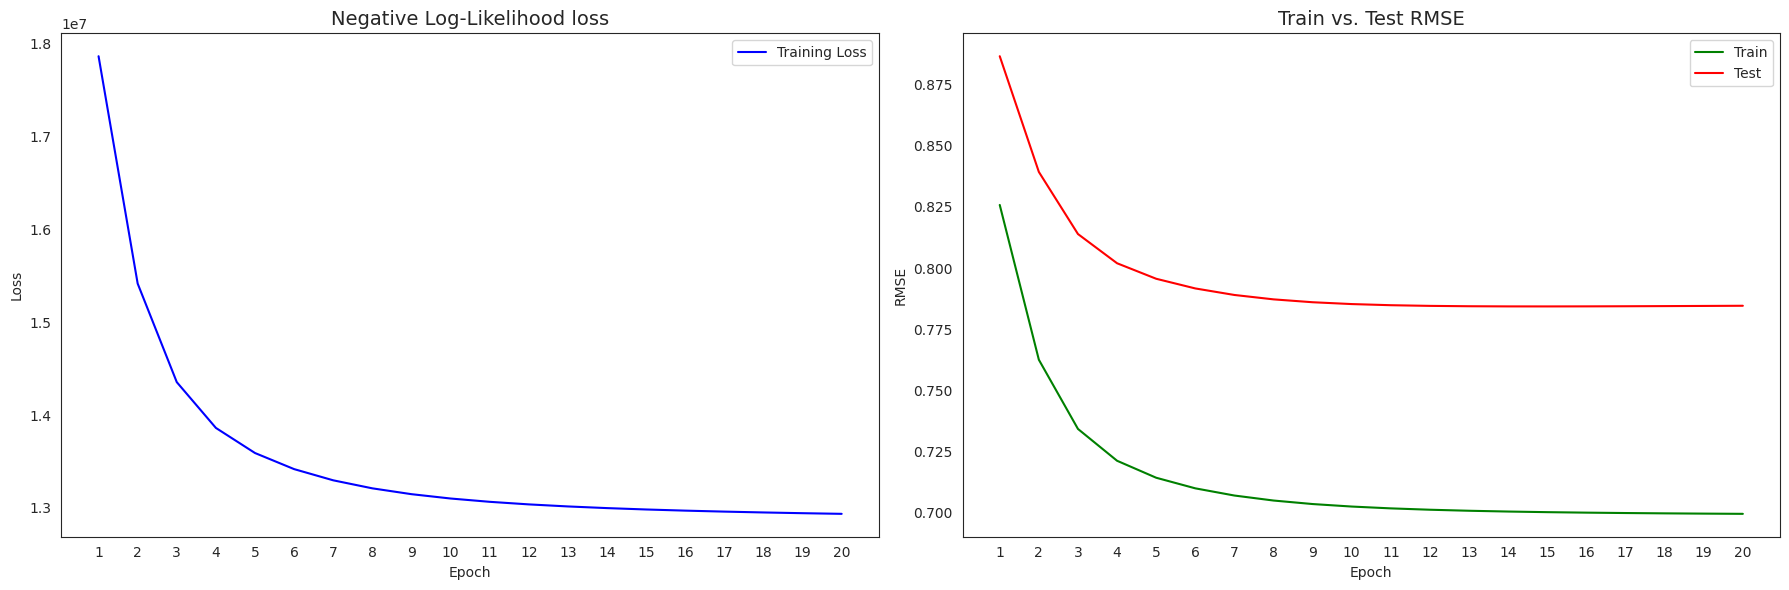

In [ ]:
plot_training_history(als_latent_model)

## Going Big

- Parallerize training
- Make k = 10, 20
- Experiment with lambda_reg
- Test with dummy user use `score_for_item[n] = user_trait_vector[m].inner(item_trait_vector[n]) + item_bias[n]` and also try ranking `score_for_item[n] = user_trait_vector[m].inner(item_trait_vector[n]) + 0.05 * item_bias[n]`. Even after this, filter out movies with less than 100 ratings to get cleaner results

In [ ]:
class ALS:
    def __init__(self, train_user, test_user, train_movie,
                 test_movie, n_users, n_movies, k=10, lambda_reg=2.5,
                 tau=0.1, n_jobs=-1):

        self.train_user = train_user
        self.test_user = test_user
        self.train_movie = train_movie
        self.test_movie = test_movie
        self.n_users = n_users
        self.n_movies = n_movies
        self.k = k
        self.lambda_reg = lambda_reg
        self.tau = tau
        self.n_jobs = n_jobs

        self.user_biases = np.zeros(self.n_users)
        self.item_biases = np.zeros(self.n_movies)
        self.user_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_users, self.k))
        self.item_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_movies, self.k))

        self.train_rmse_history = []
        self.test_rmse_history = []
        self.train_loss_history = []

        if train_user is not None:
            total_rating = sum(r for u_ratings in self.train_user for _, r in u_ratings)
            num_ratings = sum(len(u_ratings) for u_ratings in self.train_user)
            self.mu = total_rating / num_ratings if num_ratings > 0 else 0
        else:
            self.mu = 0

    def predict(self, user_idx, item_idx):
        return (self.mu + self.user_biases[user_idx] + self.item_biases[item_idx] +
                np.dot(self.user_vector[user_idx], self.item_vector[item_idx]))

    def _calculate_rmse(self, data_by_user):
        sse = 0.0
        count = 0
        for user_idx, ratings in enumerate(data_by_user):
            if len(ratings) == 0:
                continue
            items, true_ratings = zip(*ratings)
            items = np.array(items, dtype=np.int32)
            true_ratings = np.array(true_ratings)
            preds = (self.mu + self.user_biases[user_idx] +
                     self.item_biases[items] +
                     np.dot(self.item_vector[items], self.user_vector[user_idx]))
            sse += np.sum((true_ratings - preds) ** 2)
            count += len(ratings)
        return np.sqrt(sse / count) if count > 0 else 0.0

    def _calculate_loss(self):
        sse = 0.0
        for user_idx, ratings in enumerate(self.train_user):
            if len(ratings) == 0:
                continue
            items, true_ratings = zip(*ratings)
            items = np.array(items, dtype=np.int32)
            true_ratings = np.array(true_ratings)
            preds = (self.mu + self.user_biases[user_idx] +
                     self.item_biases[items] +
                     np.dot(self.item_vector[items], self.user_vector[user_idx]))
            sse += np.sum((true_ratings - preds) ** 2)

        reg_term = self.tau * (
            np.sum(self.user_biases ** 2) +
            np.sum(self.item_biases ** 2) +
            np.sum(self.user_vector ** 2) +
            np.sum(self.item_vector ** 2)
        )
        return self.lambda_reg * sse + reg_term

    def _update_user(self, m):
        rated = self.train_user[m]
        if len(rated) == 0:
            return self.user_biases[m], self.user_vector[m]

        items, ratings = zip(*rated)
        items = np.array(items, dtype=np.int32)
        ratings = np.array(ratings)

        item_vecs = self.item_vector[items]
        item_bias = self.item_biases[items]

        residuals = ratings - self.mu - item_bias - np.dot(item_vecs, self.user_vector[m])
        bias_m = (self.lambda_reg * np.sum(residuals)) / (self.tau + self.lambda_reg * len(ratings))

        residuals_for_latent = ratings - self.mu - bias_m - item_bias
        A = self.lambda_reg * (item_vecs.T @ item_vecs) + self.tau * np.eye(self.k)
        Y = self.lambda_reg * (item_vecs.T @ residuals_for_latent)
        user_vec = np.linalg.solve(A, Y)
        return bias_m, user_vec

    def _update_item(self, n):
        rated = self.train_movie[n]
        if len(rated) == 0:
            return self.item_biases[n], self.item_vector[n]

        users, ratings = zip(*rated)
        users = np.array(users, dtype=np.int32)
        ratings = np.array(ratings)

        user_vecs = self.user_vector[users]
        user_bias = self.user_biases[users]

        residuals = ratings - self.mu - user_bias - np.dot(user_vecs, self.item_vector[n])
        bias_n = (self.lambda_reg * np.sum(residuals)) / (self.tau + self.lambda_reg * len(ratings))

        residuals_for_latent = ratings - self.mu - user_bias - bias_n
        A = self.lambda_reg * (user_vecs.T @ user_vecs) + self.tau * np.eye(self.k)
        Y = self.lambda_reg * (user_vecs.T @ residuals_for_latent)
        item_vec = np.linalg.solve(A, Y)
        return bias_n, item_vec


    def train(self, n_epochs=10, save_dir="", prefix="ALS"):
        os.makedirs(save_dir, exist_ok=True)
        print(f"\nStarting training for {n_epochs} epochs...")
        print(f"Hyperparameters: lambda={self.lambda_reg}, mu={self.mu:.4f}, tau = {self.tau:.4f}, k={self.k}")

        start_epoch = len(self.train_loss_history)
        for epoch in range(start_epoch, start_epoch + n_epochs):

            # Parallel update users
            user_results = Parallel(n_jobs=self.n_jobs, prefer="threads")(
                delayed(self._update_user)(m) for m in range(self.n_users)
            )
            # Ensure user_results is not empty before unpacking
            if user_results:
                self.user_biases, self.user_vector = map(np.array, zip(*user_results))
            else:
                self.user_biases = np.zeros(self.n_users)
                self.user_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_users, self.k))

            # Parallel update items
            item_results = Parallel(n_jobs=self.n_jobs, prefer="threads")(
                delayed(self._update_item)(n) for n in range(self.n_movies)
            )
            # Ensure item_results is not empty before unpacking
            if item_results:
                self.item_biases, self.item_vector = map(np.array, zip(*item_results))
            else:
                self.item_biases = np.zeros(self.n_movies)
                self.item_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_movies, self.k))

            # Compute metrics
            train_loss = self._calculate_loss()
            train_rmse = self._calculate_rmse(self.train_user)
            test_rmse = self._calculate_rmse(self.test_user)

            self.train_loss_history.append(train_loss)
            self.train_rmse_history.append(train_rmse)
            self.test_rmse_history.append(test_rmse)

            print(
                f"Epoch {epoch + 1}/{start_epoch + n_epochs} | "
                f"Loss: {train_loss:.2f} | "
                f"Train RMSE: {train_rmse:.4f} | "
                f"Test RMSE: {test_rmse:.4f}"
            )

            # Save model
            timestamp = time.strftime("%Y%m%d-%H%M%S")

            filename = (
                f"{prefix}"
                f"_epoch={epoch+1}"
                f"_k={self.k}"
                f"_lambda={self.lambda_reg}"
                f"_tau={self.tau}"
                f"_{self.mu:.4f}"
                f"_{timestamp}.pkl"
            )

            filepath = os.path.join(save_dir, filename)

            checkpoint = {
                "epoch": epoch + 1,
                "k": self.k,
                "tau": self.tau,
                "lambda_reg": self.lambda_reg,
                "mu": self.mu,
                "user_biases": self.user_biases,
                "item_biases": self.item_biases,
                "user_vector": self.user_vector,
                "item_vector": self.item_vector,
                "train_loss_history": self.train_loss_history.copy(),
                "train_rmse_history": self.train_rmse_history.copy(),
                "test_rmse_history": self.test_rmse_history.copy(),
                "n_users": self.n_users,
                "n_movies": self.n_movies,
            }

            with open(filepath, "wb") as f:
                pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

            print(f"Saved model checkpoint → {filepath}\n")

    @classmethod
    def load_checkpoint(cls, train_user, test_user, train_movie, test_movie, path, n_jobs=1):
        """
        Load a saved ALS model checkpoint and return a fully usable model instance.
        """
        with open(path, "rb") as f:
            ckpt = pickle.load(f)

        model = cls(
            n_users=ckpt["n_users"],
            n_movies=ckpt["n_movies"],
            k=ckpt["k"],
            lambda_reg=ckpt["lambda_reg"],
            tau=ckpt["tau"],
            train_user=train_user,
            test_user=test_user,
            train_movie=train_movie,
            test_movie=test_movie,
            n_jobs=n_jobs
        )

        model.mu = ckpt["mu"]
        model.tau = ckpt["tau"]
        model.user_biases = ckpt["user_biases"]
        model.item_biases = ckpt["item_biases"]
        model.user_vector = ckpt["user_vector"]
        model.item_vector = ckpt["item_vector"]
        model.train_loss_history = ckpt.get("train_loss_history", [])
        model.train_rmse_history = ckpt.get("train_rmse_history", [])
        model.test_rmse_history = ckpt.get("test_rmse_history", [])
        model.loaded_epoch = ckpt.get("epoch", None)

        return model

## Faster Implementation with Numba

In [ ]:
def _convert_ragged_to_csr(ragged_data, n_rows):
    """
    Converts list-of-lists to CSR format (offsets, indices, values).
    """
    lengths = np.array([len(x) for x in ragged_data], dtype=np.int32)

    offsets = np.zeros(n_rows + 1, dtype=np.int32)
    offsets[1:] = np.cumsum(lengths)

    valid_rows = [row for row in ragged_data if len(row) > 0]

    if len(valid_rows) == 0:
        indices = np.zeros(0, dtype=np.int32)
        values = np.zeros(0, dtype=np.float32)
    else:
        flat_data = np.concatenate(valid_rows, axis=0)

        indices = flat_data[:, 0].astype(np.int32)
        values = flat_data[:, 1].astype(np.float32)

    return offsets, indices, values


@njit(parallel=True)
def _update_stage(offsets, indices, ratings,
                  fixed_vecs, fixed_biases,
                  target_vecs, target_biases,
                  n_targets, k, lambda_reg, tau, mu):
    """
    Updates Users or Items.
    """
    # Loop over every User or Item
    for i in prange(n_targets):
        start = offsets[i]
        end = offsets[i+1]
        n_ratings = end - start

        if n_ratings == 0:
            continue

        # Slice data for this user/item
        idx_block = indices[start:end]
        rating_block = ratings[start:end]

        # Update Bias
        current_vec = target_vecs[i]
        sum_residuals = 0.0

        for j in range(n_ratings):
            other_idx = idx_block[j]
            r_ui = rating_block[j]

            # dot product
            dot_val = 0.0
            for d in range(k):
                dot_val += fixed_vecs[other_idx, d] * current_vec[d]

            pred = mu + fixed_biases[other_idx] + dot_val
            sum_residuals += (r_ui - pred)

        new_bias = (lambda_reg * sum_residuals) / (tau + lambda_reg * n_ratings)
        target_biases[i] = new_bias

        # Update Vector
        A = np.zeros((k, k), dtype=np.float32)
        Y = np.zeros(k, dtype=np.float32)

        # Add regularization to diagonal of A
        for d in range(k):
            A[d, d] = tau

        for j in range(n_ratings):
            other_idx = idx_block[j]
            r_ui = rating_block[j]

            residual = r_ui - mu - new_bias - fixed_biases[other_idx]
            weighted_residual = lambda_reg * residual

            fixed_v = fixed_vecs[other_idx]

            for r_idx in range(k):
                val_r = fixed_v[r_idx]
                Y[r_idx] += val_r * weighted_residual

                lam_val_r = lambda_reg * val_r
                for c in range(k):
                    A[r_idx, c] += lam_val_r * fixed_v[c]

        new_vec = np.linalg.solve(A, Y)
        target_vecs[i] = new_vec

@njit(parallel=True)
def _compute_rmse_loss(offsets, indices, ratings,
                       user_vecs, user_biases,
                       item_vecs, item_biases,
                       mu, n_users, lambda_reg, tau):
    """
    Computes SSE and Regularization term.
    """
    sse = 0.0
    count = 0

    for u in prange(n_users):
        start = offsets[u]
        end = offsets[u+1]
        if start == end:
            continue

        u_bias = user_biases[u]
        u_vec = user_vecs[u]

        for j in range(start, end):
            m = indices[j]
            r = ratings[j]

            # Dot product
            dot_val = 0.0
            for d in range(len(u_vec)):
                dot_val += u_vec[d] * item_vecs[m, d]

            pred = mu + u_bias + item_biases[m] + dot_val
            diff = r - pred
            sse += diff * diff
            count += 1

    return sse, count

@njit
def _compute_topk_metrics_subset(target_users, n_items, k, threshold,
                                 tr_offsets, tr_indices,
                                 te_offsets, te_indices, te_ratings,
                                 user_vecs, user_biases,
                                 item_vecs, item_biases, mu):

    precision_sum = 0.0
    recall_sum = 0.0
    valid_user_count = 0

    n_targets = len(target_users)

    # Loop only over the sampled users
    for i in range(n_targets):
        u = target_users[i]

        # Check Ground Truth
        start_te = te_offsets[u]
        end_te = te_offsets[u+1]
        if start_te == end_te:
            continue

        n_relevant = 0
        for idx in range(start_te, end_te):
            if te_ratings[idx] >= threshold:
                n_relevant += 1
        if n_relevant == 0:
            continue

        # Calculate Scores
        u_vec = user_vecs[u]
        u_bias = user_biases[u]
        base_score = mu + u_bias

        scores = np.empty(n_items, dtype=np.float32)

        for m in range(n_items):
            dot = 0.0
            for d in range(len(u_vec)):
                dot += u_vec[d] * item_vecs[m, d]
            scores[m] = base_score + item_biases[m] + dot

        # Mask Training Items (Set to -infinity)
        start_tr = tr_offsets[u]
        end_tr = tr_offsets[u+1]
        for idx in range(start_tr, end_tr):
            m = tr_indices[idx]
            scores[m] = -99999.0

        # Fast Top-K Selection (Argpartition)
        top_k_indices = np.argsort(scores)[::-1][:k]

        # Calculate Hits
        hits = 0
        for rec_idx in top_k_indices:
            for idx in range(start_te, end_te):
                if te_indices[idx] == rec_idx and te_ratings[idx] >= threshold:
                    hits += 1
                    break

        precision_sum += hits / k
        recall_sum += hits / n_relevant
        valid_user_count += 1

    return precision_sum, recall_sum, valid_user_count

In [ ]:
class ALS:
    def __init__(self, train_user, test_user, train_movie,
                 test_movie, n_users, n_movies, k=10, lambda_reg=2.5,
                 tau=0.1, n_jobs=-1):

        self.n_users = n_users
        self.n_movies = n_movies
        self.k = k
        self.lambda_reg = lambda_reg
        self.tau = tau
        self.n_jobs = n_jobs

        self.user_biases = np.zeros(self.n_users, dtype=np.float32)
        self.item_biases = np.zeros(self.n_movies, dtype=np.float32)
        self.user_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_users, self.k)).astype(np.float32)
        self.item_vector = np.random.normal(0, 1 / np.sqrt(self.k), size=(self.n_movies, self.k)).astype(np.float32)

        self.train_rmse_history = []
        self.test_rmse_history = []
        self.train_loss_history = []


        if train_user is not None:
            self.tr_u_offsets, self.tr_u_indices, self.tr_u_ratings = _convert_ragged_to_csr(train_user, n_users)

            total_rating = np.sum(self.tr_u_ratings)
            num_ratings = len(self.tr_u_ratings)
            self.mu = float(total_rating / num_ratings) if num_ratings > 0 else 0.0
        else:
            self.mu = 0.0
            self.tr_u_offsets = np.zeros(n_users + 1, dtype=np.int32)
            self.tr_u_indices = np.zeros(0, dtype=np.int32)
            self.tr_u_ratings = np.zeros(0, dtype=np.float32)

        if train_movie is not None:
            self.tr_m_offsets, self.tr_m_indices, self.tr_m_ratings = _convert_ragged_to_csr(train_movie, n_movies)

        if test_user is not None:
            self.te_u_offsets, self.te_u_indices, self.te_u_ratings = _convert_ragged_to_csr(test_user, n_users)

    def predict(self, user_idx, item_idx):
        return (self.mu + self.user_biases[user_idx] + self.item_biases[item_idx] +
                np.dot(self.user_vector[user_idx], self.item_vector[item_idx]))

    def train(self, n_epochs=10, save_dir="", prefix="ALS"):
        os.makedirs(save_dir, exist_ok=True)
        print(f"\nStarting training for {n_epochs} epochs...")
        print(f"Hyperparameters: lambda={self.lambda_reg}, mu={self.mu:.4f}, tau = {self.tau:.4f}, k={self.k}")

        start_epoch = len(self.train_loss_history)

        k = int(self.k)
        lam = float(self.lambda_reg)
        tau = float(self.tau)
        mu = float(self.mu)

        for epoch in range(start_epoch, start_epoch + n_epochs):
            t0 = time.time()

            # Update Users
            _update_stage(
                self.tr_u_offsets, self.tr_u_indices, self.tr_u_ratings,
                self.item_vector, self.item_biases,
                self.user_vector, self.user_biases,
                self.n_users, k, lam, tau, mu
            )

            # Update Items
            _update_stage(
                self.tr_m_offsets, self.tr_m_indices, self.tr_m_ratings,
                self.user_vector, self.user_biases,
                self.item_vector, self.item_biases,
                self.n_movies, k, lam, tau, mu
            )

            # Compute Metrics
            train_sse, train_count = _compute_rmse_loss(
                self.tr_u_offsets, self.tr_u_indices, self.tr_u_ratings,
                self.user_vector, self.user_biases,
                self.item_vector, self.item_biases,
                mu, self.n_users, lam, tau
            )

            reg_term = tau * (
                np.sum(self.user_biases ** 2) +
                np.sum(self.item_biases ** 2) +
                np.sum(self.user_vector ** 2) +
                np.sum(self.item_vector ** 2)
            )

            train_rmse = np.sqrt(train_sse / train_count) if train_count > 0 else 0.0
            train_loss = (lam * train_sse) + reg_term

            test_sse, test_count = _compute_rmse_loss(
                self.te_u_offsets, self.te_u_indices, self.te_u_ratings,
                self.user_vector, self.user_biases,
                self.item_vector, self.item_biases,
                mu, self.n_users, lam, tau
            )
            test_rmse = np.sqrt(test_sse / test_count) if test_count > 0 else 0.0

            self.train_loss_history.append(train_loss)
            self.train_rmse_history.append(train_rmse)
            self.test_rmse_history.append(test_rmse)

            if (epoch + 1) % 5 == 0 or epoch == start_epoch + n_epochs - 1:
                print(
                    f"Epoch {epoch + 1}/{start_epoch + n_epochs} | "
                    f"Loss: {train_loss:.2f} | "
                    f"Train RMSE: {train_rmse:.4f} | "
                    f"Test RMSE: {test_rmse:.4f}"
                )

                self._save_checkpoint(save_dir, prefix, epoch, timestamp=time.strftime("%Y%m%d-%H%M%S"))

    def evaluate(self, k=10, threshold=3.5, n_eval_users=3000):
        """
        Calculates Precision@K and Recall@K.
        n_eval_users: If set, only evaluates on a random subset of users.
        """

        if n_eval_users is not None and n_eval_users < self.n_users:
            rng = np.random.default_rng(42)
            target_users = rng.choice(self.n_users, size=n_eval_users, replace=False).astype(np.int32)
        else:
            target_users = np.arange(self.n_users, dtype=np.int32)

        p_sum, r_sum, count = _compute_topk_metrics_subset(
            target_users, self.n_movies, int(k), float(threshold),
            self.tr_u_offsets, self.tr_u_indices,
            self.te_u_offsets, self.te_u_indices, self.te_u_ratings,
            self.user_vector, self.user_biases,
            self.item_vector, self.item_biases, self.mu
        )

        precision = p_sum / count if count > 0 else 0.0
        recall = r_sum / count if count > 0 else 0.0

        print(f"Precision@{k}: {precision:.4f} | Recall@{k}: {recall:.4f}")

        return precision, recall

    def _save_checkpoint(self, save_dir, prefix, epoch, timestamp):
        filename = (
            f"{prefix}_epoch={epoch+1}_k={self.k}_lambda={self.lambda_reg}"
            f"_tau={self.tau}_{self.mu:.4f}_{timestamp}.pkl"
        )
        filepath = os.path.join(save_dir, filename)

        checkpoint = {
            "epoch": epoch + 1,
            "k": self.k,
            "tau": self.tau,
            "lambda_reg": self.lambda_reg,
            "mu": self.mu,
            "user_biases": self.user_biases,
            "item_biases": self.item_biases,
            "user_vector": self.user_vector,
            "item_vector": self.item_vector,
            "train_loss_history": self.train_loss_history.copy(),
            "train_rmse_history": self.train_rmse_history.copy(),
            "test_rmse_history": self.test_rmse_history.copy(),
            "n_users": self.n_users,
            "n_movies": self.n_movies,
        }
        with open(filepath, "wb") as f:
            pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

        print(f"Saved model checkpoint \u2192 {filepath}\n")

    @classmethod
    def load_checkpoint(cls, train_user, test_user, train_movie, test_movie, path, n_jobs=1):
        with open(path, "rb") as f:
            ckpt = pickle.load(f)

        model = cls(
            n_users=ckpt["n_users"],
            n_movies=ckpt["n_movies"],
            k=ckpt["k"],
            lambda_reg=ckpt["lambda_reg"],
            tau=ckpt["tau"],
            train_user=train_user,
            test_user=test_user,
            train_movie=train_movie,
            test_movie=test_movie,
            n_jobs=n_jobs
        )

        model.mu = ckpt["mu"]
        model.user_biases = ckpt["user_biases"].astype(np.float32)
        model.item_biases = ckpt["item_biases"].astype(np.float32)
        model.user_vector = ckpt["user_vector"].astype(np.float32)
        model.item_vector = ckpt["item_vector"].astype(np.float32)
        model.train_loss_history = ckpt.get("train_loss_history", [])
        model.train_rmse_history = ckpt.get("train_rmse_history", [])
        model.test_rmse_history = ckpt.get("test_rmse_history", [])

        return model

In [ ]:
k_values = [2, 10, 50, 100]
tau_values = [0.05, 0.1, 0.25]
lambda_values = [0.1, 0.5]
results_csv_path = os.path.join(save_dir, "grid_search_results.csv")
results_data = []
n_epochs = 20


Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.0500, k=2
Epoch 5/20 | Loss: 1624617.25 | Train RMSE: 0.7956 | Test RMSE: 0.8238
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=5_k=2_lambda=0.1_tau=0.05_3.5399_20251119-110156.pkl

Epoch 10/20 | Loss: 1598159.12 | Train RMSE: 0.7890 | Test RMSE: 0.8171
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=10_k=2_lambda=0.1_tau=0.05_3.5399_20251119-110210.pkl

Epoch 15/20 | Loss: 1594171.00 | Train RMSE: 0.7879 | Test RMSE: 0.8162
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=15_k=2_lambda=0.1_tau=0.05_3.5399_20251119-110220.pkl

Epoch 20/20 | Loss: 1591695.00 | Train RMSE: 0.7873 | Test RMSE: 0.8157
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=20_k=2_lambda=0.1_tau=0.05_3.5399_20251119-110231.pkl



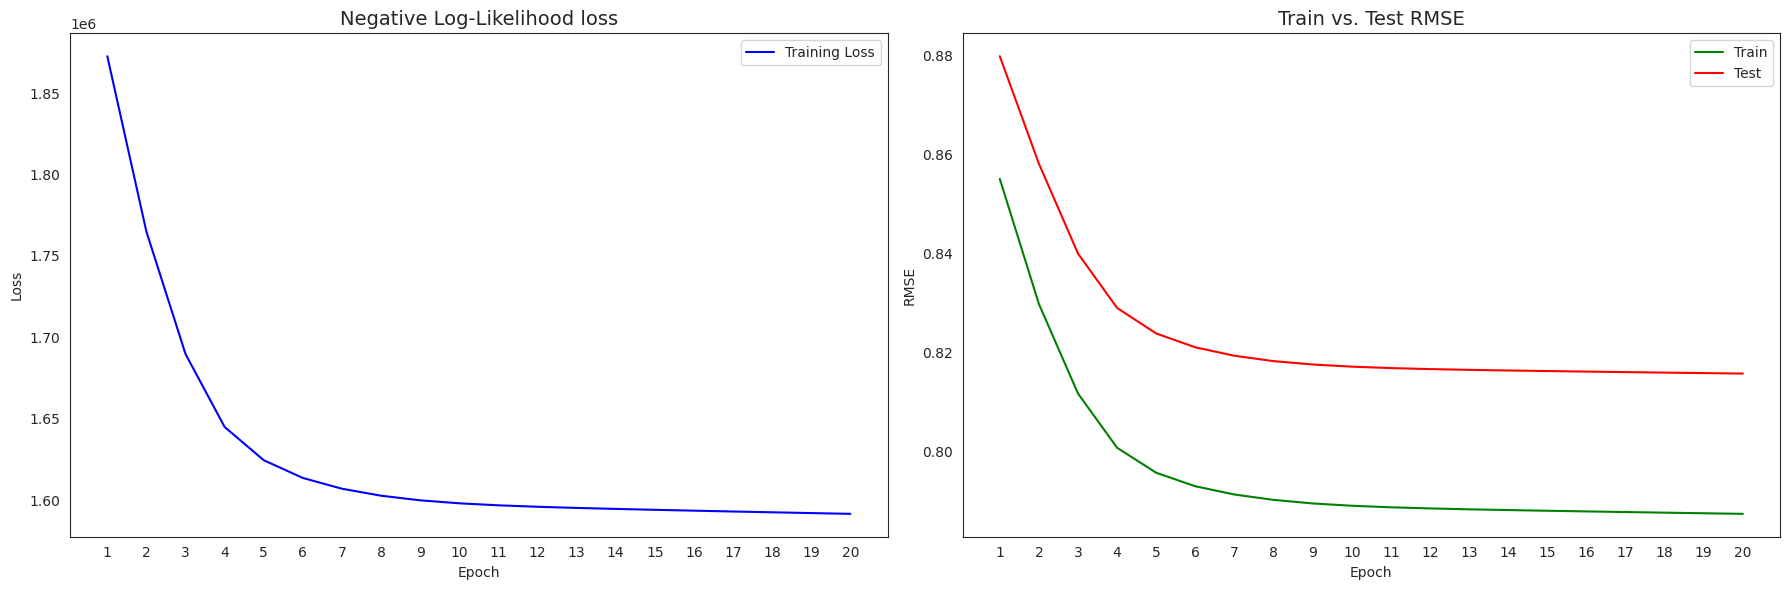

Precision@2: 0.0000 | Recall@2: 0.0000

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.1000, k=2
Epoch 5/20 | Loss: 1624704.00 | Train RMSE: 0.7943 | Test RMSE: 0.8217
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=5_k=2_lambda=0.1_tau=0.1_3.5399_20251119-110331.pkl

Epoch 10/20 | Loss: 1597891.00 | Train RMSE: 0.7874 | Test RMSE: 0.8147
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=10_k=2_lambda=0.1_tau=0.1_3.5399_20251119-110344.pkl

Epoch 15/20 | Loss: 1595091.38 | Train RMSE: 0.7867 | Test RMSE: 0.8140
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=15_k=2_lambda=0.1_tau=0.1_3.5399_20251119-110356.pkl

Epoch 20/20 | Loss: 1594578.25 | Train RMSE: 0.7865 | Test RMSE: 0.8139
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=20_k=2_lambda=0.1_tau=0.1_3.5399_20251119-110406.pkl



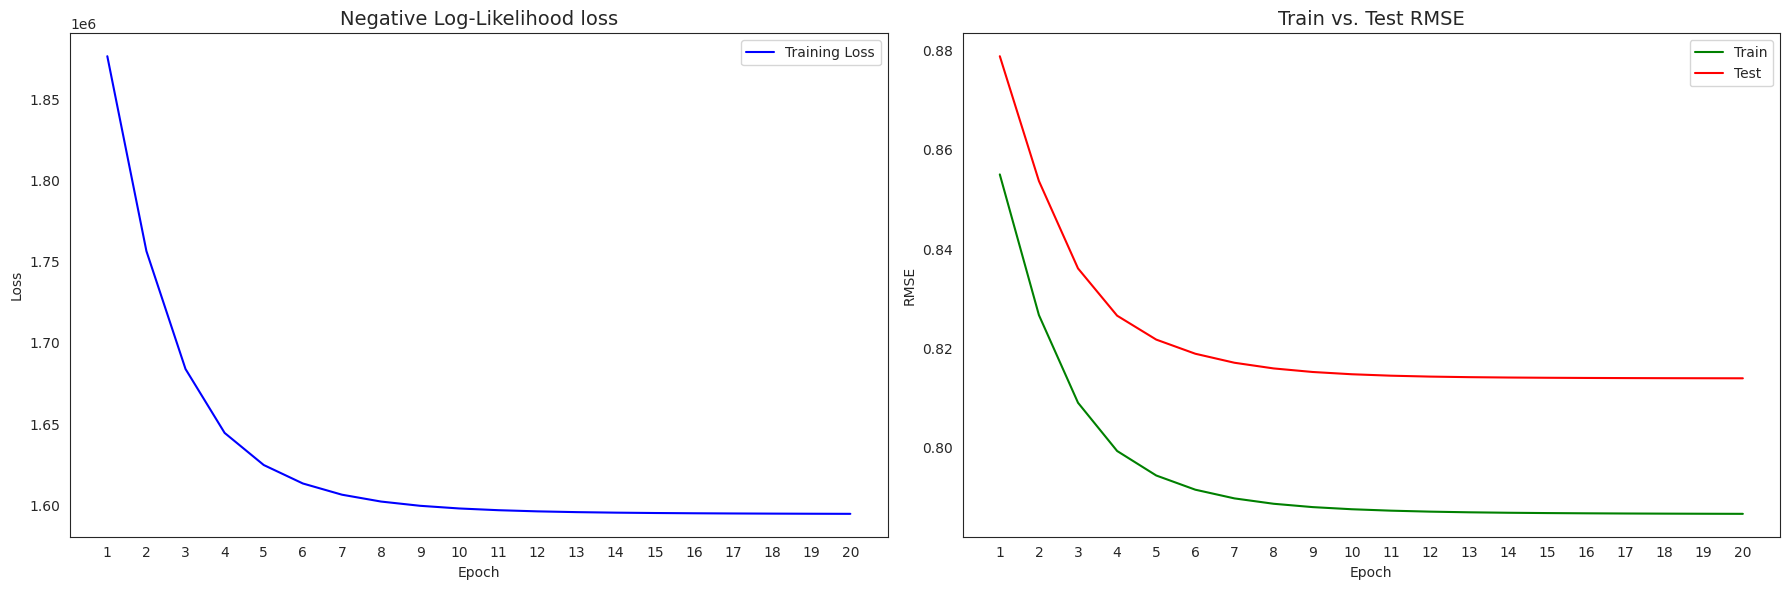

Precision@2: 0.0000 | Recall@2: 0.0000

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.2500, k=2
Epoch 5/20 | Loss: 1645342.38 | Train RMSE: 0.7965 | Test RMSE: 0.8211
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=5_k=2_lambda=0.1_tau=0.25_3.5399_20251119-110500.pkl

Epoch 10/20 | Loss: 1620986.75 | Train RMSE: 0.7901 | Test RMSE: 0.8149
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=10_k=2_lambda=0.1_tau=0.25_3.5399_20251119-110512.pkl

Epoch 15/20 | Loss: 1616751.25 | Train RMSE: 0.7888 | Test RMSE: 0.8138
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=15_k=2_lambda=0.1_tau=0.25_3.5399_20251119-110522.pkl

Epoch 20/20 | Loss: 1615596.62 | Train RMSE: 0.7884 | Test RMSE: 0.8135
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.1/ALS_epoch=20_k=2_lambda=0.1_tau=0.25_3.5399_20251119-110534.pkl



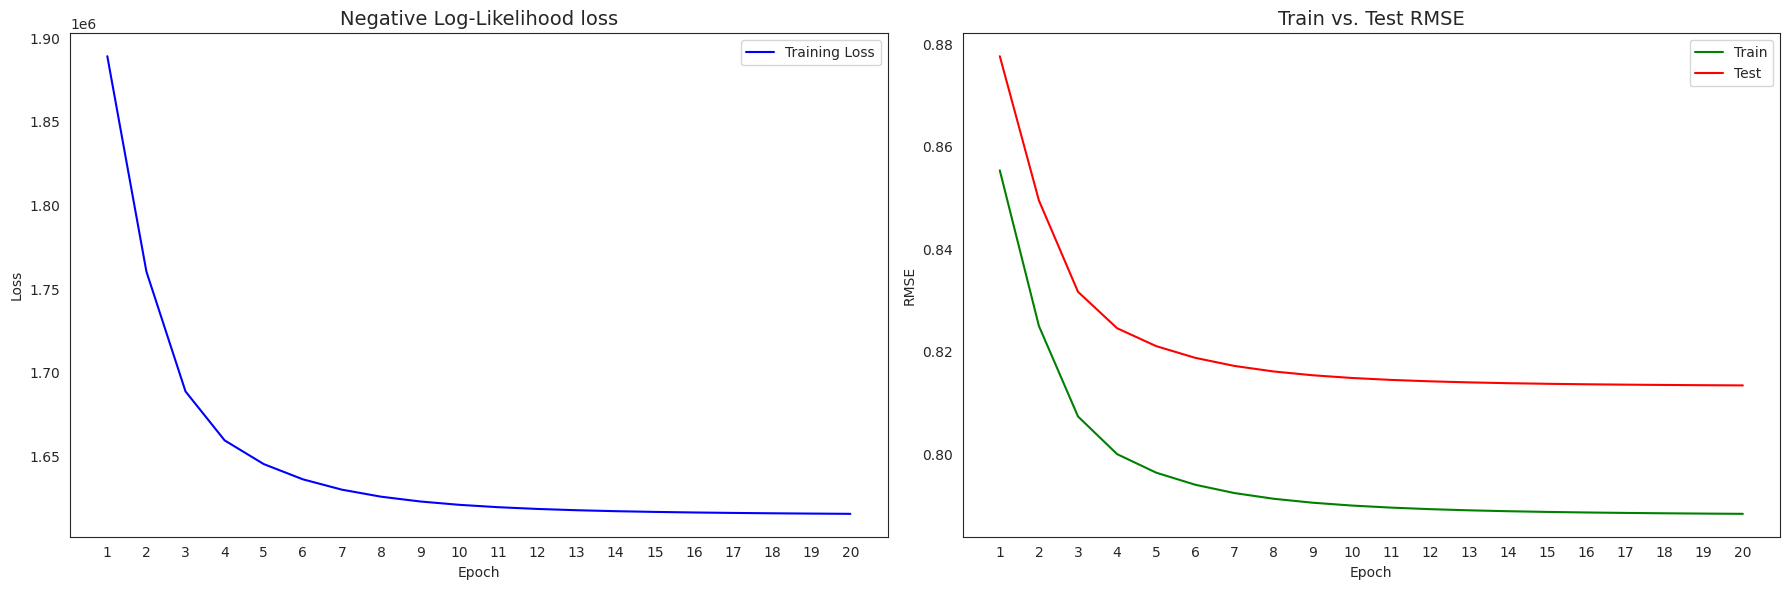

Precision@2: 0.0082 | Recall@2: 0.0015

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.0500, k=2
Epoch 5/20 | Loss: 8017295.00 | Train RMSE: 0.7918 | Test RMSE: 0.8224
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=5_k=2_lambda=0.5_tau=0.05_3.5399_20251119-110633.pkl

Epoch 10/20 | Loss: 7895310.50 | Train RMSE: 0.7858 | Test RMSE: 0.8162
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=10_k=2_lambda=0.5_tau=0.05_3.5399_20251119-110643.pkl

Epoch 15/20 | Loss: 7883814.00 | Train RMSE: 0.7852 | Test RMSE: 0.8158
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=15_k=2_lambda=0.5_tau=0.05_3.5399_20251119-110654.pkl

Epoch 20/20 | Loss: 7881708.50 | Train RMSE: 0.7851 | Test RMSE: 0.8158
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=20_k=2_lambda=0.5_tau=0.05_3.5399_20251119-110706.pkl



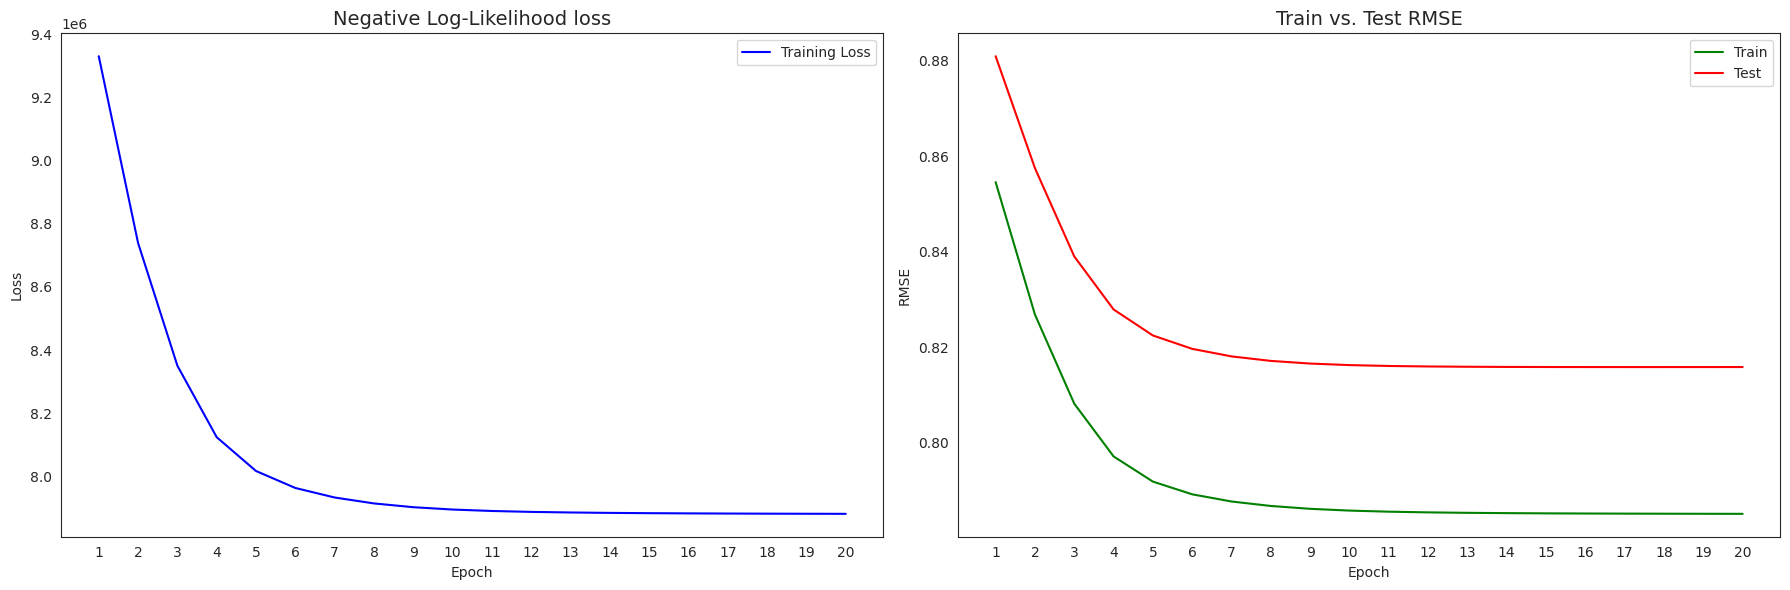

Precision@2: 0.0000 | Recall@2: 0.0000

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.1000, k=2
Epoch 5/20 | Loss: 7999419.50 | Train RMSE: 0.7905 | Test RMSE: 0.8200
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=5_k=2_lambda=0.5_tau=0.1_3.5399_20251119-110822.pkl

Epoch 10/20 | Loss: 7917735.50 | Train RMSE: 0.7864 | Test RMSE: 0.8159
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=10_k=2_lambda=0.5_tau=0.1_3.5399_20251119-110834.pkl

Epoch 15/20 | Loss: 7906070.00 | Train RMSE: 0.7858 | Test RMSE: 0.8155
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=15_k=2_lambda=0.5_tau=0.1_3.5399_20251119-110844.pkl

Epoch 20/20 | Loss: 7900250.50 | Train RMSE: 0.7855 | Test RMSE: 0.8154
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=20_k=2_lambda=0.5_tau=0.1_3.5399_20251119-110856.pkl



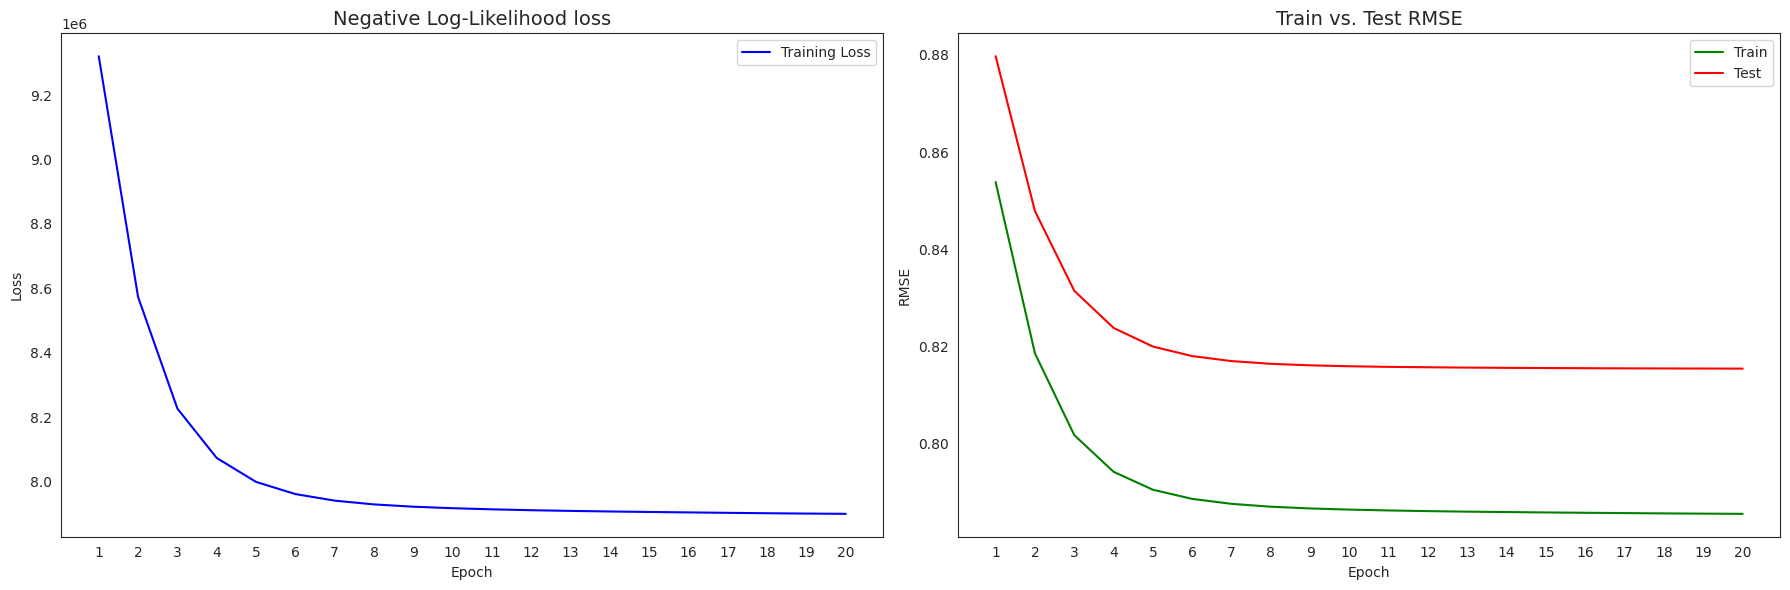

Precision@2: 0.0000 | Recall@2: 0.0000

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.2500, k=2
Epoch 5/20 | Loss: 8067117.00 | Train RMSE: 0.7928 | Test RMSE: 0.8213
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=5_k=2_lambda=0.5_tau=0.25_3.5399_20251119-111000.pkl

Epoch 10/20 | Loss: 7938412.50 | Train RMSE: 0.7863 | Test RMSE: 0.8149
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=10_k=2_lambda=0.5_tau=0.25_3.5399_20251119-111012.pkl

Epoch 15/20 | Loss: 7930362.50 | Train RMSE: 0.7859 | Test RMSE: 0.8146
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=15_k=2_lambda=0.5_tau=0.25_3.5399_20251119-111024.pkl

Epoch 20/20 | Loss: 7928436.00 | Train RMSE: 0.7858 | Test RMSE: 0.8145
Saved model checkpoint → /content/drive/MyDrive/recommender/k=2_lambda=0.5/ALS_epoch=20_k=2_lambda=0.5_tau=0.25_3.5399_20251119-111034.pkl



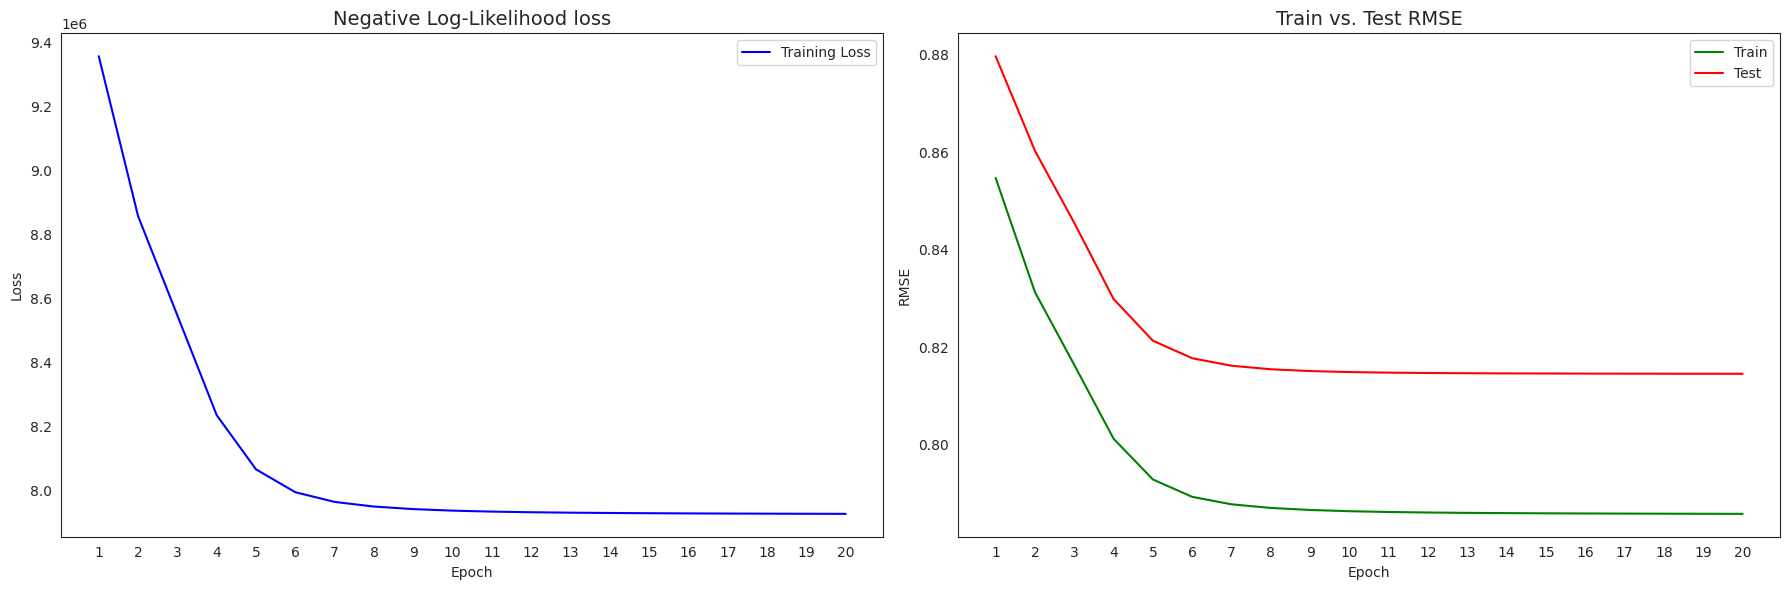

Precision@2: 0.0000 | Recall@2: 0.0000

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.0500, k=10
Epoch 5/20 | Loss: 1330484.50 | Train RMSE: 0.7146 | Test RMSE: 0.8112
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=5_k=10_lambda=0.1_tau=0.05_3.5399_20251119-111242.pkl

Epoch 10/20 | Loss: 1277813.38 | Train RMSE: 0.7003 | Test RMSE: 0.7961
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=10_k=10_lambda=0.1_tau=0.05_3.5399_20251119-111406.pkl

Epoch 15/20 | Loss: 1265413.25 | Train RMSE: 0.6971 | Test RMSE: 0.7931
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=15_k=10_lambda=0.1_tau=0.05_3.5399_20251119-111531.pkl

Epoch 20/20 | Loss: 1260735.00 | Train RMSE: 0.6959 | Test RMSE: 0.7924
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=20_k=10_lambda=0.1_tau=0.05_3.5399_20251119-111656.pkl



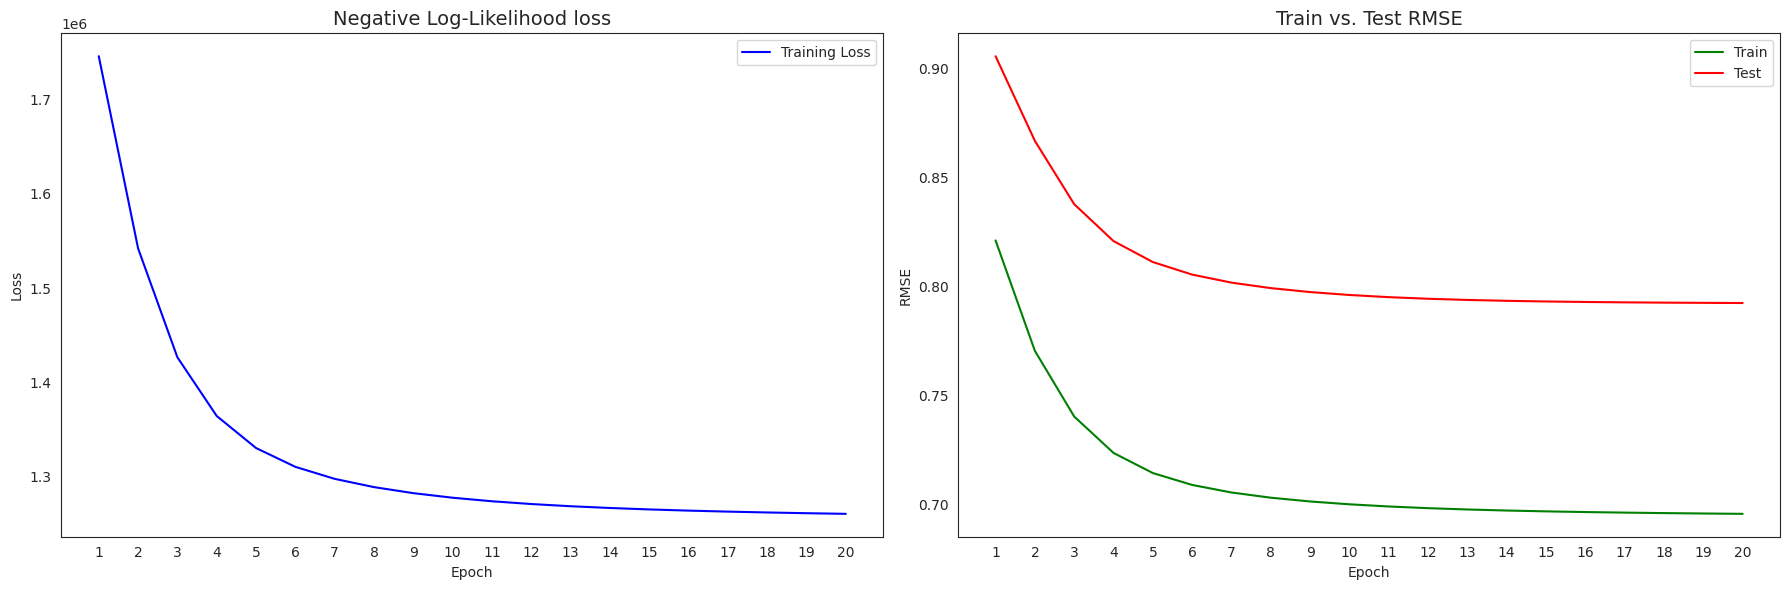

Precision@10: 0.0028 | Recall@10: 0.0018

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.1000, k=10
Epoch 5/20 | Loss: 1339813.38 | Train RMSE: 0.7139 | Test RMSE: 0.8028
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=5_k=10_lambda=0.1_tau=0.1_3.5399_20251119-111904.pkl

Epoch 10/20 | Loss: 1292458.38 | Train RMSE: 0.7012 | Test RMSE: 0.7899
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=10_k=10_lambda=0.1_tau=0.1_3.5399_20251119-112027.pkl

Epoch 15/20 | Loss: 1282607.12 | Train RMSE: 0.6988 | Test RMSE: 0.7880
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=15_k=10_lambda=0.1_tau=0.1_3.5399_20251119-112150.pkl

Epoch 20/20 | Loss: 1278652.25 | Train RMSE: 0.6980 | Test RMSE: 0.7877
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=20_k=10_lambda=0.1_tau=0.1_3.5399_20251119-112312.pkl



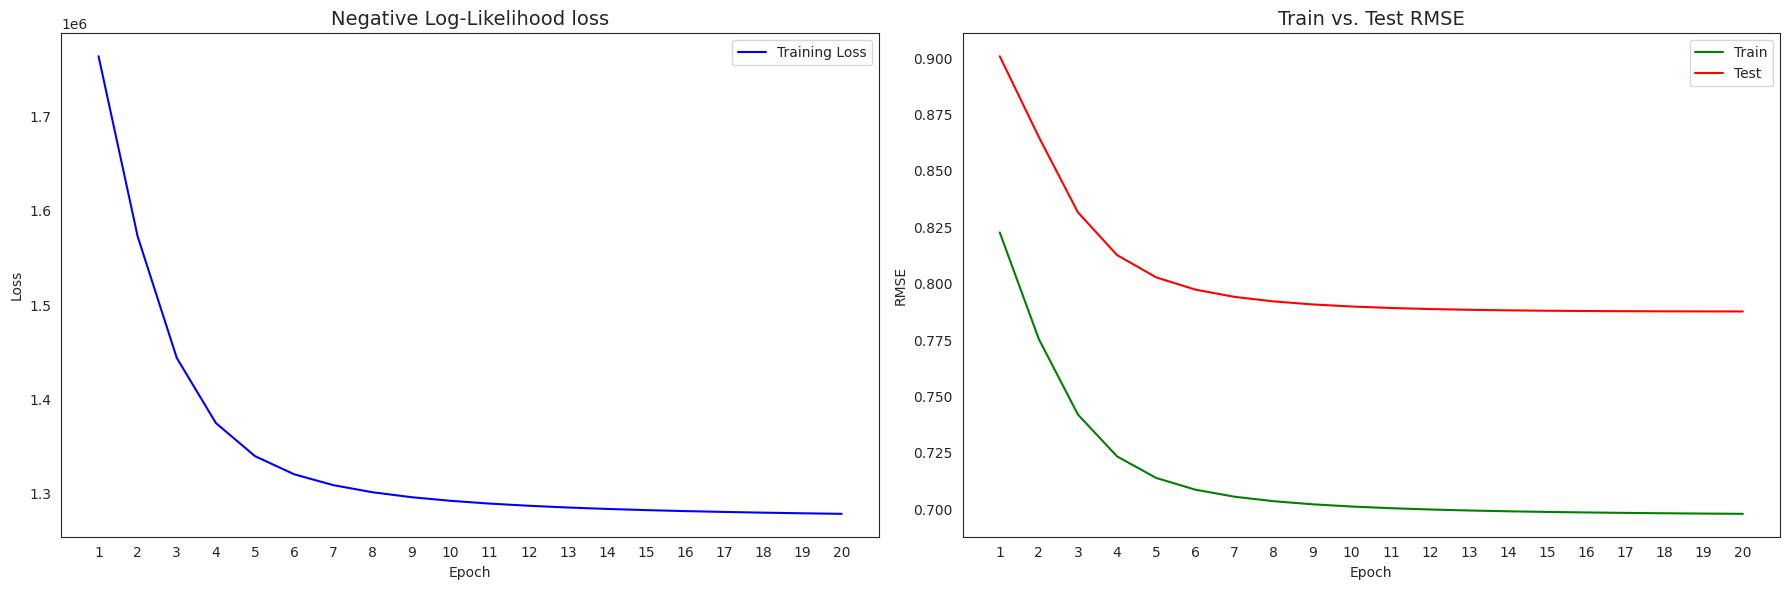

Precision@10: 0.0159 | Recall@10: 0.0098

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.2500, k=10
Epoch 5/20 | Loss: 1373534.62 | Train RMSE: 0.7174 | Test RMSE: 0.7968
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=5_k=10_lambda=0.1_tau=0.25_3.5399_20251119-112526.pkl

Epoch 10/20 | Loss: 1325046.62 | Train RMSE: 0.7045 | Test RMSE: 0.7843
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=10_k=10_lambda=0.1_tau=0.25_3.5399_20251119-112651.pkl

Epoch 15/20 | Loss: 1316491.62 | Train RMSE: 0.7026 | Test RMSE: 0.7830
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=15_k=10_lambda=0.1_tau=0.25_3.5399_20251119-112812.pkl

Epoch 20/20 | Loss: 1313304.75 | Train RMSE: 0.7020 | Test RMSE: 0.7828
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.1/ALS_epoch=20_k=10_lambda=0.1_tau=0.25_3.5399_20251119-112935.pkl



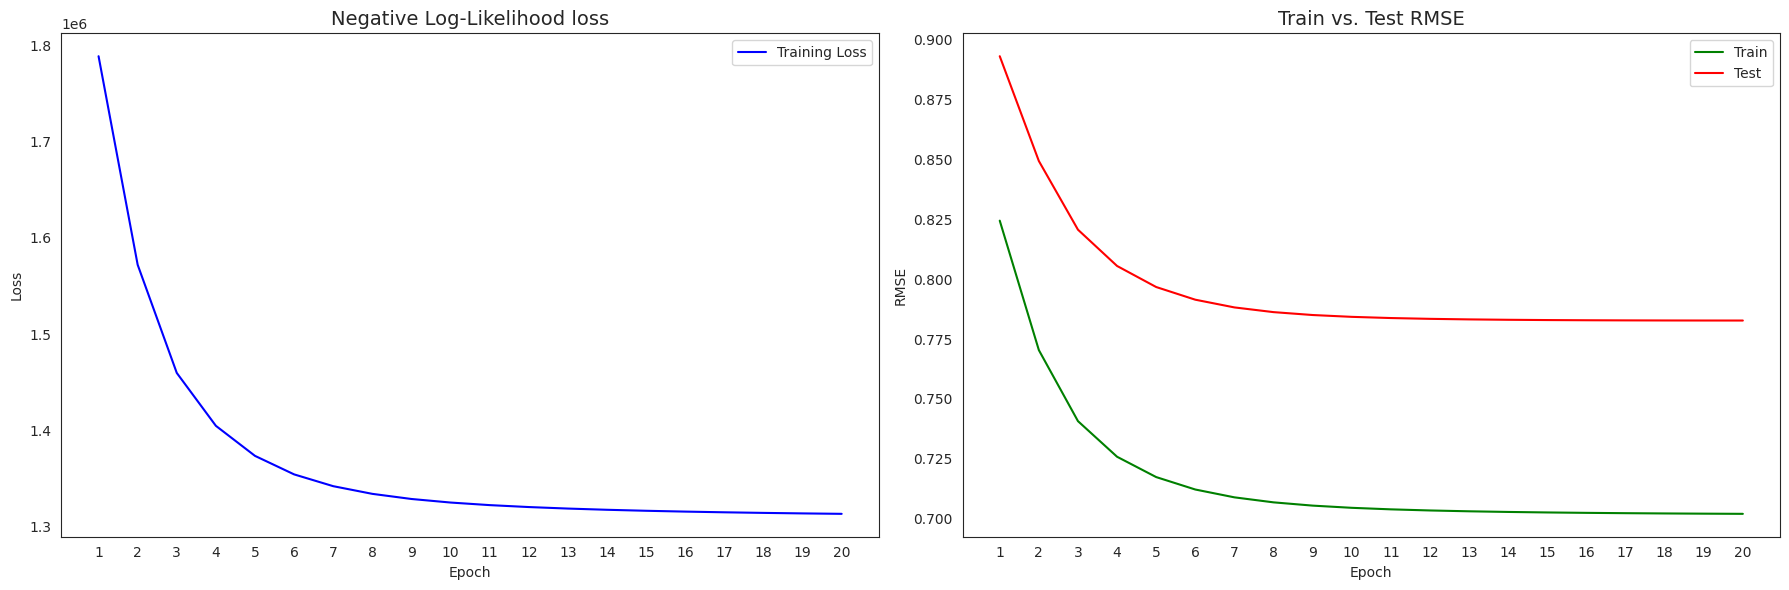

Precision@10: 0.0430 | Recall@10: 0.0257

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.0500, k=10
Epoch 5/20 | Loss: 6616603.50 | Train RMSE: 0.7171 | Test RMSE: 0.8304
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=5_k=10_lambda=0.5_tau=0.05_3.5399_20251119-113145.pkl

Epoch 10/20 | Loss: 6297409.50 | Train RMSE: 0.6996 | Test RMSE: 0.8107
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=10_k=10_lambda=0.5_tau=0.05_3.5399_20251119-113309.pkl

Epoch 15/20 | Loss: 6220763.50 | Train RMSE: 0.6954 | Test RMSE: 0.8059
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=15_k=10_lambda=0.5_tau=0.05_3.5399_20251119-113432.pkl

Epoch 20/20 | Loss: 6193691.00 | Train RMSE: 0.6940 | Test RMSE: 0.8047
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=20_k=10_lambda=0.5_tau=0.05_3.5399_20251119-113555.pkl



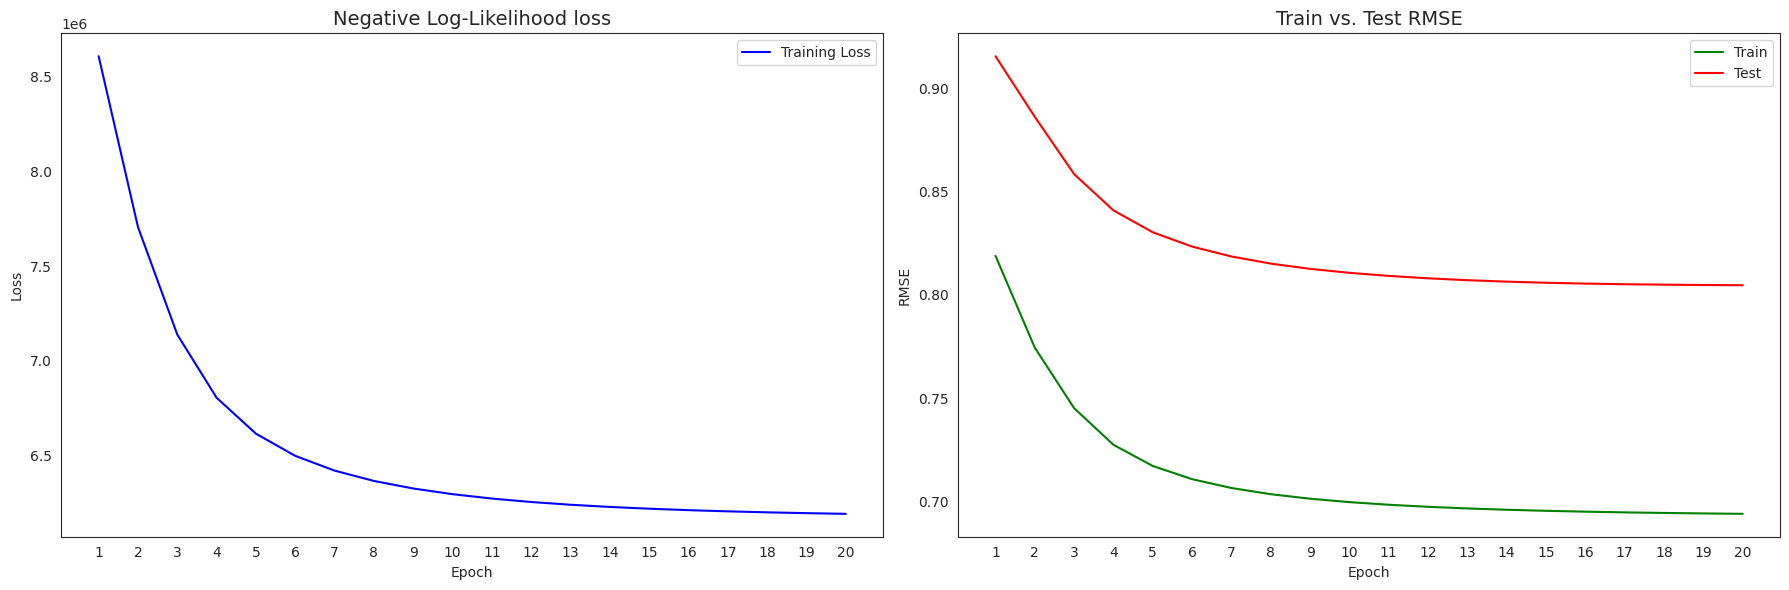

Precision@10: 0.0000 | Recall@10: 0.0000

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.1000, k=10
Epoch 5/20 | Loss: 6649442.50 | Train RMSE: 0.7174 | Test RMSE: 0.8231
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=5_k=10_lambda=0.5_tau=0.1_3.5399_20251119-113804.pkl

Epoch 10/20 | Loss: 6324281.50 | Train RMSE: 0.6996 | Test RMSE: 0.8036
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=10_k=10_lambda=0.5_tau=0.1_3.5399_20251119-113926.pkl

Epoch 15/20 | Loss: 6259150.50 | Train RMSE: 0.6961 | Test RMSE: 0.8002
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=15_k=10_lambda=0.5_tau=0.1_3.5399_20251119-114048.pkl

Epoch 20/20 | Loss: 6235339.50 | Train RMSE: 0.6948 | Test RMSE: 0.7995
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=20_k=10_lambda=0.5_tau=0.1_3.5399_20251119-114209.pkl



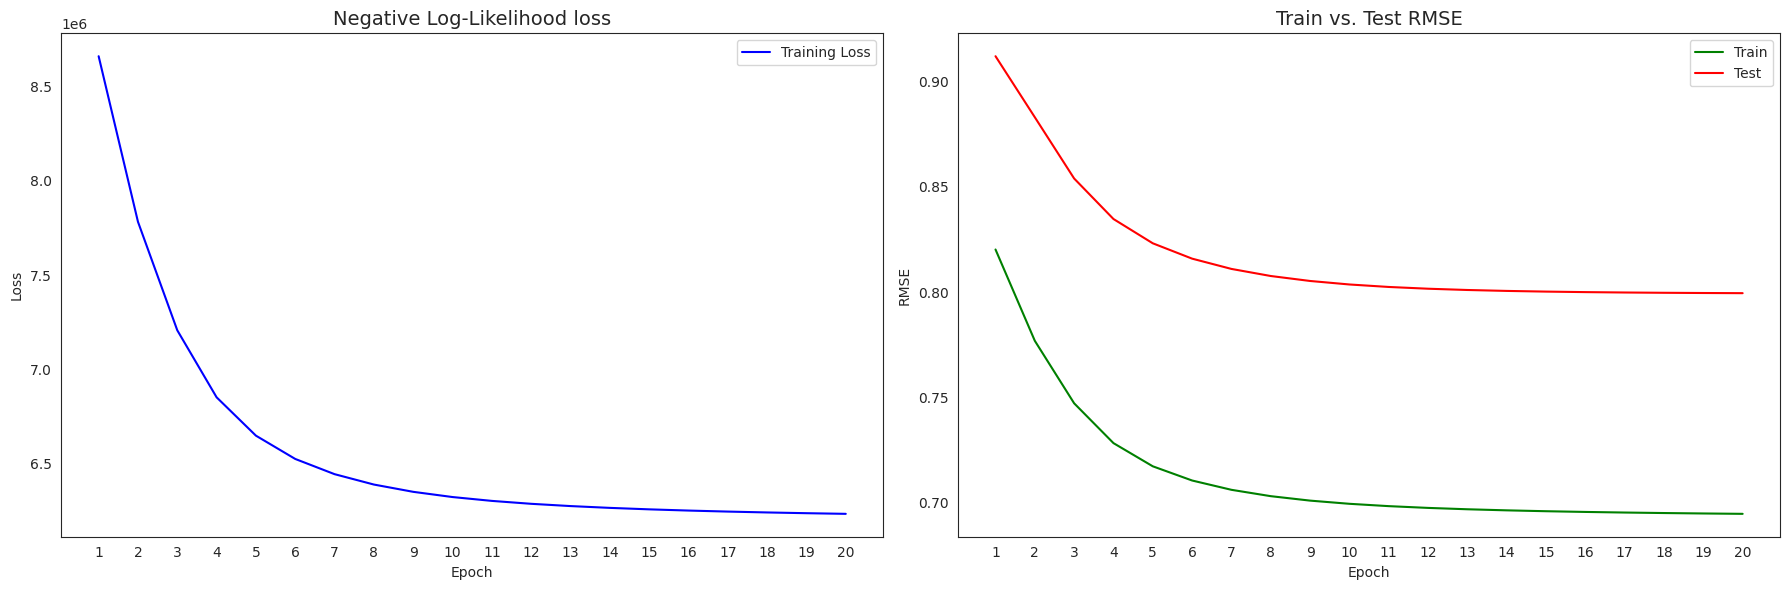

Precision@10: 0.0000 | Recall@10: 0.0000

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.2500, k=10
Epoch 5/20 | Loss: 6657273.00 | Train RMSE: 0.7148 | Test RMSE: 0.8109
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=5_k=10_lambda=0.5_tau=0.25_3.5399_20251119-114418.pkl

Epoch 10/20 | Loss: 6368371.00 | Train RMSE: 0.6991 | Test RMSE: 0.7941
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=10_k=10_lambda=0.5_tau=0.25_3.5399_20251119-114540.pkl

Epoch 15/20 | Loss: 6316262.00 | Train RMSE: 0.6965 | Test RMSE: 0.7920
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=15_k=10_lambda=0.5_tau=0.25_3.5399_20251119-114706.pkl

Epoch 20/20 | Loss: 6299058.00 | Train RMSE: 0.6957 | Test RMSE: 0.7919
Saved model checkpoint → /content/drive/MyDrive/recommender/k=10_lambda=0.5/ALS_epoch=20_k=10_lambda=0.5_tau=0.25_3.5399_20251119-114828.pkl



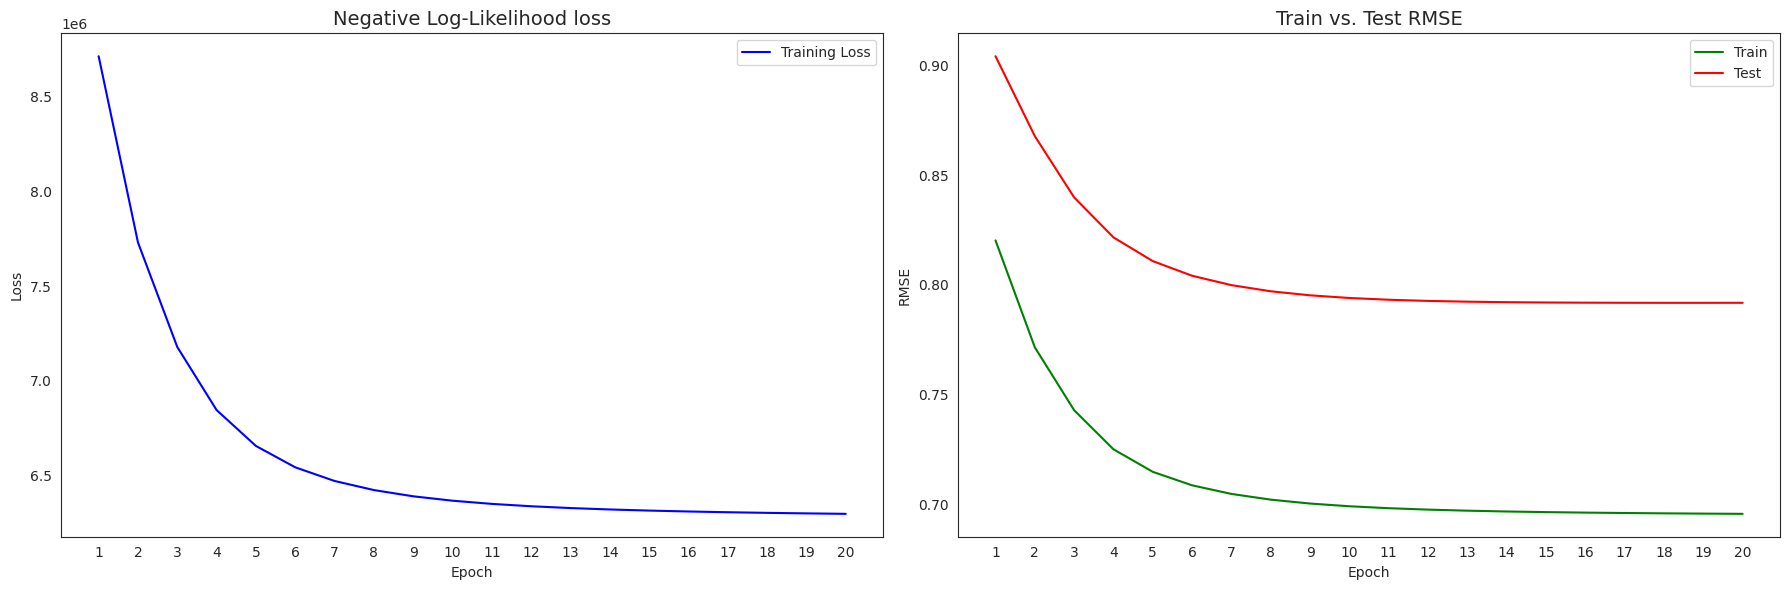

Precision@10: 0.0023 | Recall@10: 0.0013

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.0500, k=50
Epoch 5/20 | Loss: 887466.88 | Train RMSE: 0.5624 | Test RMSE: 0.8907
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=5_k=50_lambda=0.1_tau=0.05_3.5399_20251119-115651.pkl

Epoch 10/20 | Loss: 812422.75 | Train RMSE: 0.5412 | Test RMSE: 0.8919
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=10_k=50_lambda=0.1_tau=0.05_3.5399_20251119-120440.pkl

Epoch 15/20 | Loss: 785188.06 | Train RMSE: 0.5339 | Test RMSE: 0.8982
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=15_k=50_lambda=0.1_tau=0.05_3.5399_20251119-121224.pkl

Epoch 20/20 | Loss: 771182.12 | Train RMSE: 0.5302 | Test RMSE: 0.9041
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=20_k=50_lambda=0.1_tau=0.05_3.5399_20251119-122003.pkl



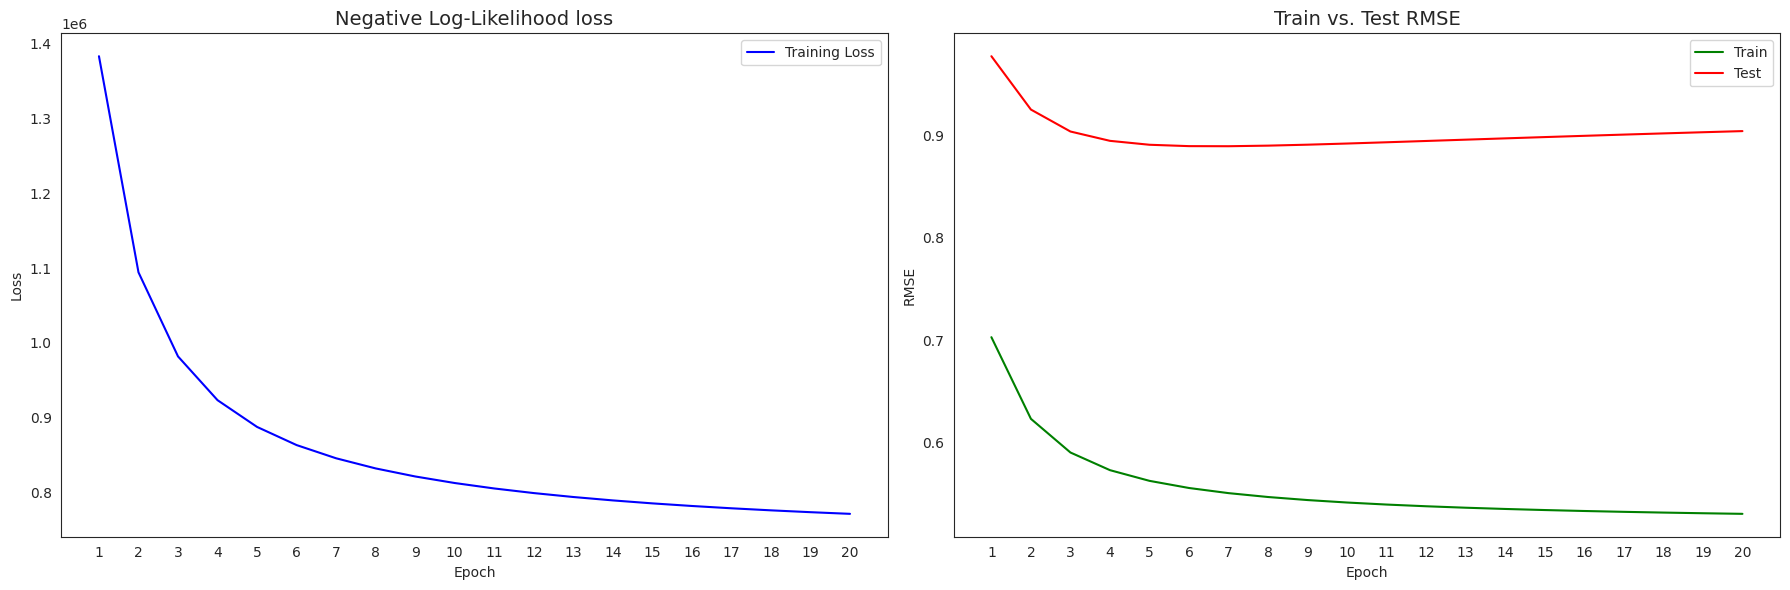

Precision@50: 0.0043 | Recall@50: 0.0085

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.1000, k=50
Epoch 5/20 | Loss: 912286.62 | Train RMSE: 0.5638 | Test RMSE: 0.8723
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=5_k=50_lambda=0.1_tau=0.1_3.5399_20251119-122850.pkl

Epoch 10/20 | Loss: 838165.19 | Train RMSE: 0.5437 | Test RMSE: 0.8734
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=10_k=50_lambda=0.1_tau=0.1_3.5399_20251119-123639.pkl

Epoch 15/20 | Loss: 812999.19 | Train RMSE: 0.5373 | Test RMSE: 0.8788
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=15_k=50_lambda=0.1_tau=0.1_3.5399_20251119-124421.pkl

Epoch 20/20 | Loss: 800675.88 | Train RMSE: 0.5342 | Test RMSE: 0.8834
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=20_k=50_lambda=0.1_tau=0.1_3.5399_20251119-125201.pkl



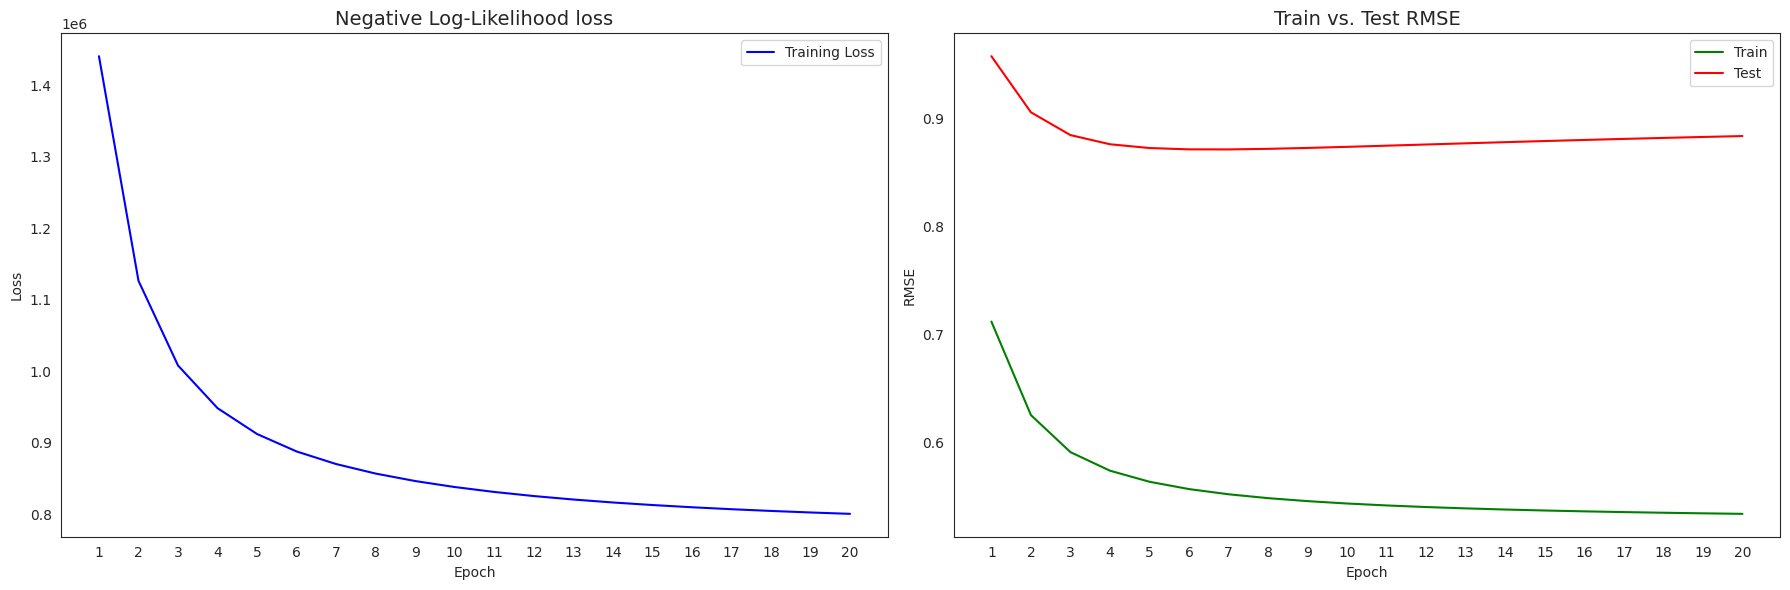

Precision@50: 0.0119 | Recall@50: 0.0284

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.2500, k=50
Epoch 5/20 | Loss: 964323.50 | Train RMSE: 0.5696 | Test RMSE: 0.8526
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=5_k=50_lambda=0.1_tau=0.25_3.5399_20251119-130046.pkl

Epoch 10/20 | Loss: 897902.69 | Train RMSE: 0.5522 | Test RMSE: 0.8519
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=10_k=50_lambda=0.1_tau=0.25_3.5399_20251119-130830.pkl

Epoch 15/20 | Loss: 877191.88 | Train RMSE: 0.5470 | Test RMSE: 0.8549
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=15_k=50_lambda=0.1_tau=0.25_3.5399_20251119-131613.pkl

Epoch 20/20 | Loss: 867596.19 | Train RMSE: 0.5446 | Test RMSE: 0.8574
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.1/ALS_epoch=20_k=50_lambda=0.1_tau=0.25_3.5399_20251119-132354.pkl



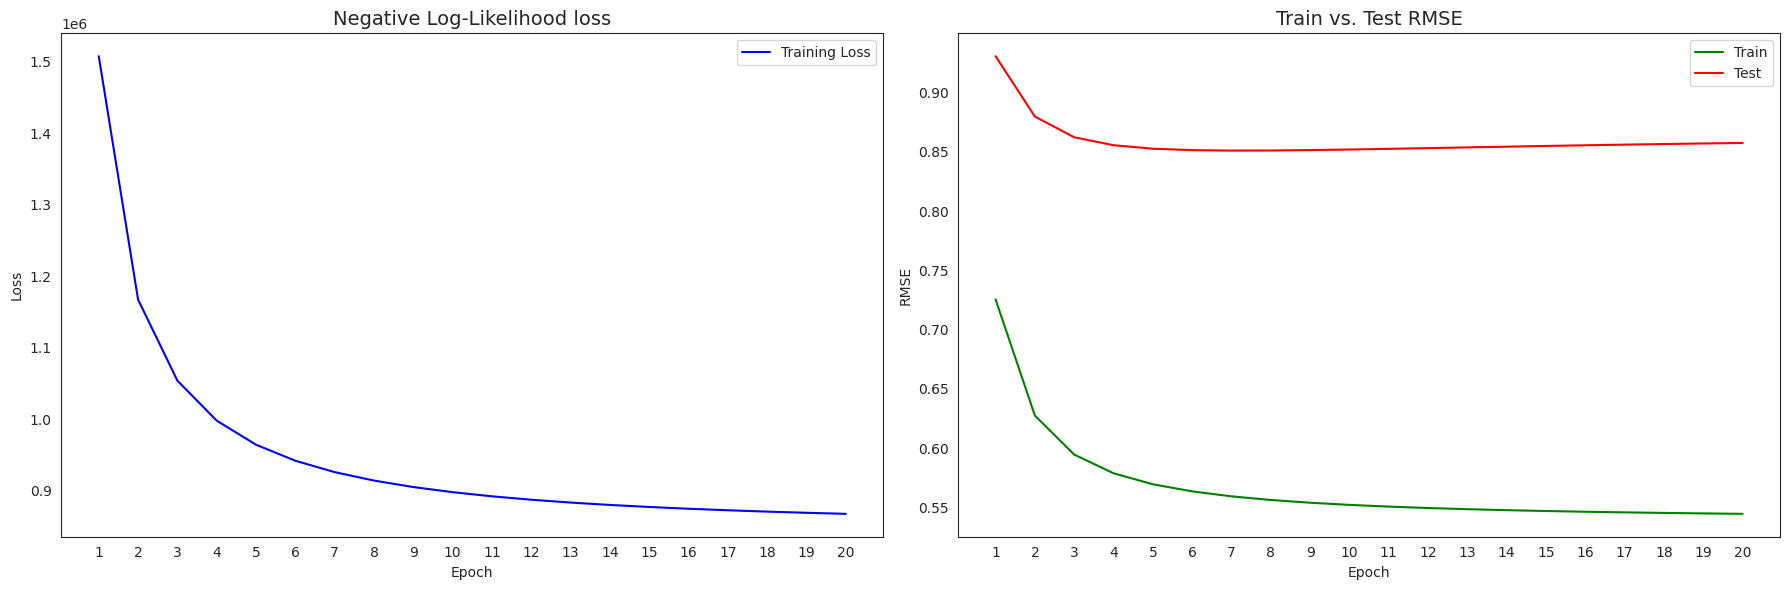

Precision@50: 0.0258 | Recall@50: 0.0713

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.0500, k=50
Epoch 5/20 | Loss: 4301539.00 | Train RMSE: 0.5655 | Test RMSE: 0.9535
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=5_k=50_lambda=0.5_tau=0.05_3.5399_20251119-133245.pkl

Epoch 10/20 | Loss: 3919069.00 | Train RMSE: 0.5411 | Test RMSE: 0.9490
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=10_k=50_lambda=0.5_tau=0.05_3.5399_20251119-134029.pkl

Epoch 15/20 | Loss: 3777398.00 | Train RMSE: 0.5324 | Test RMSE: 0.9564
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=15_k=50_lambda=0.5_tau=0.05_3.5399_20251119-134813.pkl

Epoch 20/20 | Loss: 3701014.50 | Train RMSE: 0.5278 | Test RMSE: 0.9645
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=20_k=50_lambda=0.5_tau=0.05_3.5399_20251119-135558.pkl



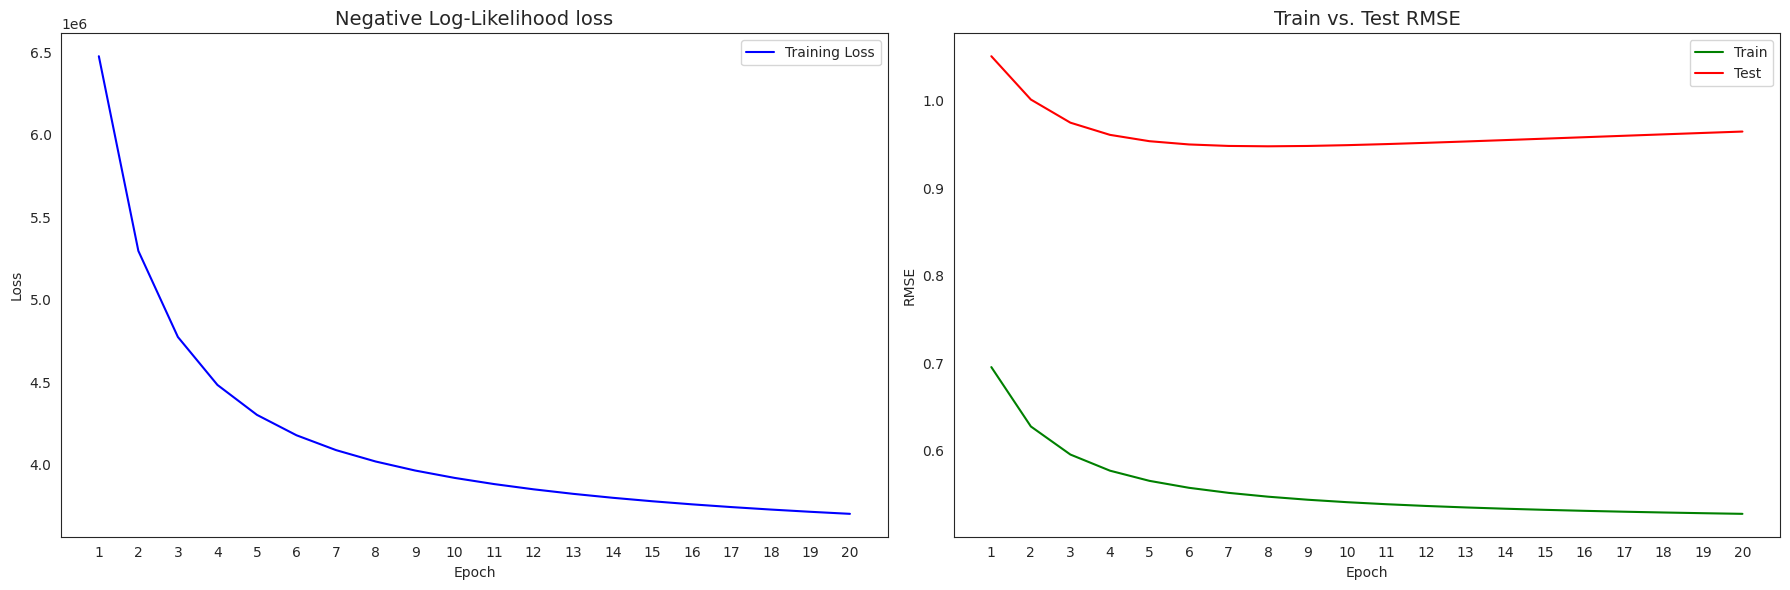

Precision@50: 0.0001 | Recall@50: 0.0002

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.1000, k=50
Epoch 5/20 | Loss: 4345392.00 | Train RMSE: 0.5638 | Test RMSE: 0.9227
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=5_k=50_lambda=0.5_tau=0.1_3.5399_20251119-140444.pkl

Epoch 10/20 | Loss: 3963149.00 | Train RMSE: 0.5406 | Test RMSE: 0.9214
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=10_k=50_lambda=0.5_tau=0.1_3.5399_20251119-141229.pkl

Epoch 15/20 | Loss: 3823116.75 | Train RMSE: 0.5324 | Test RMSE: 0.9287
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=15_k=50_lambda=0.5_tau=0.1_3.5399_20251119-142011.pkl

Epoch 20/20 | Loss: 3747808.25 | Train RMSE: 0.5282 | Test RMSE: 0.9360
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=20_k=50_lambda=0.5_tau=0.1_3.5399_20251119-142750.pkl



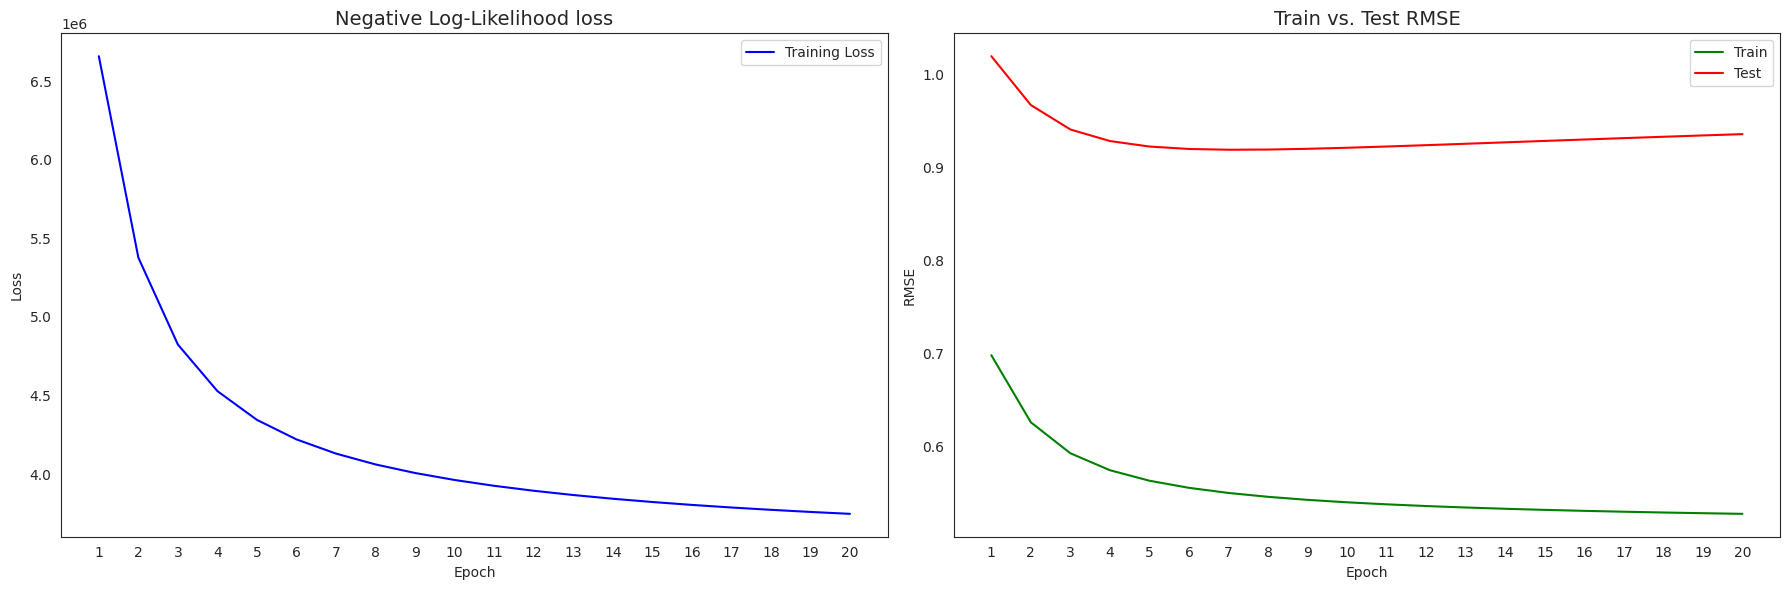

Precision@50: 0.0006 | Recall@50: 0.0009

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.2500, k=50
Epoch 5/20 | Loss: 4435031.00 | Train RMSE: 0.5622 | Test RMSE: 0.8902
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=5_k=50_lambda=0.5_tau=0.25_3.5399_20251119-143635.pkl

Epoch 10/20 | Loss: 4059631.25 | Train RMSE: 0.5410 | Test RMSE: 0.8911
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=10_k=50_lambda=0.5_tau=0.25_3.5399_20251119-144418.pkl

Epoch 15/20 | Loss: 3925947.00 | Train RMSE: 0.5338 | Test RMSE: 0.8977
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=15_k=50_lambda=0.5_tau=0.25_3.5399_20251119-145158.pkl

Epoch 20/20 | Loss: 3857541.00 | Train RMSE: 0.5303 | Test RMSE: 0.9040
Saved model checkpoint → /content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=20_k=50_lambda=0.5_tau=0.25_3.5399_20251119-145942.pkl



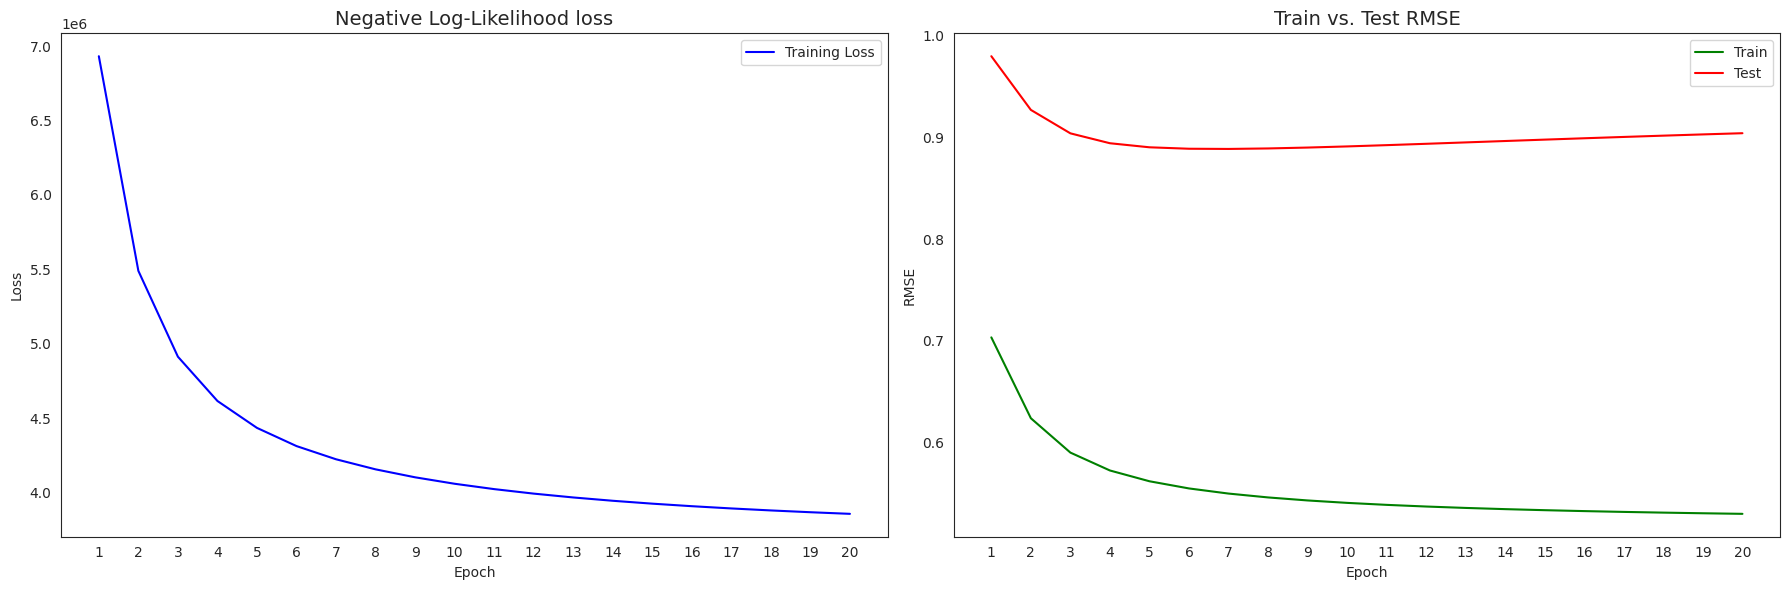

Precision@50: 0.0043 | Recall@50: 0.0085

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.0500, k=100
Epoch 5/20 | Loss: 639990.12 | Train RMSE: 0.4565 | Test RMSE: 0.9512
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=5_k=100_lambda=0.1_tau=0.05_3.5399_20251119-152450.pkl

Epoch 10/20 | Loss: 556032.25 | Train RMSE: 0.4318 | Test RMSE: 0.9694
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=10_k=100_lambda=0.1_tau=0.05_3.5399_20251119-154858.pkl

Epoch 15/20 | Loss: 524548.19 | Train RMSE: 0.4225 | Test RMSE: 0.9849
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=15_k=100_lambda=0.1_tau=0.05_3.5399_20251119-161302.pkl

Epoch 20/20 | Loss: 508218.91 | Train RMSE: 0.4176 | Test RMSE: 0.9967
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=20_k=100_lambda=0.1_tau=0.05_3.5399_20251119-163711.pkl



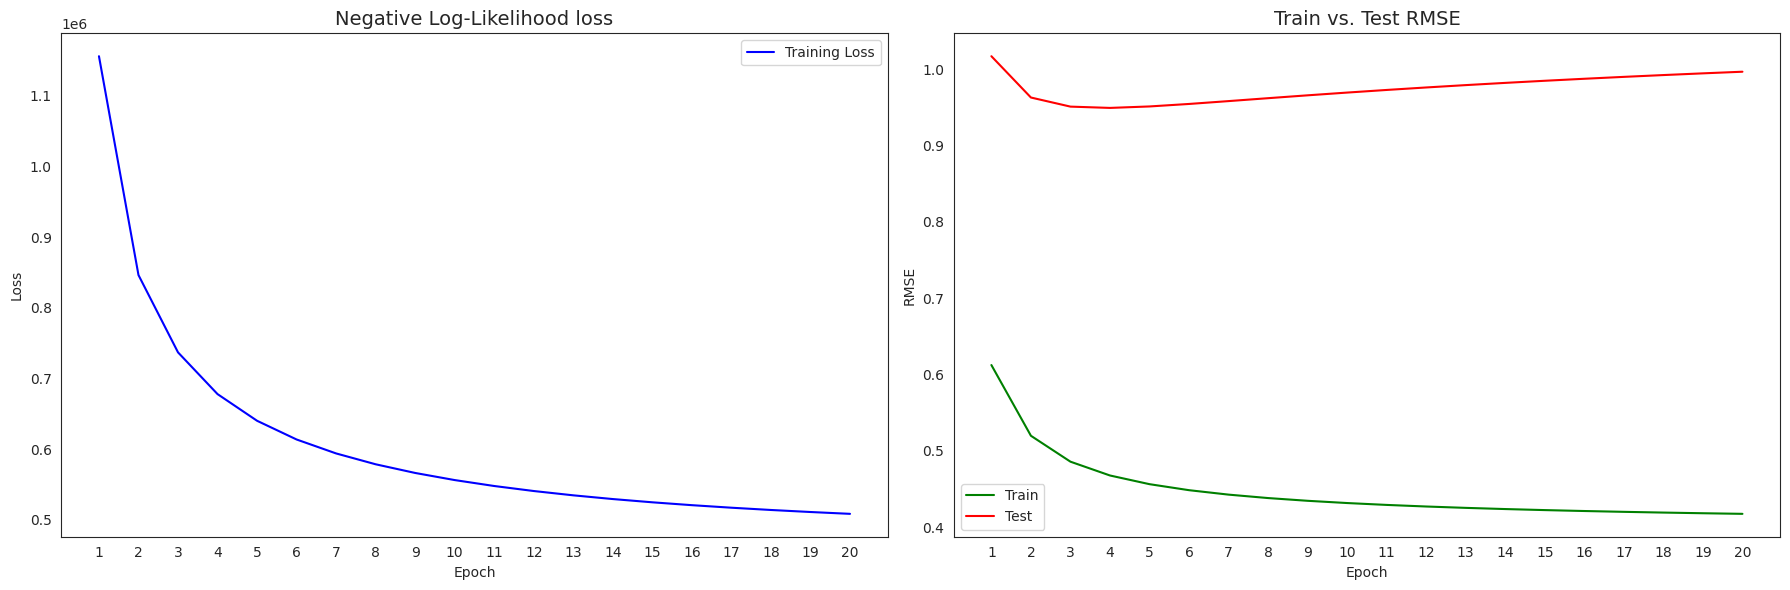

Precision@100: 0.0043 | Recall@100: 0.0211

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.1000, k=100
Epoch 5/20 | Loss: 666922.12 | Train RMSE: 0.4580 | Test RMSE: 0.9296
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=5_k=100_lambda=0.1_tau=0.1_3.5399_20251119-170245.pkl

Epoch 10/20 | Loss: 584210.12 | Train RMSE: 0.4346 | Test RMSE: 0.9455
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=10_k=100_lambda=0.1_tau=0.1_3.5399_20251119-172654.pkl

Epoch 15/20 | Loss: 555598.62 | Train RMSE: 0.4265 | Test RMSE: 0.9578
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=15_k=100_lambda=0.1_tau=0.1_3.5399_20251119-175120.pkl

Epoch 20/20 | Loss: 541597.69 | Train RMSE: 0.4225 | Test RMSE: 0.9667
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=20_k=100_lambda=0.1_tau=0.1_3.5399_20251119-181529.pkl



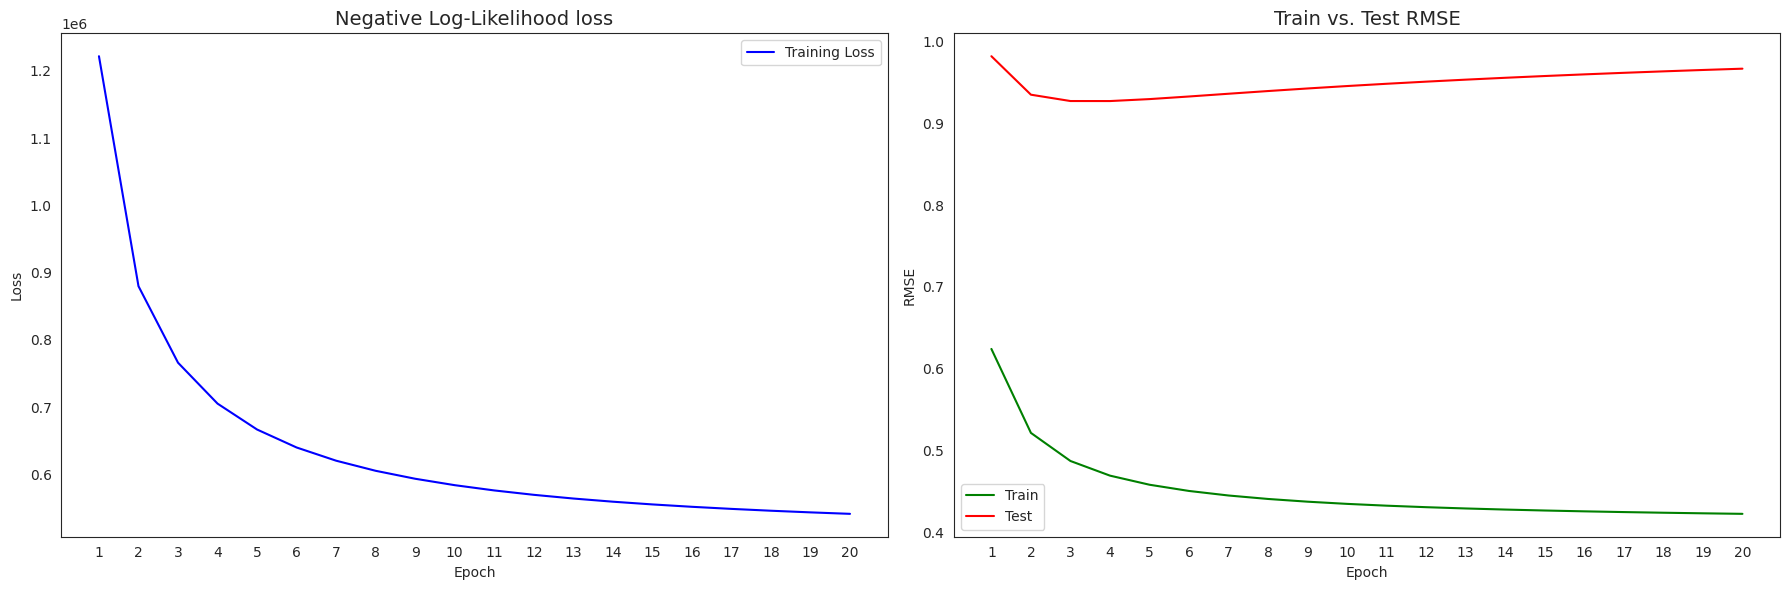

Precision@100: 0.0101 | Recall@100: 0.0577

Starting training for 20 epochs...
Hyperparameters: lambda=0.1, mu=3.5399, tau = 0.2500, k=100
Epoch 5/20 | Loss: 725399.00 | Train RMSE: 0.4646 | Test RMSE: 0.9031
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=5_k=100_lambda=0.1_tau=0.25_3.5399_20251119-184054.pkl

Epoch 10/20 | Loss: 654869.88 | Train RMSE: 0.4452 | Test RMSE: 0.9160
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=10_k=100_lambda=0.1_tau=0.25_3.5399_20251119-190503.pkl

Epoch 15/20 | Loss: 632870.31 | Train RMSE: 0.4391 | Test RMSE: 0.9248
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=15_k=100_lambda=0.1_tau=0.25_3.5399_20251119-192911.pkl

Epoch 20/20 | Loss: 622500.44 | Train RMSE: 0.4361 | Test RMSE: 0.9304
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.1/ALS_epoch=20_k=100_lambda=0.1_tau=0.25_3.5399_20251119-195311.pkl



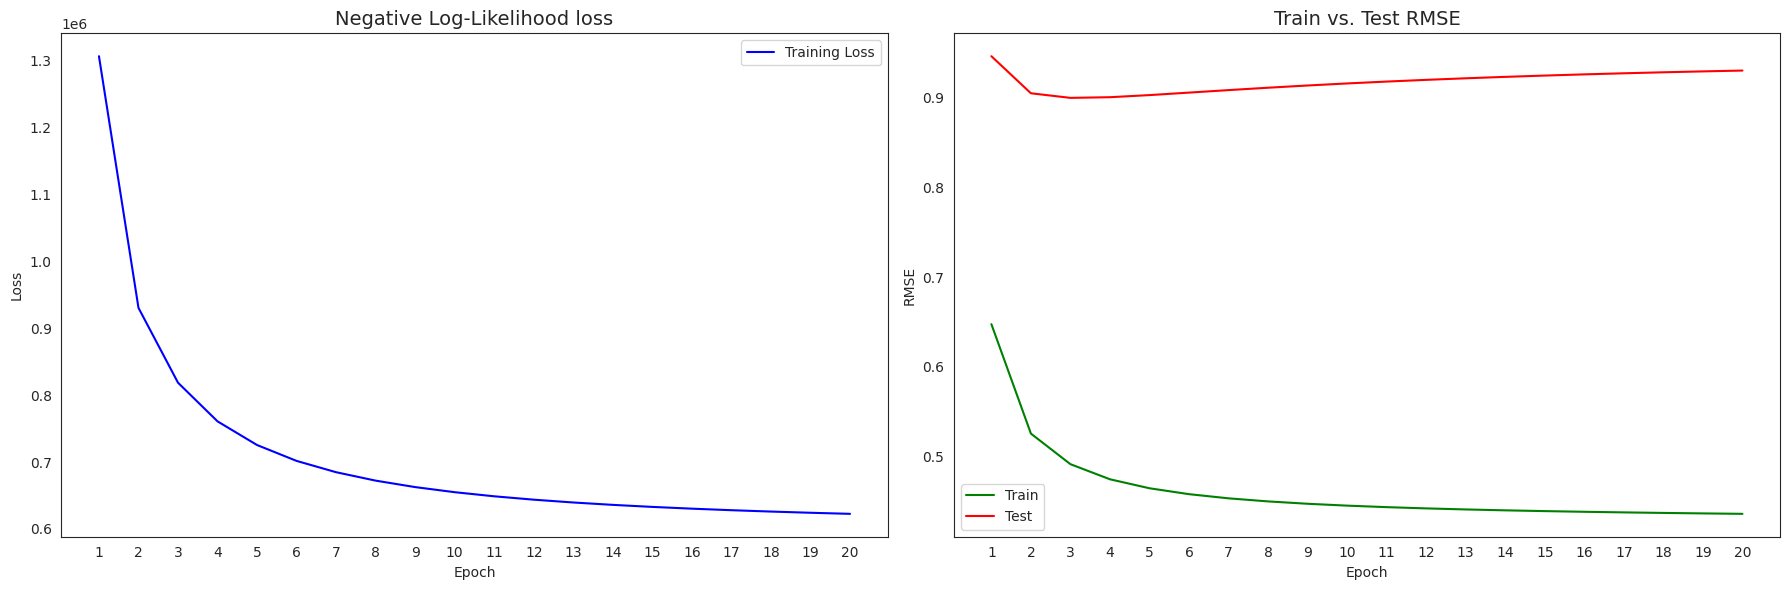

Precision@100: 0.0199 | Recall@100: 0.1149

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.0500, k=100
Epoch 5/20 | Loss: 3010945.00 | Train RMSE: 0.4593 | Test RMSE: 1.0246
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=5_k=100_lambda=0.5_tau=0.05_3.5399_20251119-201853.pkl

Epoch 10/20 | Loss: 2627931.25 | Train RMSE: 0.4323 | Test RMSE: 1.0365
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=10_k=100_lambda=0.5_tau=0.05_3.5399_20251119-204302.pkl

Epoch 15/20 | Loss: 2472070.50 | Train RMSE: 0.4217 | Test RMSE: 1.0557
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=15_k=100_lambda=0.5_tau=0.05_3.5399_20251119-210727.pkl

Epoch 20/20 | Loss: 2383868.75 | Train RMSE: 0.4157 | Test RMSE: 1.0733
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=20_k=100_lambda=0.5_tau=0.05_3.5399_20251119-213144.pkl


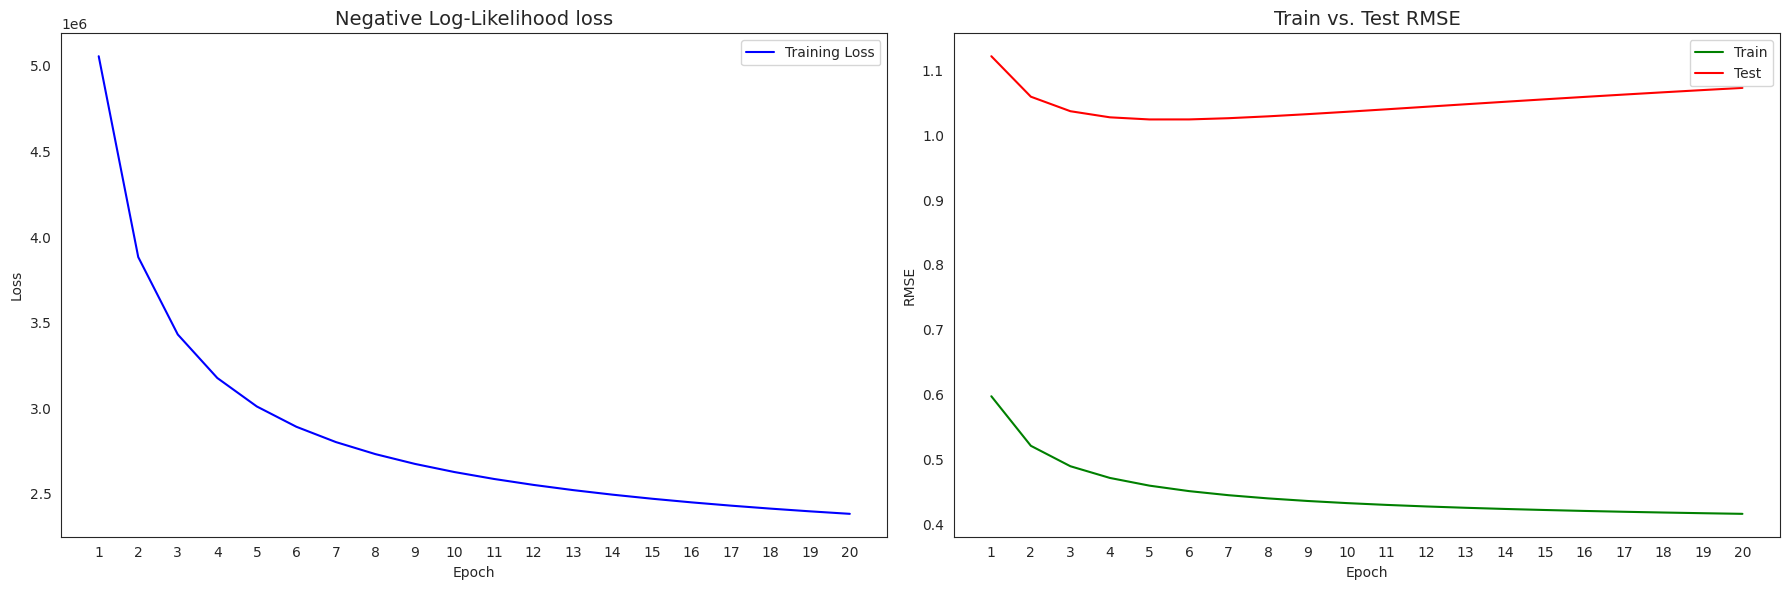

Precision@100: 0.0003 | Recall@100: 0.0008

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5399, tau = 0.1000, k=100
Epoch 5/20 | Loss: 3082088.50 | Train RMSE: 0.4575 | Test RMSE: 0.9871
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=5_k=100_lambda=0.5_tau=0.1_3.5399_20251119-215728.pkl

Epoch 10/20 | Loss: 2679637.50 | Train RMSE: 0.4316 | Test RMSE: 1.0033
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=10_k=100_lambda=0.5_tau=0.1_3.5399_20251119-222143.pkl



In [ ]:
for k_, lambda_, tau_ in product(k_values, lambda_values, tau_values):

    run_dir = os.path.join(save_dir, f"k={k_}_lambda={lambda_}")
    os.makedirs(run_dir, exist_ok=True)

    model = ALS(
        train_user, test_user, train_movie, test_movie,
        n_users=movie_index.n_users,
        n_movies=movie_index.n_movies,
        k=k_,
        lambda_reg=lambda_,
        tau=tau_,
        n_jobs=-1
    )

    model.train(n_epochs=n_epochs, save_dir=run_dir)
    plot_training_history(model)
    precision, recall = model.evaluate(k=k_, threshold=3.5)

    record = {
        "k": k_,
        "lambda": lambda_,
        "tau": tau_,
        "precision": precision,
        "recall": recall,
        "final_train_rmse": model.train_rmse_history[-1],
        "final_test_rmse": model.test_rmse_history[-1],
        "final_loss": model.train_loss_history[-1]
    }
    results_data.append(record)

    df_results = pd.DataFrame(results_data)
    df_results.to_csv(results_csv_path, index=False)


In [ ]:
k_values = [100]
tau_values = [0.1, 0.25]
lambda_values = [0.5]
results_csv_path = os.path.join(save_dir, "grid_search_results1.csv")


Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5398, tau = 0.1000, k=100
Epoch 5/20 | Loss: 3083431.50 | Train RMSE: 0.4575 | Test RMSE: 0.9877
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=5_k=100_lambda=0.5_tau=0.1_3.5398_20251120-074900.pkl

Epoch 10/20 | Loss: 2679698.25 | Train RMSE: 0.4315 | Test RMSE: 1.0038
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=10_k=100_lambda=0.5_tau=0.1_3.5398_20251120-081219.pkl

Epoch 15/20 | Loss: 2517813.75 | Train RMSE: 0.4213 | Test RMSE: 1.0221
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=15_k=100_lambda=0.5_tau=0.1_3.5398_20251120-083547.pkl

Epoch 20/20 | Loss: 2428407.50 | Train RMSE: 0.4157 | Test RMSE: 1.0377
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=20_k=100_lambda=0.5_tau=0.1_3.5398_20251120-085903.pkl



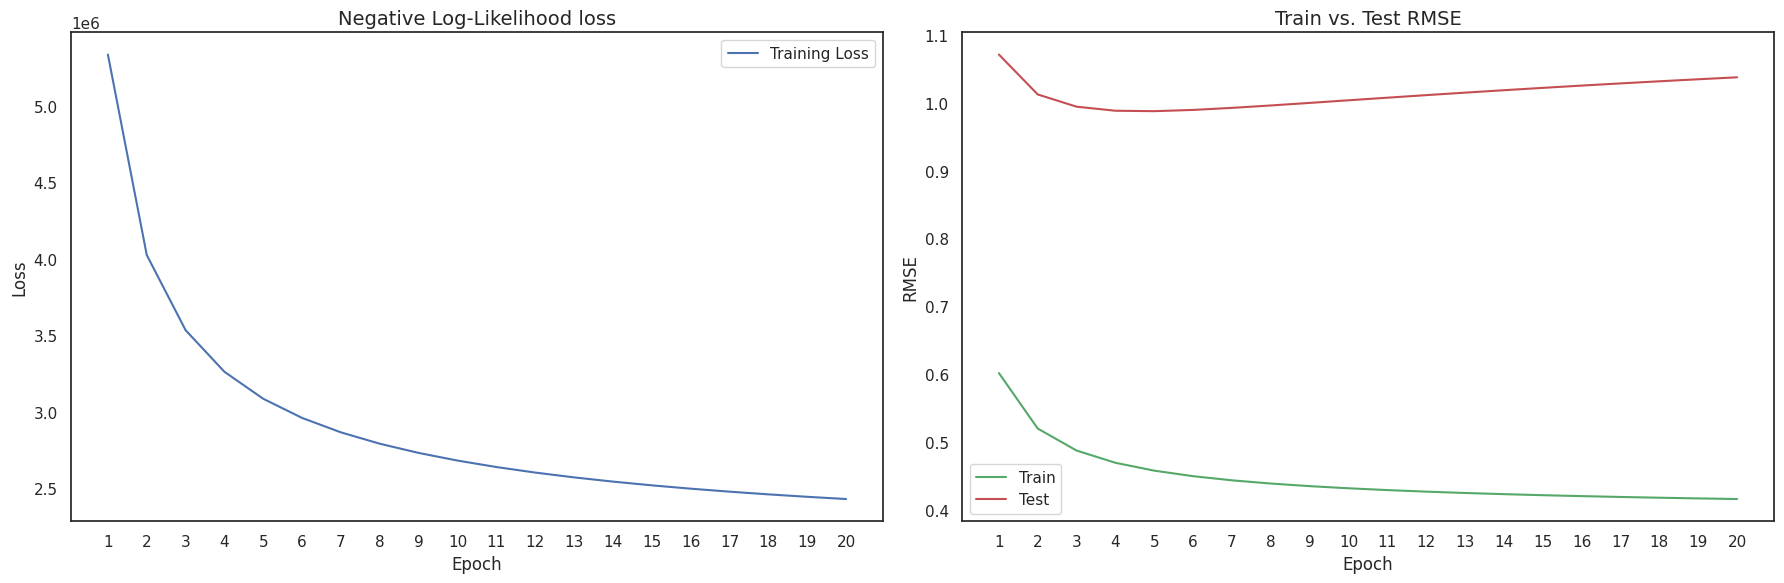

Precision@100: 0.0009 | Recall@100: 0.0031

Starting training for 20 epochs...
Hyperparameters: lambda=0.5, mu=3.5398, tau = 0.2500, k=100
Epoch 5/20 | Loss: 3204232.50 | Train RMSE: 0.4567 | Test RMSE: 0.9505
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=5_k=100_lambda=0.5_tau=0.25_3.5398_20251120-092339.pkl

Epoch 10/20 | Loss: 2780829.50 | Train RMSE: 0.4318 | Test RMSE: 0.9679
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=10_k=100_lambda=0.5_tau=0.25_3.5398_20251120-094655.pkl

Epoch 15/20 | Loss: 2622748.75 | Train RMSE: 0.4225 | Test RMSE: 0.9833
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=15_k=100_lambda=0.5_tau=0.25_3.5398_20251120-101050.pkl

Epoch 20/20 | Loss: 2541285.50 | Train RMSE: 0.4176 | Test RMSE: 0.9952
Saved model checkpoint → /content/drive/MyDrive/recommender/k=100_lambda=0.5/ALS_epoch=20_k=100_lambda=0.5_tau=0.25_3.5398_20251120-103404.pkl


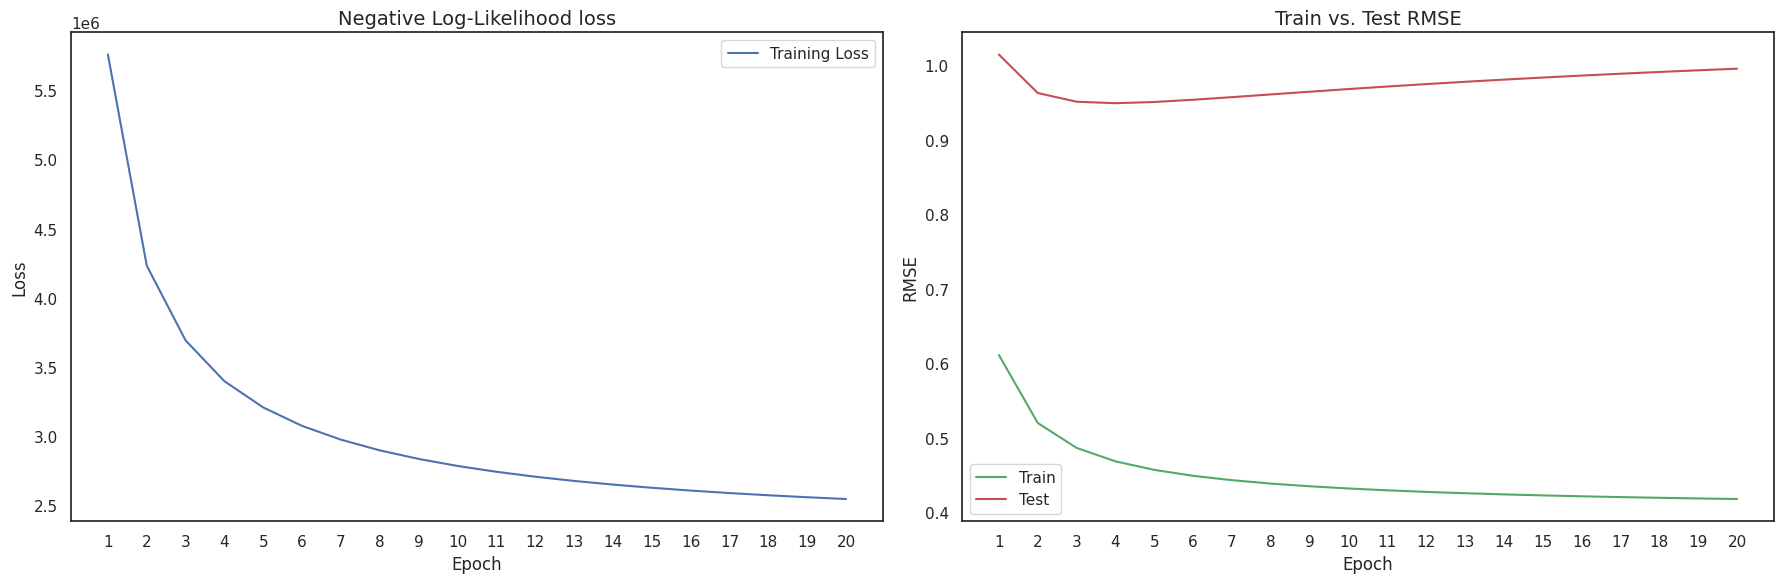

Precision@100: 0.0043 | Recall@100: 0.0217


In [ ]:
for k_, lambda_, tau_ in product(k_values, lambda_values, tau_values):

    run_dir = os.path.join(save_dir, f"k={k_}_lambda={lambda_}")
    os.makedirs(run_dir, exist_ok=True)

    model = ALS(
        train_user, test_user, train_movie, test_movie,
        n_users=movie_index.n_users,
        n_movies=movie_index.n_movies,
        k=k_,
        lambda_reg=lambda_,
        tau=tau_,
        n_jobs=-1
    )

    model.train(n_epochs=n_epochs, save_dir=run_dir)
    plot_training_history(model)
    precision, recall = model.evaluate(k=k_, threshold=3.5)

    record = {
        "k": k_,
        "lambda": lambda_,
        "tau": tau_,
        "precision": precision,
        "recall": recall,
        "final_train_rmse": model.train_rmse_history[-1],
        "final_test_rmse": model.test_rmse_history[-1],
        "final_loss": model.train_loss_history[-1]
    }
    results_data.append(record)

    df_results = pd.DataFrame(results_data)
    df_results.to_csv(results_csv_path, index=False)


In [ ]:
# Continue training from last checkpoint

# model = ALS.load_checkpoint(train_user=train_user,
#                             test_user=test_user,
#                             train_movie=train_movie,
#                             test_movie=test_movie,
#                             path="/content/drive/MyDrive/recommender/k=20_lambda=0.05/ALS_epoch=5_k=20_lambda=0.05_tau=0.5_3.2847_20251114-144132.pkl",
#                             n_jobs=-1
#                             )

# model.train(n_epochs=20, save_dir=save_dir + "/k=20_lambda=0.05")
# plot_training_history(model)

In [ ]:
df1 = pd.read_csv(os.path.join(save_dir, "grid_search_results.csv"))
df2 = pd.read_csv(os.path.join(save_dir, "grid_search_results1.csv"))
df = pd.concat([df1, df2], ignore_index=True)

sns.set_theme(style="white")
plt.figure(figsize=(16, 9))
scatter = sns.scatterplot(
    data=df,
    x="recall",
    y="precision",
    hue="k",
    size="lambda",
    style="tau",
    palette="viridis",
    sizes=(50, 200),
    alpha=0.8
)

plt.title("Precision vs Recall", fontsize=18)
plt.xlabel("Recall", fontsize=16)
plt.ylabel("Precision", fontsize=16)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
           borderaxespad=0., fontsize=16)
plt.tight_layout()
plt.savefig(f"{save_dir}/precision_vs_recall.pdf")
plt.show()

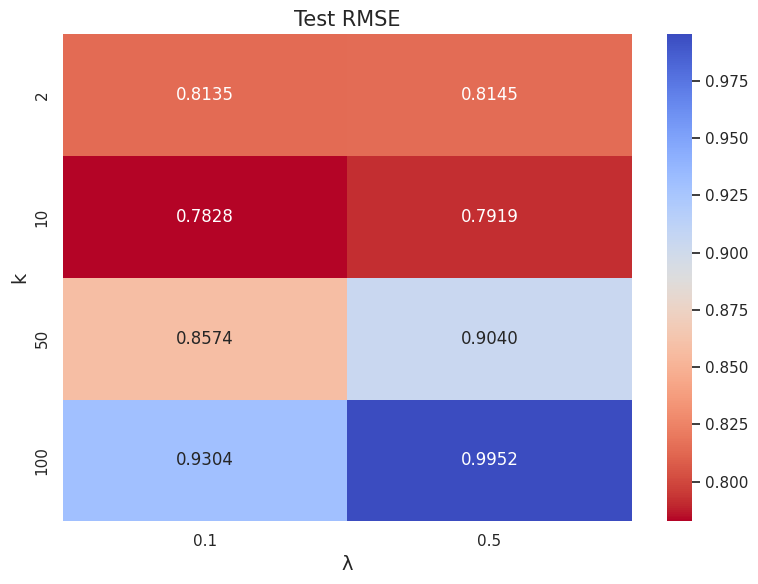

In [ ]:
best_tau_df = df.loc[df.groupby(['k', 'lambda'])['final_test_rmse'].idxmin()]

pivot_table = best_tau_df.pivot(index="k", columns="lambda", values="final_test_rmse")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="coolwarm_r")
plt.title("Test RMSE", fontsize=15)
plt.xlabel("λ", fontsize=14)
plt.ylabel("k", fontsize=14)
plt.tight_layout()
plt.savefig(f"{save_dir}/test_rmse_heatmap.pdf")
plt.show()

In [ ]:
print("\nTop 5 Configurations by Precision:")
print(df.sort_values("precision", ascending=False).head(5)[["k", "lambda", "tau", "precision", "recall"]])

print("\nTop 5 Configurations by Low RMSE:")
print(df.sort_values("final_test_rmse", ascending=True).head(5)[["k", "lambda", "tau", "final_test_rmse"]])


Top 5 Configurations by Precision:
      k  lambda   tau  precision    recall
8    10     0.1  0.25   0.043010  0.025726
14   50     0.1  0.25   0.025813  0.071325
20  100     0.1  0.25   0.019852  0.114908
7    10     0.1  0.10   0.015857  0.009819
13   50     0.1  0.10   0.011854  0.028379

Top 5 Configurations by Low RMSE:
     k  lambda   tau  final_test_rmse
8   10     0.1  0.25         0.782756
7   10     0.1  0.10         0.787716
11  10     0.5  0.25         0.791871
6   10     0.1  0.05         0.792429
10  10     0.5  0.10         0.799478


## Test recommendation

In [ ]:
def get_dummy_user_factors(model, dummy_ratings):
    """
    Computes the user bias and latent vector for a dummy user based on given ratings.
    Simulates one iteration of the ALS user update for a new user.
    """

    item_indices, true_ratings = zip(*dummy_ratings)
    item_indices = np.array(list(item_indices), dtype=np.int32)
    true_ratings = np.array(list(true_ratings), dtype=np.float32)

    # Get existing item data from the trained model
    item_vecs = model.item_vector[item_indices]
    item_biases = model.item_biases[item_indices]

    # Initialize dummy user's bias and vector for calculation
    dummy_user_bias_temp = 0.0
    dummy_user_vector_temp = np.zeros(model.k)

    # Calculate dummy user bias (one iteration)
    residuals_for_bias = true_ratings - model.mu - item_biases - np.dot(item_vecs, dummy_user_vector_temp)
    dummy_user_bias = (model.lambda_reg * np.sum(residuals_for_bias)) / (model.tau + model.lambda_reg * len(true_ratings))

    # Calculate dummy user latent vector (one iteration)
    residuals_for_latent = true_ratings - model.mu - dummy_user_bias - item_biases
    A = model.lambda_reg * (item_vecs.T @ item_vecs) + model.tau * np.eye(model.k)
    Y = model.lambda_reg * (item_vecs.T @ residuals_for_latent)
    dummy_user_vector = np.linalg.solve(A, Y)

    return dummy_user_bias, dummy_user_vector

In [ ]:
def recommend_for_dummy_user(model, train_movie,
                             user_bias, user_vector,
                             rated_items, top_n=10, alpha=1,
                             min_item_ratings=100):
    """
    Generates recommendations for a dummy user:
    - excluding items already rated by that user
    - excluding items with fewer than `min_item_ratings` ratings in the dataset
    """

    scores = alpha * (model.mu + model.item_biases) + np.dot(model.item_vector, user_vector)
    rated_items = set(rated_items)

    # Mask items with insufficient global ratings (< 100)
    for item_idx in range(model.n_movies):
        if len(train_movie[item_idx]) < min_item_ratings or item_idx in rated_items:
            scores[item_idx] = -np.inf

    top_items = np.argpartition(scores, -top_n)[-top_n:]
    top_items = top_items[np.argsort(scores[top_items])[::-1]]

    return [(int(i), float(scores[i])) for i in top_items]


In [ ]:
titles = [
    "Toy Story (1995)",
    "Toy Story 3 (2010)",
    "Lion King, The (1994)",
]

lotrs_movie_ids = movies_df.filter(pl.col("title").is_in(titles)).select('movieId').to_series().to_list()

dummy_user_preferred_movie_idx = []
for movie_id in lotrs_movie_ids:
    if movie_id in movie_index.movie_to_idx:
        dummy_user_preferred_movie_idx.append(movie_index.movie_to_idx[movie_id])

# Create dummy user 5 stars ratings for these movies
dummy_ratings = [(idx, 5.0) for idx in dummy_user_preferred_movie_idx]

print(f"Dummy user ratings: {dummy_ratings}")

Dummy user ratings: [(0, 5.0), (359, 5.0), (14810, 5.0)]


In [ ]:
model_path = "/content/drive/MyDrive/recommender/k=50_lambda=0.5/ALS_epoch=20_k=50_lambda=0.5_tau=0.25_3.5399_20251119-145942.pkl"


In [ ]:
model = ALS.load_checkpoint(train_user=train_user,
                            test_user=test_user,
                            train_movie=train_movie,
                            test_movie=test_movie,
                            path=model_path,
                            n_jobs=-1
                            )

In [ ]:
dummy_user_bias, dummy_user_vector = get_dummy_user_factors(model, dummy_ratings)

# Extract movies the user rated
dummy_rated_items = [movie_idx for movie_idx, _ in dummy_ratings]

In [ ]:
alpha = [0.05, 0.5, 1]

for a in alpha:
    # Get recommendations for the user
    recommended_items = recommend_for_dummy_user(
        model,
        train_movie,
        dummy_user_bias,
        dummy_user_vector,
        rated_items=dummy_rated_items,
        top_n=10,
        alpha=a,
        min_item_ratings=100
    )

    # Map recommended item_idx back to title
    recommended_movies_info = []
    for item_idx, score in recommended_items:
        original_movie_id = movie_index.idx_to_movie[item_idx]
        movie_title_row = movies_df.filter(pl.col('movieId') == original_movie_id).select('title')
        if not movie_title_row.is_empty():
            movie_title = movie_title_row['title'][0]
            recommended_movies_info.append({"title": movie_title, "predicted_score": f"{score:.2f}"})

    print(f"\nRecommendations for user with alpha = {a}:")
    for movie_info in recommended_movies_info:
        print(f"- {movie_info['title']} (Predicted Score: {movie_info['predicted_score']})")
    print("\n\n")


Recommendations for user with alpha = 0.05:
- Irreversible (Irréversible) (2002) (Predicted Score: 0.38)
- Toy Story 2 (1999) (Predicted Score: 0.35)
- Toy Story 4 (2019) (Predicted Score: 0.35)
- Inside Out (2015) (Predicted Score: 0.34)
- Feast (2014) (Predicted Score: 0.33)
- Finding Dory (2016) (Predicted Score: 0.33)
- Harvie Krumpet (2003) (Predicted Score: 0.33)
- Babylon (2022) (Predicted Score: 0.33)
- Winnie Pooh (1969) (Predicted Score: 0.33)
- Toy Story That Time Forgot (2014) (Predicted Score: 0.32)




Recommendations for user with alpha = 0.5:
- Planet Earth II (2016) (Predicted Score: 2.16)
- Planet Earth (2006) (Predicted Score: 2.16)
- Over the Garden Wall (2013) (Predicted Score: 2.16)
- Death Note: Desu nôto (2006–2007) (Predicted Score: 2.15)
- Powers of Ten (1977) (Predicted Score: 2.15)
- Cosmos: A Spacetime Odissey (Predicted Score: 2.13)
- HyperNormalisation (2016) (Predicted Score: 2.13)
- Cosmos (Predicted Score: 2.13)
- Band of Brothers (2001) (Predicted Sc

# Vector Visualization

In [ ]:
movie_title_list = [
    "Toy Story (1995)",
    "Toy Story 3 (2010)",
    "Lion King, The (1994)",
    "Finding Nemo (2003)",
    "Shrek (2001)",
    "Star Wars: Episode IV - A New Hope (1977)",
    #"Star Wars: Episode V - The Empire Strikes Back (1980)",
    "Blade Runner (1982)",
    "Matrix, The (1999)",
    #"Lord of the Rings: The Fellowship of the Ring, The (2001)",
    "Lord of the Rings: The Return of the King, The (2003)",
    "Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001)",
    "Pulp Fiction (1994)",
    "Goodfellas (1990)",
    "The Shawshank Redemption (1994)",
    "Forrest Gump (1994)",
    "Eternal Sunshine of the Spotless Mind (2004)",
    "Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)",
    "Spirited Away (Sen to Chihiro no kamikakushi) (2001)",
    "Princess Mononoke (Mononoke-hime) (1997)",
    "Interstellar (2014)",
    "Inception (2010)",
    "Dark Knight, The (2008)",
    "Gladiator (2000)",
    "Saving Private Ryan (1998)",
    "Maltese Falcon, The (1941)",
    "Batman (1989)",
    "Batman Returns (1992)",
    #"Suture (1993)",
    #"Wild Bill (1995)",
]

In [ ]:
selected_movie_latent_vectors = []
selected_movie_labels = []
selected_movie_genres = []

specific_movies_df = movies_df.filter(pl.col('title').is_in(movie_title_list))

for movie_row in specific_movies_df.iter_rows(named=True):
    movie_id = movie_row['movieId']
    title = movie_row['title']
    genres = movie_row['genres']

    if movie_id in movie_index.movie_to_idx:
        item_idx = movie_index.movie_to_idx[movie_id]
        latent_vector = model.item_vector[item_idx]
        selected_movie_latent_vectors.append(latent_vector)

        cleaned_title = re.sub(r'\(.*?\)', '', title)
        cleaned_title = re.sub(r',.*', '', cleaned_title).strip()
        selected_movie_labels.append(cleaned_title)

        if genres and genres != '(no genres listed)':
            selected_movie_genres.append(genres.split('|')[0])
        else:
            selected_movie_genres.append('Unknown')
    else:
        print(f"Warning: Movie '{title}' (ID: {movie_id}) not found in movie_index. Skipping.")

selected_movie_latent_vectors = np.array(selected_movie_latent_vectors)

print(f"Loaded model from checkpoint. Number of selected movies: {len(selected_movie_labels)}")
print(f"Shape of selected_movie_latent_vectors: {selected_movie_latent_vectors.shape}")

Loaded model from checkpoint. Number of selected movies: 25
Shape of selected_movie_latent_vectors: (25, 50)


In [ ]:
# Perform PCA if the latent vectors have more than 2 dimensions

if selected_movie_latent_vectors.shape[1] > 2:
    pca = PCA(n_components=2)
    selected_movie_latent_vectors = pca.fit_transform(selected_movie_latent_vectors)
    print(f"Reduced latent vectors to 2 dimensions using PCA. New shape: {selected_movie_latent_vectors.shape}")

Reduced latent vectors to 2 dimensions using PCA. New shape: (25, 2)


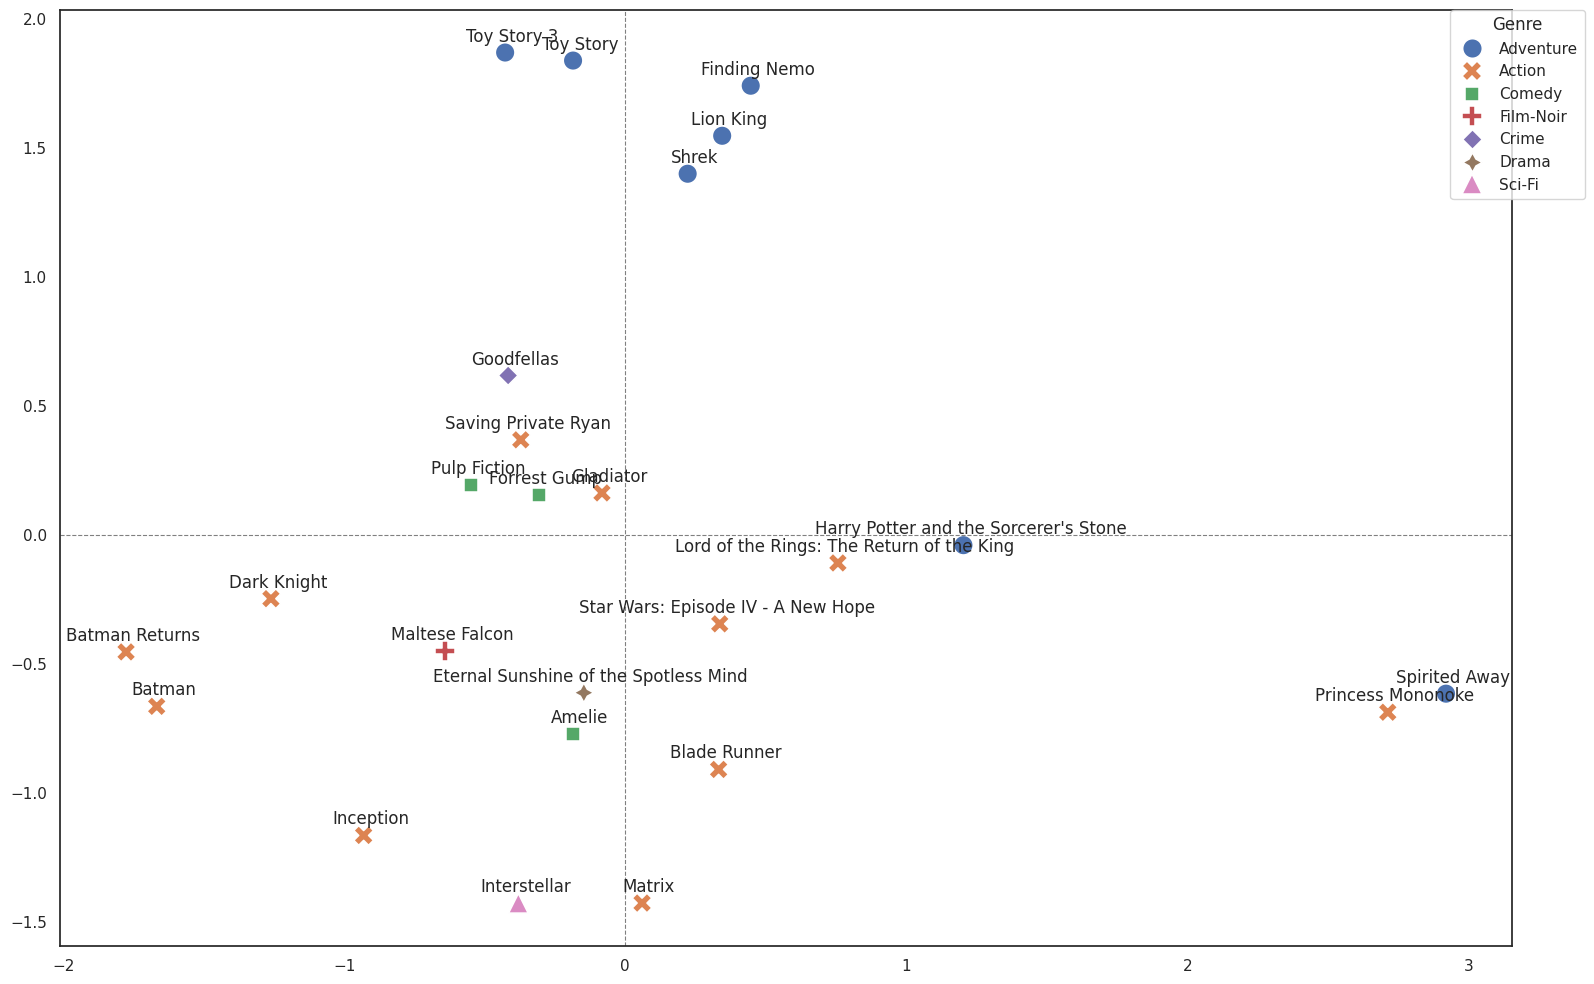

In [ ]:
plot_data = pd.DataFrame({
    'x': selected_movie_latent_vectors[:, 0],
    'y': selected_movie_latent_vectors[:, 1],
    'label': selected_movie_labels,
    'genre': selected_movie_genres
})

plt.figure(figsize=(16, 10))
sns.scatterplot(
    data=plot_data,
    x='x',
    y='y',
    hue='genre',
    style='genre',
    s=200,
)

texts = []
for i, row in plot_data.iterrows():
    texts.append(plt.annotate(row['label'], (row['x'], row['y']), fontsize=12,
                              va='bottom', ha='center',
                              xytext = (5, 5),
                              textcoords = 'offset points'))

# Automatically adjust text to prevent overlaps
# at.adjust_text(texts,
#                arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.05, 1), loc='best',
           borderaxespad=0., title='Genre')
plt.xlabel('')
plt.ylabel('')
#plt.axis('off')
plt.tight_layout()
plt.savefig(f"{save_dir}/movie_latent_vectors_by_genre.pdf")
plt.show()

# Add Features

# Joint Density

The joint density of $u$ and $v$ given a rating $r$, with regularization parameters $\tau$ and $\lambda$, is proportional to:

$$ p(u,v|r) \propto e^\left( -\frac{\tau (u^2 + v^2)}{2} - \frac{\lambda (r - uv)^2)}{2} \right) $$

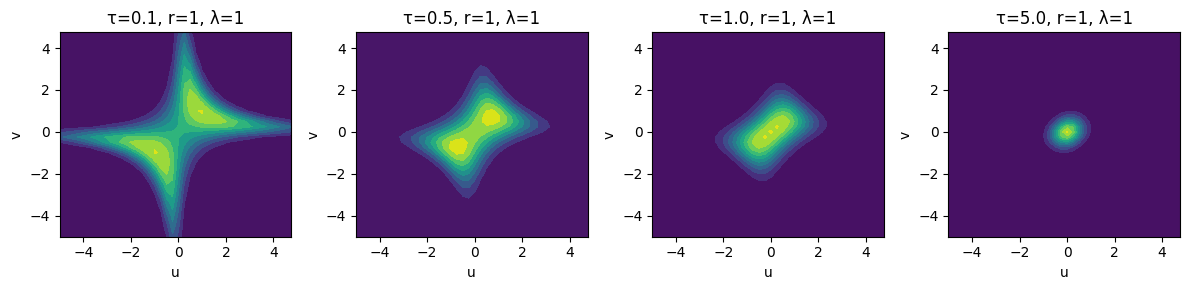

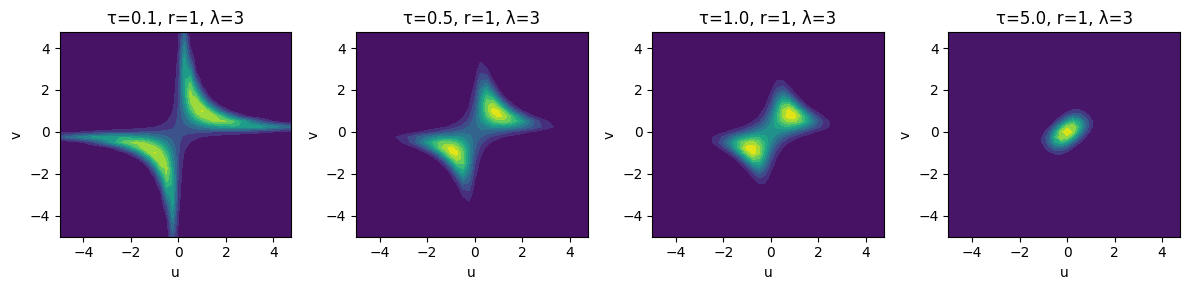

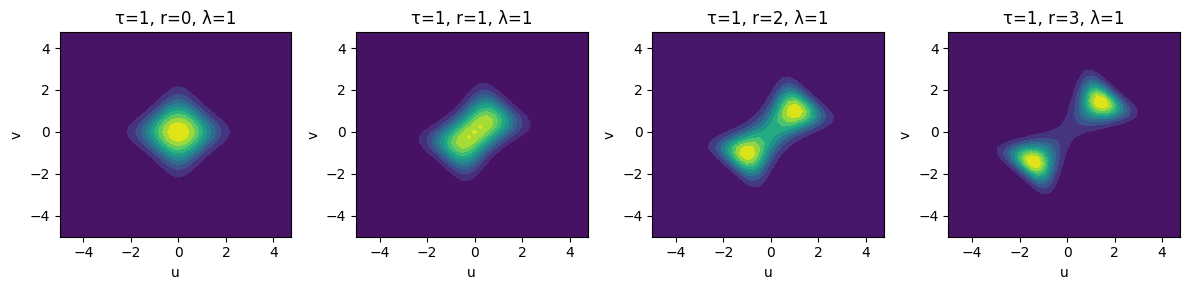

In [ ]:
def plot_density(tau, r, lam=1.0, ax=None):
    u = np.arange(-5, 5, 0.25)
    v = np.arange(-5, 5, 0.25)
    U, V = np.meshgrid(u, v)
    # Unnormalized posterior density p(u,v|r) ∝ exp(-0.5 * tau * (u² + v²) - 0.5 * lam * (r - u*v)²)
    log_P = -0.5 * tau * (U**2 + V**2) - 0.5 * lam * (r - U * V)**2
    P = np.exp(log_P)
    if ax is None:
        fig, ax = plt.subplots()
    surf = ax.contourf(U, V, P, levels=10)
    ax.set_xlabel('u')
    ax.set_ylabel('v')
    ax.set_title(f'τ={tau}, r={r}, λ={lam}')
    return surf

fig, axs = plt.subplots(1, 4, figsize=(12, 3))
taus = [0.1, 0.5, 1.0, 5.0]
for i, tau in enumerate(taus):
    plot_density(tau, r=1, lam=1, ax=axs[i])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 4, figsize=(12, 3))
taus = [0.1, 0.5, 1.0, 5.0]
for i, tau in enumerate(taus):
    plot_density(tau, r=1, lam=3, ax=axs[i])
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 4, figsize=(12, 3))
rs = [0, 1, 2, 3]
for i, r in enumerate(rs):
    plot_density(tau=1, r=r, lam=1, ax=axs[i])
plt.tight_layout()
plt.show()

### Gibbs Sampling

The Gibbs sampler for the joint density

$$ p(u,v|r) \propto e^ {-\frac {\tau (u^2 + v^2)}{2} - \frac{\lambda (r - uv)^2)}{2}} $$ involves iteratively sampling from the conditional distributions:

1.  **Conditional distribution of u given v and r ($ p(u | v, r) $):**
    A Gaussian distribution with:
    Mean: $ \mu_u = \frac{\lambda r v}{\tau + \lambda v^2} $
    Variance: $ \sigma_u^2 = \frac{1}{\tau + \lambda v^2} $

2.  **Conditional distribution of v given u and r ($ p(v | u, r) $):**
    A Gaussian distribution with:
    Mean: $ \mu_v = \frac{\lambda r u}{\tau + \lambda u^2} $
    Variance: $ \sigma_v^2 = \frac{1}{\tau + \lambda u^2} $

The Gibbs sampling algorithm proceeds by alternating between sampling $u$ from $p(u | v, r)$ and sampling $v$ from $p(v | u, r)$, where $u$ and $v$ are the sampled values.

In [ ]:
def gibbs_sampling(n_samples=1000, tau=1, r=1, lam=1.0, ax=None):
    u = np.arange(-5, 5, 0.25)
    v = np.arange(-5, 5, 0.25)
    U, V = np.meshgrid(u, v)
    log_P = -0.5 * tau * (U**2 + V**2) - 0.5 * lam * (r - U * V)**2
    P = np.exp(log_P)
    samples = []
    u_current = 0.0
    v_current = 0.0

    for i in range(n_samples):
        mean_u = (lam * r * v_current) / (tau + lam * v_current**2)
        std_dev_u = np.sqrt(1 / (tau + lam * v_current**2))
        u_current = np.random.normal(mean_u, std_dev_u)

        mean_v = (lam * r * u_current) / (tau + lam * u_current**2)
        std_dev_v = np.sqrt(1 / (tau + lam * u_current**2))
        v_current = np.random.normal(mean_v, std_dev_v)

        samples.append((u_current, v_current))

    samples_np = np.array(samples)

    if ax is None:
        fig, ax = plt.subplots()
    surf = ax.contourf(U, V, P, levels=10)
    ax.scatter(samples_np[:, 0], samples_np[:, 1], color='red', marker='o', alpha=0.5, s=10)
    ax.set_xlabel('u')
    ax.set_ylabel('v')
    ax.set_title(f'τ={tau}, r={r}, λ={lam}')
    ax.set_xlim([-6, 6])
    ax.set_ylim([-6, 6])
    return surf, samples_np

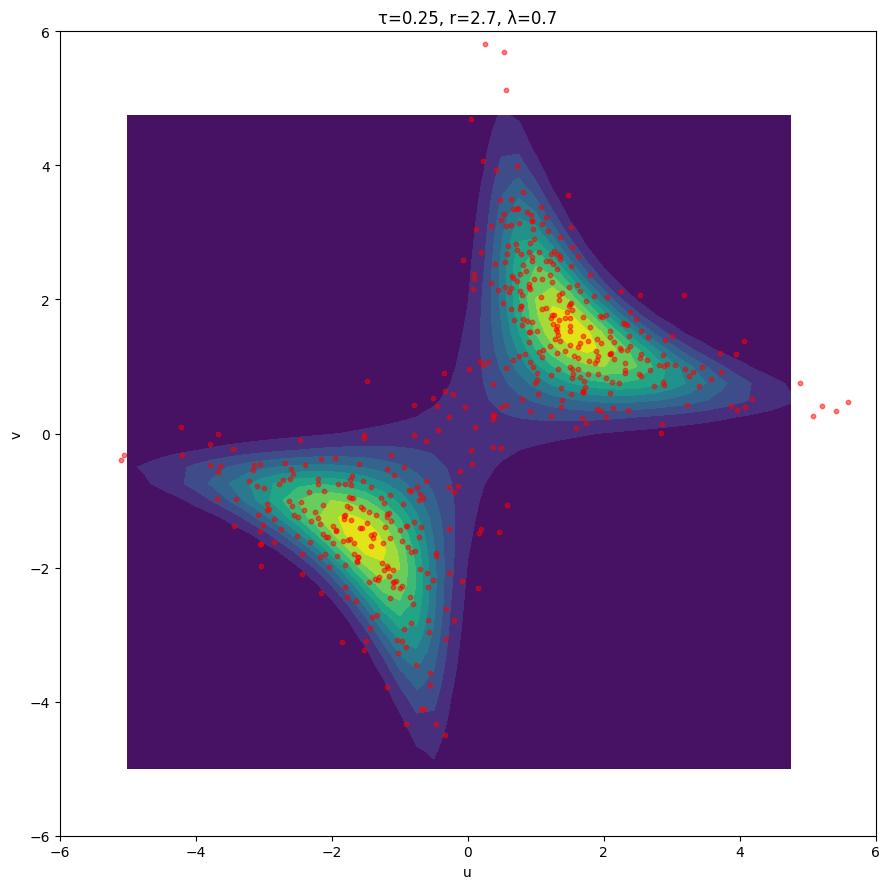

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(9, 9))
gibbs_sampling(n_samples=500, r=2.7, lam=0.7, tau=0.25, ax=axs)
plt.tight_layout()
plt.show()